## v18.1gc (submit) = v18.1gs with FP8 KV, 16 games, trims 57,344 -> 45,056 (was 36,864 -> 26,624)

## v18.1gs-submit = v18.1gs (stock) with a fast Save & Run (2 public games, 6 min) outside the competition rerun; the scored rerun is unchanged

## v18.1gs = v18.1fs with two phrases deleted from the prompt (the edge bar is the action budget; do not tell the model to ignore it)

## v18.1as = v18.1n (stock model) + M111 (animation frames in the sandbox: `transition.frames`, the in-between boards of the last 8 animated actions, up to 32 each, read only when the model asks; one clause + one line of prompt)

## v18.1n = v18.1 + NVFP4 MTP draft loaded from a draft-only folder (M108) + M72 slices of 2,400 s; prompts and harness exactly v18.1

## v14.64 v4 - v14.63 + KV reclaim, 15 running, prefill chunk 4096 (v1 OOM fix) + server-alive watchdog + GPU memory log


# Tufa Labs ARC3 submission

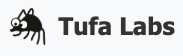

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# Skip periodic JSON/HTML diagnostics and per-frame logging for every run.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1"

# Apply the measured vLLM winner before any serving setup command runs.
# KV RAISED 5.0 -> 6.5 GiB. MEASURED at 5 GiB: 105,202 KV tokens =
# 'Maximum concurrency 3.21x' at 32,768 tok/request, and the GPU served
# 3.11 concurrent requests -- decode-bound at 3 lanes, 243 tok/s aggregate.
# 6.5 GiB should give ~136,800 tokens = ~4.17 lanes = ~+30% actions.
# vLLM SKIPS memory profiling when kv_cache_memory_bytes is set, so real
# headroom has never been measured -- that is what this MINI is for.
# ---- MEASURED ON THE v14.42 MINI (2026-09-10), read this before changing any of it ----
# KV 6.5 GiB OOM'd 6 min into serving. The full accounting at the moment of death:
#   weights 81.80 + KV 6.50 + cudagraphs 0.36 + activations ~3.46 + PyTorch
#   reserved-but-unallocated 1.00 + cuda ctx ~0.87 + PleOffloadWorker(pid 301) 0.71
#   = 94.70 of 94.97 GiB -> 278 MB free -> died on a 308 MiB conv activation.
# NOTE vLLM reserves the KV pool against "Initial free memory 94.43 GiB" READ BEFORE the
# 81.8 GiB of weights load, and `skipped memory profiling` because the cap is manual --
# so the cap is applied BLIND and would accept any value. 5.0 GiB was never validated,
# it merely fit. 6.0 GiB leaves ~790 MB, ~2.5x the observed 308 MiB spike.
# KV measured: 5.0 GiB -> 105,202 tokens / 3.21x (3.11 running); 6.5 -> 136,245 / 4.16x
# (4.83 running). Tokens scale linearly with bytes, so 6.0 should give ~125,800 / 3.84x.
#
# TAAF_VLLM_MAX_NUM_BATCHED_TOKENS IS DELIBERATELY ABSENT. serving_setup.py
# resolve_vllm_tuning() only reads it as `requested`, and its default is ALSO 8192, so
# the initial launch is byte-identical. But the WATCHDOG RESTART path passes
# enable_chunked_prefill=False, and there an OVERRIDDEN value below ANALYZER_CONTEXT
# (32768) raises "must be at least 32768 when chunked prefill is disabled" -- which is
# why the MINI's two restart attempts BOTH failed and the run spent 30 of its 45 minutes
# with no model server. Unset, the restart falls through to 32768 and succeeds.
# PREFIX CACHING IS ON IN THIS BUILD (requested). What we already measured about it,
# so the result is read correctly rather than re-litigated:
#   * KV pool is IDENTICAL on/off -- 342,400 tokens either way on the 27B probe, and the
#     1600-token attention block size does not change. So it costs no KV.
#   * measured hit rate was 12.3% median / 47.6% max / 0.0% min over 790 samples.
#   * vLLM issue #45238: for hybrid GDN models, align mode keeps only the mamba
#     checkpoint at the last block boundary before the prompt ends; if that lands in
#     request-unique tokens ALL reuse silently drops to 0%. Our arithmetic -- checkpoint
#     at 17,600 vs a 3,761-token stable prefix -- puts us in that regime.
#   * BUT the M24 ledger now pins a long stable prefix, which is exactly the condition
#     the note said was needed to make align-mode caching work. That is what this run
#     tests. Read `prefix cache hit rate` out of the vLLM log to judge it.
PUBLIC25_VLLM_PROFILE_NAME = 'kv10.0-nvfp4mtp-mtp1-c8-cg32'
PUBLIC25_VLLM_PROFILE_ENV = {
    "TAAF_VLLM_ENABLE_PREFIX_CACHING": "0",
    "TAAF_VLLM_KV_CACHE_DTYPE": "auto",
    "TAAF_VLLM_KV_CACHE_MEMORY_BYTES": "10737418240",
    "TAAF_VLLM_MAX_CUDAGRAPH_CAPTURE_SIZE": "32",
    "TAAF_VLLM_MAX_NUM_SEQS": "8",
    "TAAF_VLLM_MTP_TOKENS": "1",
    "TAAF_VLLM_OMP_THREADS": "1"
}
for key, value in PUBLIC25_VLLM_PROFILE_ENV.items():
    os.environ[key] = value
print(
    f'PUBLIC25_VLLM_PROFILE name={PUBLIC25_VLLM_PROFILE_NAME} '
    f'env={json.dumps(PUBLIC25_VLLM_PROFILE_ENV, sort_keys=True)}',
    flush=True,
)
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# (expandable_segments removed: serving_setup.py forbids it for the PLE CPU-offload IPC -- fatal on 2026-09-12 run)

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")
# ---- v14.57 HARD CAP (local runs only): a stock local run ends ~2.4 h; kill at 3 h. Never armed in a real rerun. ----
if not TRUE_SUBMISSION:
    import threading as _cap_t
    def _cap_kill():
        print("V1462_HARD_CAP_REACHED 10800s -> os._exit", flush=True)
        os._exit(3)
    _cap_timer = _cap_t.Timer(10800.0 - (time.time() - NOTEBOOK_START_EPOCH), _cap_kill)
    _cap_timer.daemon = True
    _cap_timer.start()
    print("V1462_HARD_CAP armed 10800s", flush=True)


## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        str(next(iter(sorted(Path("/kaggle/input").glob("**/arc_agi_3_wheels"))), Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels"))),
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["keithtyser/duck-qwen38-nvfp4-mtp-vllm-smoke-v1", "keithtyser/qwen38-flash-next-vllm-nvfp4-runtime-v1"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and boot SGLang

Put the harness repos on the path, then boot Pennyroyal SGLang v2.5.0 on port 1234 (sglang-boot-v6 recipe: ready ~546 s, KV 727,168 tokens).

In [ ]:
# Harness repos on the path. The bundle's own sglang-rtxpro6000 tree is left OFF the path so it can never shadow
# the Pennyroyal runtime the server imports (the harness itself never imports sglang).
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        if repo.name.startswith("sglang"):
            continue
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries

source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

HARNESS_ENV = {"INFERENCE_ANALYZER_MODEL": "Qwen/Qwen3.8-Flash-Next-NVFP4", "LOCAL_ANALYZER_APP_NAME": "ARC3 Agent Harness", "LOCAL_ANALYZER_BASE_URL": "http://127.0.0.1:1234/v1", "LOCAL_ANALYZER_CONTEXT_WINDOW": "69632", "LOCAL_ANALYZER_ENABLE_THINKING": "true", "LOCAL_ANALYZER_MAX_OUTPUT": "0", "LOCAL_ANALYZER_MODEL_ID": "Qwen/Qwen3.8-Flash-Next-NVFP4", "LOCAL_ANALYZER_PROVIDER": "vllm", "LOCAL_ANALYZER_TEMPERATURE": "0.6", "LOCAL_ANALYZER_TOOL_OUTPUT_TOKENS": "1024", "LOCAL_ANALYZER_TOOL_STEPS": "0", "LOCAL_ANALYZER_TOOL_TIMEOUT": "30", "LOCAL_ANALYZER_TOP_K": "20", "LOCAL_ANALYZER_TOP_P": "0.95", "LOCAL_ANALYZER_YIELD_SECONDS": "60", "MULTIMODAL_CONTEXT": "current_grid", "MULTIMODAL_UPSCALE": "4", "OPENAI_API_KEY": "offline-kaggle-local-server", "OPENAI_BASE_URL": "http://127.0.0.1:1234/v1", "OPENAI_PROVIDER": "vllm"}
os.environ.update(HARNESS_ENV)
SETUP_ENV_PATH.write_text(json.dumps({**json.loads(SETUP_ENV_PATH.read_text()), **HARNESS_ENV}, indent=2, sort_keys=True) + "\n")
print("V1458_HARNESS_ENV", json.dumps(HARNESS_ENV, sort_keys=True), flush=True)


In [ ]:
# ---------------- 1. inventory + unpack SGLang runtime + borrow CUDA 13.0 toolkit ----------------
import base64, concurrent.futures, glob, hashlib, io, json, os, re, shutil, signal, statistics, subprocess, sys, tarfile, threading, time, traceback, urllib.request
from pathlib import Path

T0 = time.time()
DEADLINE = T0 + 1500   # SGLang boot budget (v6 measured ready at 546 s)
WORK = Path("/kaggle/working")
R = {"errors": {}, "phases": {}}

def log(*a):
    print(f"[{time.time() - T0:7.1f}s]", *a, flush=True)

def save():
    (WORK / "sglang_boot_result.json").write_text(json.dumps(R, indent=2, default=str))

def left():
    return DEADLINE - time.time()

def sh(cmd, timeout=120):
    try:
        return subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=timeout).stdout.strip()
    except Exception as exc:
        return f"ERR {exc}"

def phase(name):
    def deco(fn):
        t = time.time()
        log("PHASE_START", name)
        try:
            R["phases"][name] = {"result": fn()}
        except Exception:
            R["errors"][name] = traceback.format_exc()[-4000:]
            log("PHASE_ERROR", name, R["errors"][name][-1500:])
        R["phases"].setdefault(name, {})["seconds"] = round(time.time() - t, 1)
        save()
        return fn
    return deco

def meminfo():
    m = dict(re.findall(r"^(\w+):\s+(\d+) kB", open("/proc/meminfo").read(), flags=re.M))
    return {"MemTotal_GiB": round(int(m["MemTotal"]) / 1024**2, 1), "MemAvailable_GiB": round(int(m["MemAvailable"]) / 1024**2, 1)}

def gpumem():
    return sh("nvidia-smi --query-gpu=memory.used,memory.total --format=csv,noheader,nounits")

R["env"] = {
    "gpu": sh("nvidia-smi --query-gpu=name,driver_version,memory.total --format=csv,noheader"),
    "mem": meminfo(), "nproc": os.cpu_count(), "python": sys.version,
    "gcc": sh("gcc --version | head -1"), "disk": sh("df -h /tmp /kaggle/working"),
}
log("ENV", json.dumps(R["env"]))
if "RTX PRO 6000" not in R["env"]["gpu"]:
    save()
    raise RuntimeError(f"wrong accelerator, expected RTX PRO 6000: {R['env']['gpu']}")

def _one(pattern, root="/kaggle/input"):
    hits = sorted({p.parent for p in Path(root).rglob(pattern)})
    if len(hits) != 1:
        raise RuntimeError(f"expected exactly one {pattern} under {root}, found {hits}")
    return hits[0]

RT = _one("RUNTIME_MANIFEST.json")
VRT = _one("runtime-manifest.json")
MODEL = _one("MODEL_MANIFEST.json", "/kaggle/input/models")
R["paths"] = {"sglang_runtime": str(RT), "vllm_runtime_layers": str(VRT), "model": str(MODEL)}
R["model_config_sha256"] = hashlib.sha256((MODEL / "config.json").read_bytes()).hexdigest()
log("PATHS", R["paths"], "config sha", R["model_config_sha256"][:12])
save()

# ===== v16.5 = M82: serve Intel AutoRound W4A16 experts (BF16 activations) instead of NVFP4 W4A4 experts =====
# Merged model dir: every Intel file except its BF16 PLE tables (model-00016-of-00017, 102.4 GB), plus the served
# NVFP4 checkpoint's FP8 PLE tables (same tables, checked offline), so host RAM and PLE numerics match v16.0 v2.
NV = MODEL
W4 = _one("config.json.autoround.bak", "/kaggle/input/models")      # woochangsim mirror of Intel @ 4c67bf68
MIX = Path("/tmp/w4a16mix")
shutil.rmtree(MIX, ignore_errors=True)
MIX.mkdir(parents=True)
_PLE_BF16 = "model-00016-of-00017.safetensors"
_w4_idx = json.loads((W4 / "model.safetensors.index.json").read_text())
_nv_idx = json.loads((NV / "model.safetensors.index.json").read_text())
_drop = {k for k, f in _w4_idx["weight_map"].items() if f == _PLE_BF16}
if len(_drop) != 128 or not all(".ple.ple_embedding.ngram_embedding.shard_" in k for k in _drop):
    raise RuntimeError(f"M82: {_PLE_BF16} is not exactly the 128 PLE tables ({len(_drop)} tensors)")
_ple = {k: f for k, f in _nv_idx["weight_map"].items() if ".ple.ple_embedding.ngram_embedding." in k}
if len(_ple) != 129 or not all(f.startswith("model-plefp8-") for f in _ple.values()) or set(_drop) - set(_ple):
    raise RuntimeError(f"M82: served checkpoint's FP8 PLE tables not as expected ({len(_ple)} tensors)")
_wm = {k: f for k, f in _w4_idx["weight_map"].items() if k not in _drop}
_wm.update(_ple)
_skip = {_PLE_BF16, "model.safetensors.index.json", "config.json", "config.json.autoround.bak"}
for _f in sorted(W4.iterdir()):
    if _f.is_file() and _f.name not in _skip:
        (MIX / _f.name).symlink_to(_f)
for _name in sorted(set(_ple.values())):
    if not (NV / _name).is_file():
        raise RuntimeError(f"M82: missing {_name} in {NV}")
    (MIX / _name).symlink_to(NV / _name)
(MIX / "model.safetensors.index.json").write_text(json.dumps({**_w4_idx, "weight_map": _wm}))
_cfg = json.loads((W4 / "config.json").read_text())
if _cfg.get("quantization_config", {}).get("quant_method") != "auto-round":
    raise RuntimeError(f"M82: unexpected quantization_config {str(_cfg.get('quantization_config'))[:200]}")
_cfg["text_config"]["ple_embedding_dtype"] = "float8_e4m3fn"
(MIX / "config.json").write_text(json.dumps(_cfg, indent=2))
MODEL = MIX
R["paths"].update(model=str(MODEL), w4a16_source=str(W4), ple_source=str(NV))
log("V1650_M82", json.dumps({"files": len(list(MIX.iterdir())), "tensors": len(_wm), "ple_fp8_files": len(set(_ple.values())),
                             "w4": str(W4), "nv": str(NV)}))
save()

@phase("unpack_sglang")
def _unpack():
    man = json.loads((RT / "RUNTIME_MANIFEST.json").read_text())
    for name, meta in man["parts"].items():
        if (RT / name).stat().st_size != meta["bytes"]:
            raise RuntimeError(f"part size mismatch {name}")
    whl = sorted(RT.glob("zstandard-*.whl"))
    zdir = Path("/tmp/zst")
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "--no-index", "--no-deps", "--target", str(zdir), str(whl[-1])], check=True)
    sys.path.insert(0, str(zdir))
    import zstandard

    class Cat(io.RawIOBase):
        def __init__(self, files):
            self.files, self.f = list(files), None
        def readable(self):
            return True
        def readinto(self, b):
            while True:
                if self.f is None:
                    if not self.files:
                        return 0
                    self.f = open(self.files.pop(0), "rb")
                n = self.f.readinto(b)
                if n:
                    return n
                self.f.close(); self.f = None

    dest = Path("/tmp/sgl")
    if dest.exists(): shutil.rmtree(dest)
    dest.mkdir()
    src = Cat(RT / n for n in sorted(man["parts"]))
    with zstandard.ZstdDecompressor().stream_reader(src) as zr, tarfile.open(fileobj=zr, mode="r|") as tf:
        tf.extractall(dest, filter="fully_trusted")
    return {"manifest": {k: man[k] for k in ("tag", "source_rev", "rust_extensions", "versions", "flashinfer_jit_cache") if k in man},
            "site_GiB": sh("du -sh /tmp/sgl/sgl-site | cut -f1")}

@phase("unpack_cuda_toolkit")
def _cuda():
    man = json.loads((VRT / "runtime-manifest.json").read_text())
    root = Path("/tmp/cuda-root")
    if root.exists(): shutil.rmtree(root)
    root.mkdir()
    n_files = 0
    skipped = []
    _ordered = sorted(man["selected_layers"], key=lambda l: (l["index"] != 8, l["index"]))
    _scanned = []
    for layer in _ordered:
        if layer["index"] != 8 and list(root.glob("usr/local/cuda-*/bin/nvcc")):
            break   # toolkit found in layer 8 (verified from image build history); skip the pip layers
        _scanned.append(layer["index"])
        path = VRT / layer["file"]
        if not path.exists():
            path = VRT / (layer["file"] + ".blob")
        with tarfile.open(path, mode="r|gz") as tf:
            for m in tf:
                name = m.name.lstrip("./")
                if not name.startswith("usr/local/cuda"):
                    continue
                base = os.path.basename(name)
                target = root / os.path.dirname(name)
                if base == ".wh..wh..opq":
                    if target.is_dir():
                        for c in target.iterdir():
                            shutil.rmtree(c) if c.is_dir() and not c.is_symlink() else c.unlink()
                    continue
                if base.startswith(".wh."):
                    victim = target / base[4:]
                    if victim.is_symlink() or victim.is_file(): victim.unlink()
                    elif victim.is_dir(): shutil.rmtree(victim)
                    continue
                m.name = name
                try:
                    tf.extract(m, root, filter="fully_trusted")
                    n_files += 1
                except Exception as exc:
                    skipped.append(f"{name}: {type(exc).__name__}")
    homes = sorted(p.parent.parent for p in root.glob("usr/local/cuda-*/bin/nvcc"))
    if not homes:
        raise RuntimeError("no nvcc found in the vLLM runtime layers")
    return {"layers_scanned": _scanned, "files": n_files, "skipped": skipped[:20], "skipped_count": len(skipped), "cuda_home": str(homes[-1]), "nvcc": sh(f"{homes[-1]}/bin/nvcc --version | tail -2")}

CUDA_HOME = Path(R["phases"].get("unpack_cuda_toolkit", {}).get("result", {}).get("cuda_home", "/usr/local/cuda"))
SETUP_OK = not R["errors"]
log("SETUP_OK", SETUP_OK, "CUDA_HOME", CUDA_HOME)
save()


In [ ]:
# ---------------- 2. launch Pennyroyal SGLang on our RadixArk NVFP4 checkpoint ----------------
SITE = Path("/tmp/sgl/sgl-site")
PORT = 1234   # the harness's LOCAL_ANALYZER_BASE_URL port
BASE = f"http://127.0.0.1:{PORT}"
SERVED = "Qwen/Qwen3.8-Flash-Next-NVFP4"
BOOT = Path("/tmp/sgl/boot")
BOOT.mkdir(parents=True, exist_ok=True)
# PYTHONPATH alone skips .pth files; sitecustomize adds the runtime as a site dir AHEAD of Kaggle's own torch.
(BOOT / "sitecustomize.py").write_text(
    "import site, sys\n"
    f"_s = {str(SITE)!r}\n"
    "site.addsitedir(_s)\n"
    "_new = [p for p in sys.path if p.startswith(_s)]\n"
    "sys.path[:] = _new + [p for p in sys.path if not p.startswith(_s)]\n"
)
# The borrowed toolkit (vLLM image layers) has no lib64/ and its libcudart.so target was whited out.
# JIT kernels link with -L$CUDA_HOME/lib64 -lcudart, so repair both before launch.
def _repair_cuda_libs():
    info = {}
    tgt = CUDA_HOME / "targets/x86_64-linux/lib"
    lib64 = CUDA_HOME / "lib64"
    if not lib64.exists() and tgt.is_dir():
        lib64.symlink_to(tgt); info["lib64"] = f"symlink -> {tgt}"
    cudart = lib64 / "libcudart.so"
    if not cudart.exists():                      # missing or dangling symlink
        cands = sorted(glob.glob(str(SITE / "nvidia/cu13/lib/libcudart.so*"))) + sorted(glob.glob(str(SITE / "nvidia/*/lib/libcudart.so*")))
        if not cands:
            raise RuntimeError("no libcudart.so* in the SGLang runtime to link against")
        if cudart.is_symlink(): cudart.unlink()
        cudart.symlink_to(cands[0]); info["libcudart"] = f"symlink -> {cands[0]}"
    info["libcudart_resolves"] = str(cudart.resolve()) if cudart.exists() else None
    if not cudart.exists():
        raise RuntimeError("libcudart.so still does not resolve")
    return info
R["cuda_lib_repair"] = _repair_cuda_libs()
log("CUDA_LIB_REPAIR", R["cuda_lib_repair"])
save()
CACHE = Path("/tmp/sglcache")
for d in ("huggingface", "torch", "torchinductor", "triton", "cuda", "flashinfer", "sglang/jit", "tilelang"):
    (CACHE / d).mkdir(parents=True, exist_ok=True)

# v16.9 M87: compiled-kernel caches. The W4A16 boot JIT-compiles Triton/TileLang kernels (target-verify graph capture
# 142.6 s vs 6.0 s on NVFP4) into an empty /tmp/sglcache every session. _m87_restore() unpacks an earlier local run's
# sglcache_w4a16.tar from any attached input before the server starts (none attached -> no-op); _m87_save() writes that
# archive after a local run (called in the play cell's finally, after the server stopped).
M87 = {"restored_from": None, "files": 0, "seconds": 0.0, "error": ""}
M87_NAME = "sglcache_w4a16.tar"

def _m87_rel_roots(home):
    h = home.strip("/")
    return ("tmp/sglcache", h + "/.tilelang", h + "/.triton")

def _m87_restore(inputs="/kaggle/input", root="/", home=None):
    import glob as _g87, tarfile as _tar87
    t0 = time.time()
    cands = []
    for depth in range(1, 5):
        cands += _g87.glob(inputs.rstrip("/") + "/*" * depth + "/" + M87_NAME)
    if not cands:
        return None
    src_tar = sorted(cands)[0]
    allowed = tuple(r + "/" for r in _m87_rel_roots(home or os.path.expanduser("~")))
    with _tar87.open(src_tar) as tf:
        members = [m for m in tf.getmembers() if (m.isfile() or m.isdir()) and not m.name.startswith("/")
                   and ".." not in m.name.split("/") and m.name.startswith(allowed)]
        try:
            tf.extractall(root, members=members, filter="tar")
        except TypeError:
            tf.extractall(root, members=members)
    M87.update(restored_from=src_tar, files=sum(1 for m in members if m.isfile()), seconds=round(time.time() - t0, 1))
    return src_tar

def _m87_save(out_dir, root="/", home=None, max_bytes=3 * 1024**3):
    import tarfile as _tar87
    t0 = time.time()
    out = Path(out_dir) / M87_NAME
    roots = [Path(root) / r for r in _m87_rel_roots(home or os.path.expanduser("~"))]
    files = [f for r in roots if r.exists() for f in sorted(r.rglob("*"))
             if f.is_file() and not f.is_symlink() and "huggingface" not in f.parts]
    nbytes = sum(f.stat().st_size for f in files)
    if files and nbytes < max_bytes:
        with _tar87.open(out, "w") as tf:
            for f in files:
                tf.add(str(f), arcname=str(f.relative_to(root)), recursive=False)
    return {"files": len(files), "bytes": nbytes, "written": out.exists(), "seconds": round(time.time() - t0, 1)}

try:
    _m87_restore()
except Exception as exc:
    M87["error"] = f"{type(exc).__name__}: {exc}"[:200]
log("V1690_M87_RESTORE", M87)

def server_env():
    env = os.environ.copy()
    libs = [str(CUDA_HOME / "targets/x86_64-linux/lib"), str(CUDA_HOME / "lib64"), str(SITE / "torch/lib")]
    libs += sorted(glob.glob(str(SITE / "nvidia/*/lib")))
    env.update({
        "PYTHONPATH": f"{BOOT}:{SITE}", "PYTHONNOUSERSITE": "1",
        "PATH": f"{CUDA_HOME}/bin:{SITE}/bin:{env.get('PATH', '')}",
        "LD_LIBRARY_PATH": ":".join(libs + [env.get("LD_LIBRARY_PATH", "")]), "LIBRARY_PATH": ":".join(libs + [env.get("LIBRARY_PATH", "")]),
        "CUDA_HOME": str(CUDA_HOME), "CUDACXX": str(CUDA_HOME / "bin/nvcc"),
        "CC": "gcc", "CXX": "g++", "CUDAHOSTCXX": "g++", "TORCH_CUDA_ARCH_LIST": "12.0",
        "MAX_JOBS": "4", "FLASHINFER_NINJA_JOBS": "4", "FLASHINFER_NVCC_THREADS": "1",
        "HF_HOME": str(CACHE / "huggingface"), "XDG_CACHE_HOME": str(CACHE), "TORCH_HOME": str(CACHE / "torch"),
        "TORCHINDUCTOR_CACHE_DIR": str(CACHE / "torchinductor"), "TRITON_CACHE_DIR": str(CACHE / "triton"),
        "CUDA_CACHE_PATH": str(CACHE / "cuda"), "FLASHINFER_WORKSPACE_BASE": str(CACHE / "flashinfer"),
        "SGLANG_CACHE_DIR": str(CACHE / "sglang"), "SGLANG_JIT_CACHE_DIR": str(CACHE / "sglang/jit"),
        "TILELANG_CACHE_DIR": str(CACHE / "tilelang"),
        "PYTORCH_CUDA_ALLOC_CONF": "expandable_segments:True", "SGLANG_NUMA_BIND_V2": "false",
        "SGLANG_MAMBA_CONV_DTYPE": "bfloat16", "SGLANG_MM_PREPROCESS_DEVICE": "cpu", "NUMPY_MADVISE_HUGEPAGE": "0",
        "OMP_NUM_THREADS": "4", "MKL_NUM_THREADS": "4", "TOKENIZERS_PARALLELISM": "false",
        "HF_HUB_OFFLINE": "1", "TRANSFORMERS_OFFLINE": "1", "CUDA_DEVICE_ORDER": "PCI_BUS_ID", "CUDA_VISIBLE_DEVICES": "0",
    })
    return env

# v14.64: partial KV reclaim. Pennyroyal subtracts the per-draft SSM snapshot scratch (stage_per_req x (reqs+1) x
# draft_tokens = 2.9 GB at 12 reqs) from the KV budget although memory_pool.py never allocates it under
# --gdn-mtp-cache-mode none. v14.64 v1 removed the reservation entirely and ran 15 requests: the server died ~10-15 min
# into play (no server log survived; most likely OOM in post-sizing allocations). v2 keeps HALF of it as headroom
# (~1.5 GB) and runs 13 requests. Both anchors must match exactly once or the boot raises.
_KVC = SITE / "sglang/srt/mem_cache/kv_cache_configurator.py"
_kvc_src = _KVC.read_text().replace("\r\n", "\n")
_KVC_ANCHOR = ("                intermediate_size = (\n"
               "                    stage_per_req\n"
               "                    * (capped_reqs + 1)\n"
               "                    * get_spec().speculative_num_draft_tokens\n"
               "                )")
_KVC_NEW = ("                intermediate_size = (\n"
            "                    stage_per_req\n"
            "                    * (capped_reqs + 1)\n"
            "                    * (get_spec().speculative_num_draft_tokens if get_exec().mamba.gdn_mtp_cache_mode != \"none\" else 0)  # v14.64 v3: reservation removed (never allocated in none-mode)\n"
            "                )")
if _kvc_src.count(_KVC_ANCHOR) != 1:
    raise RuntimeError(f"V1464 GUARD: kv_cache_configurator anchor found {_kvc_src.count(_KVC_ANCHOR)} times (expected 1); runtime differs from the bundle tree")
if "get_exec,\n" not in _kvc_src and "get_exec\n" not in _kvc_src:
    raise RuntimeError("V1464 GUARD: kv_cache_configurator does not import get_exec")
_KVC.write_text(_kvc_src.replace(_KVC_ANCHOR, _KVC_NEW))
compile(_KVC.read_text(), str(_KVC), "exec")
for _pyc in (_KVC.parent / "__pycache__").glob("kv_cache_configurator*.pyc"):
    _pyc.unlink()
print("V1464_KVC_PATCHED", _KVC, flush=True)
# Pennyroyal serve-flash-next.sh shape, adapted: our 32K context (no YaRN override), our checkpoint chat
# template, 16 running requests (production vLLM allows 8 but KV held it near 4), no NIXL persistence, same native NEXTN depth 3 as our vLLM.
# ===== M108: draft-only checkpoint folder for the NVFP4 MTP draft (boot -5 min) =====
# The draft loader keeps only tensors whose name contains "mtp" (qwen3_5_mtp.py load_weights: `if "mtp" not in name:
# continue`; embeddings and LM head come from the main model), yet it opened all 206 shards of the RadixArk checkpoint to
# find them: 365-459 s in v18.14/v18.15 vs 135-153 s for the BF16 draft. The 31 mtp.* tensors live in 3 files
# (model-bf16-00010/11/12, 14.7 GB of ~135 GB), so the draft reads from a folder holding only those 3 files, the same
# config/quant files, and an index listing only the mtp.* tensors. Same tensors, same config -> same draft.
# Any surprise (different tensor count, missing file) -> falls back to the full RadixArk folder (old speed, same draft).
import json as _j108, shutil as _sh108
from pathlib import Path as _P108
DRAFT = NV
try:
    _d108 = _P108("/tmp/mtpdraft")
    _sh108.rmtree(_d108, ignore_errors=True)
    _d108.mkdir(parents=True)
    _nvi108 = _j108.loads((NV / "model.safetensors.index.json").read_text())
    _mtp108 = {k: f for k, f in _nvi108["weight_map"].items() if "mtp" in k}
    _files108 = sorted(set(_mtp108.values()))
    if len(_mtp108) != 31 or not all(k.startswith("mtp.") for k in _mtp108) or len(_files108) > 4:
        raise RuntimeError(f"unexpected mtp tensors: {len(_mtp108)} in {_files108}")
    for _f108 in NV.iterdir():
        if _f108.is_file() and not _f108.name.endswith(".safetensors") and _f108.name != "model.safetensors.index.json":
            (_d108 / _f108.name).symlink_to(_f108)
    for _n108 in _files108:
        if not (NV / _n108).is_file():
            raise RuntimeError(f"missing {_n108}")
        (_d108 / _n108).symlink_to(NV / _n108)
    (_d108 / "model.safetensors.index.json").write_text(_j108.dumps({**_nvi108, "weight_map": _mtp108}))
    DRAFT = _d108
    print("M108_DRAFT_DIR", _j108.dumps({"dir": str(DRAFT), "tensors": len(_mtp108), "files": _files108,
                                          "gb": round(sum((NV / n).stat().st_size for n in _files108) / 1e9, 2)}), flush=True)
except Exception as _e108:
    DRAFT = NV
    print("M108_FALLBACK full checkpoint folder:", type(_e108).__name__, str(_e108)[:200], flush=True)
BASE_ARGS = [
    "--model-path", str(MODEL), "--load-format", "safetensors", "--served-model-name", SERVED,
    "--host", "127.0.0.1", "--port", str(PORT), "--tp", "1",
    "--dtype", "bfloat16", "--quantization", "auto-round", "--kv-cache-dtype", "fp8_e4m3",
    "--mem-fraction-static", "0.97", "--context-length", "69632", "--page-size", "64",
    "--max-running-requests", "16", "--chunked-prefill-size", "4096",
    "--mamba-radix-cache-strategy", "extra_buffer", "--mamba-ssm-dtype", "bfloat16",
    "--max-mamba-cache-size", "80", "--gdn-mtp-cache-mode", "none",
    "--linear-attn-decode-backend", "flashinfer", "--linear-attn-prefill-backend", "flashinfer",
    "--mamba-track-interval", "64", "--ple-offload-embedding", "--trust-remote-code",
    "--chat-template", str(MODEL / "chat_template.jinja"), "--image-processor-backend", "pil",
    "--reasoning-parser", "qwen3", "--tool-call-parser", "qwen3_coder",
    "--enable-metrics", "--enable-cache-report", "--enable-request-time-stats-logging",
    "--speculative-algorithm", "NEXTN", "--speculative-num-steps", "3", "--speculative-eagle-topk", "1",
    "--speculative-num-draft-tokens", "4", "--speculative-draft-model-path", str(DRAFT), "--speculative-draft-model-quantization", "modelopt_fp4", "--speculative-moe-runner-backend", "flashinfer_cutlass",  # v18.15: NVFP4 MTP draft (3.79 GB) instead of BF16 (7.15 GB); v2: draft MoE on flashinfer_cutlass (v16.3 used it; auto picked FLASHINFER_TRTLLM, SM100-only, and v1 died at draft CUDA-graph capture)
    "--watchdog-timeout", "1800",
    "--enable-hierarchical-cache", "--hicache-size", "48", "--hicache-write-policy", "write_through", "--hicache-io-backend", "kernel",
    # v4 startup fix: safetensors get_tensor is lazy mmap, so the single consumer thread did all NFS reads.
    "--weight-loader-prefetch-checkpoints", "--weight-loader-prefetch-num-threads", "16",
    "--model-loader-extra-config", json.dumps({"enable_multithread_load": True, "num_threads": 8}),
]
SERVER = {"proc": None, "log": None}

def http(path, body=None, timeout=60):
    req = urllib.request.Request(BASE + path, data=None if body is None else json.dumps(body).encode(),
                                 headers={"Content-Type": "application/json"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return r.read().decode("utf-8", "replace")

def stop_server():
    p = SERVER["proc"]
    if p and p.poll() is None:
        try: os.killpg(p.pid, signal.SIGTERM)
        except Exception: pass
        try: p.wait(60)
        except Exception:
            try: os.killpg(p.pid, signal.SIGKILL)
            except Exception: pass
    sh("pkill -9 -f sglang.launch_server || true")
    for _ in range(60):
        used = gpumem().split(",")[0].strip()
        if used.isdigit() and int(used) < 2000: break
        time.sleep(2)

def boot_facts(text):
    keys = ("max_total_num_tokens", "KV Cache", "Mamba Cache", "mamba", "avail mem", "Load weight", "Capture",
            "cuda graph", "speculative", "fired up", "ple", "PLE", "backend", "Backend", "hicache", "HiCache", "memory", "Memory")
    lines = [l[-400:] for l in text.splitlines() if any(k in l for k in keys)]
    num = lambda pat: [float(x) for x in re.findall(pat, text)]
    return {"max_total_num_tokens": num(r"max_total_num_tokens=(\d+)"), "kv_tokens": num(r"#tokens: (\d+)"),
            "avail_mem_GB": num(r"avail mem=([\d.]+) GB"), "lines": lines[:160]}

def launch(tag, extra=(), boot_timeout=75 * 60):
    stop_server()
    logp = WORK / f"sglang-{tag}.log"
    fh = open(logp, "w")
    cmd = [sys.executable, "-m", "sglang.launch_server", *BASE_ARGS, *extra]
    log("LAUNCH", tag, " ".join(cmd))
    p = subprocess.Popen(cmd, stdout=fh, stderr=subprocess.STDOUT, env=server_env(), start_new_session=True)
    SERVER.update(proc=p, log=logp)
    t = time.time()
    ready = False
    limit = min(boot_timeout, left() - 60)   # computed once (v16.2 fix)
    while time.time() - t < limit:
        if p.poll() is not None: break
        try:
            http("/health", timeout=5); json.loads(http("/v1/models", timeout=5)); ready = True; break
        except Exception:
            time.sleep(10)
    text = logp.read_text(errors="replace")
    info = {"tag": tag, "ready": ready, "ready_seconds": round(time.time() - t, 1), "exit_code": p.poll(),
            "gpu_mem_used_total_MiB": gpumem(), "host_mem": meminfo(), "facts": boot_facts(text)}
    if not ready:
        info["log_tail"] = text[-12000:]
    log("BOOT", tag, json.dumps({k: info[k] for k in ("ready", "ready_seconds", "exit_code", "gpu_mem_used_total_MiB")}))
    return info

# ---------------- 2b. patch: parallel PLE row copy (fixes the CPU/page-fault-bound PLE shard tail) ----------------
# sglang-boot-v4 log: expert shards 1-194 loaded in 89 s with prefetch, but the 12 PLE-tail shards took 17.5 -> 38.0 s
# each even after prefetch finished. safetensors get_tensor() is lazy mmap, so copy_ does the reads in ONE thread.
# Split each PLE row copy into chunks copied by parallel threads (torch copy_ releases the GIL).
PLE_PATCH_OLD = '''                emb.weight.data[local_start : local_start + n_rows].copy_(
                    loaded_weight[src_start : src_start + n_rows].to(
                        device=emb.weight.device, dtype=emb.weight.dtype
                    )
                )
'''
PLE_PATCH_NEW = '''                _dst = emb.weight.data[local_start : local_start + n_rows]
                _src = loaded_weight[src_start : src_start + n_rows]
                if (
                    _dst.device.type == "cpu"
                    and _src.device.type == "cpu"
                    and _src.dtype == _dst.dtype
                    and n_rows >= 65536
                ):
                    import concurrent.futures as _penny_cf
                    import os as _penny_os
                    _nt = max(1, int(_penny_os.environ.get("PENNY_PLE_COPY_THREADS", "16")))
                    _step = (n_rows + _nt - 1) // _nt
                    _spans = [(_i, min(n_rows, _i + _step)) for _i in range(0, n_rows, _step)]
                    with _penny_cf.ThreadPoolExecutor(len(_spans)) as _ex:
                        list(_ex.map(lambda _s: _dst[_s[0]:_s[1]].copy_(_src[_s[0]:_s[1]]), _spans))
                    if not getattr(emb, "_penny_parallel_logged", False):
                        emb._penny_parallel_logged = True
                        print(f"PENNY_PLE_PARALLEL_COPY threads={_nt} rows={n_rows}", flush=True)
                else:
                    _dst.copy_(_src.to(device=emb.weight.device, dtype=emb.weight.dtype))
'''
LOADER_PATCH_OLD = '            start_iterator_prefetch = (\n                configured_prefetch and not startup_prefetch_started\n            )\n'
LOADER_PATCH_NEW = '            start_iterator_prefetch = (\n                configured_prefetch\n                and not startup_prefetch_started\n                and not globals().get("_PENNY_PREFETCH_DONE", False)\n            )\n            if start_iterator_prefetch:\n                globals()["_PENNY_PREFETCH_DONE"] = True\n                print(f"PENNY_PREFETCH_ONCE started for {source.model_or_path}", flush=True)\n            elif configured_prefetch and not startup_prefetch_started:\n                print(f"PENNY_PREFETCH_ONCE skipped repeat prefetch for {source.model_or_path}", flush=True)\n'
@phase("patch_loader_prefetch_once")
def _loader_patch():
    target = SITE / "sglang/srt/model_loader/loader.py"
    txt = target.read_text(encoding="utf-8")
    n = txt.count(LOADER_PATCH_OLD)
    if n != 1:
        raise RuntimeError(f"loader prefetch anchor found {n} times in {target}")
    new = txt.replace(LOADER_PATCH_OLD, LOADER_PATCH_NEW)
    compile(new, str(target), "exec")
    target.write_text(new, encoding="utf-8")
    for pyc in (target.parent / "__pycache__").glob("loader.*.pyc"):
        pyc.unlink()
    return {"file": str(target), "sha_after": hashlib.sha256(new.encode()).hexdigest()[:16]}
if "patch_loader_prefetch_once" in R["errors"]:
    SETUP_OK = False
@phase("patch_ple_parallel_copy")
def _ple_patch():
    target = SITE / "sglang/srt/models/qwen4_exp.py"
    txt = target.read_text(encoding="utf-8")
    before = hashlib.sha256(txt.encode()).hexdigest()
    n = txt.count(PLE_PATCH_OLD)
    if n != 1:
        raise RuntimeError(f"PLE copy anchor found {n} times in {target}; runtime source differs from pennyroyal-v2.5.0")
    new = txt.replace(PLE_PATCH_OLD, PLE_PATCH_NEW)
    compile(new, str(target), "exec")
    target.write_text(new, encoding="utf-8")
    for pyc in (target.parent / "__pycache__").glob("qwen4_exp.*.pyc"):
        pyc.unlink()
    return {"file": str(target), "sha_before": before[:16], "sha_after": hashlib.sha256(new.encode()).hexdigest()[:16]}
if "patch_ple_parallel_copy" in R["errors"]:
    SETUP_OK = False

# ---------------- 2c. M82 patch: GPTQ-Marlin MoE scales in the model dtype (v16.5 v1 died here) ----------------
# v1: AssertionError "moe_wna16_marlin_gemm assumes hidden_states.dtype (torch.bfloat16) == w1_scale.dtype
# (torch.float16)" on the first expert forward. gptq_moe.py GPTQMarlinMoEScheme.create_weights hardcodes the
# w13/w2 scale tensors as torch.half while the model runs bf16. Create them in params_dtype instead: the loader's
# copy_ casts the checkpoint's fp16 scales to bf16 (what vLLM does for this checkpoint), marlin_moe_permute_scales
# keeps the dtype, and the JIT Marlin kernel is instantiated for bf16 activations.
M82_SCALE_OLD = (
    "                2 * intermediate_size_per_partition,\n                dtype=torch.half,\n",
    "            torch.empty(num_experts, scales_size2, hidden_size, dtype=torch.half),\n",
)
M82_SCALE_NEW = (
    "                2 * intermediate_size_per_partition,\n                dtype=params_dtype,\n",
    "            torch.empty(num_experts, scales_size2, hidden_size, dtype=params_dtype),\n",
)
@phase("patch_gptq_moe_scale_dtype")
def _m82_scale_patch():
    target = SITE / "sglang/srt/layers/quantization/gptq/schemes/gptq_moe.py"
    txt = target.read_text(encoding="utf-8")
    for old in M82_SCALE_OLD:
        n = txt.count(old)
        if n != 1:
            raise RuntimeError(f"GPTQ MoE scale anchor found {n} times in {target}")
    new = txt
    for old, rep_ in zip(M82_SCALE_OLD, M82_SCALE_NEW):
        new = new.replace(old, rep_)
    if "dtype=torch.half" in new:
        raise RuntimeError("GPTQ MoE scales still hardcoded to torch.half after patch")
    compile(new, str(target), "exec")
    target.write_text(new, encoding="utf-8")
    for pyc in (target.parent / "__pycache__").glob("gptq_moe.*.pyc"):
        pyc.unlink()
    return {"file": str(target), "sha_after": hashlib.sha256(new.encode()).hexdigest()[:16]}
if "patch_gptq_moe_scale_dtype" in R["errors"]:
    SETUP_OK = False
save()

BOOT_OK = False
if SETUP_OK:
    @phase("boot_main")
    def _boot():
        global BOOT_OK
        info = launch("main", boot_timeout=1500)
        BOOT_OK = info["ready"]
        if BOOT_OK:
            try:
                info["server_info"] = json.loads(http("/get_server_info", timeout=30))
            except Exception as exc:
                info["server_info_error"] = str(exc)
        return info

if not BOOT_OK:
    _bm = R["phases"].get("boot_main", {}).get("result") or {}
    print((_bm.get("log_tail") or "")[-8000:], flush=True)
    raise RuntimeError(f"V1458 SGLang did not become ready: errors={sorted(R['errors'])}")
_models = json.loads(http("/v1/models", timeout=30))
if SERVED not in [m.get("id") for m in _models.get("data", [])]:
    raise RuntimeError(f"served model id mismatch: {_models}")
_boot_txt = (WORK / "sglang-main.log").read_text(errors="replace")
_m = re.findall(r"max_total_num_tokens=(\d+), chunked_prefill_size=\d+, max_prefill_tokens=\d+, max_running_requests=(\d+)", _boot_txt)
if not _m:
    raise RuntimeError("V1458 could not read max_total_num_tokens/max_running_requests from the SGLang log")
V1458_KV_TOKENS, V1458_RUNNING = int(_m[-1][0]), int(_m[-1][1])
print(f"V1458_POOL kv_tokens={V1458_KV_TOKENS} max_running_requests={V1458_RUNNING} fp8_unscaled_warning={'no scaling factors provided' in _boot_txt}", flush=True)
_hic = re.findall(r"hicache[^\\n]{0,160}", _boot_txt, re.I)[:6]
print("V1462_HICACHE_LINES", json.dumps(_hic), flush=True)
_flags_ok = all(k in _boot_txt for k in ("\'chunked_prefill_size\': 4096", "\'enable_hierarchical_cache\': True", "hicache_attached=True"))
print(f"V1462_FLAGS chunk4096+hicache_flag+hicache_attached={_flags_ok}", flush=True)
if not _flags_ok:
    stop_server()
    raise RuntimeError("V1462 GUARD: server_args/log do not show chunk 4096 + hicache attached")
_alloc = re.findall(r"(KV Cache is allocated[^\n]{0,120}|Mamba Cache is allocated[^\n]{0,240}|Memory pool end[^\n]{0,60})", _boot_txt)
print("V1464_ALLOC_LINES", json.dumps(_alloc), flush=True)
if "# v14.64" not in _KVC.read_text():
    stop_server()
    raise RuntimeError("V1464 GUARD: runtime patch marker missing")
if V1458_RUNNING < 15 or V1458_KV_TOKENS < 330000:
    stop_server()
    raise RuntimeError(f"V1464 GUARD: running={V1458_RUNNING} (<15) or kv_tokens={V1458_KV_TOKENS} (<330000)")
print(f"V181GC_HISTORY running={V1458_RUNNING} kv_tokens={V1458_KV_TOKENS} fp8_kv=1 ctx=69632 trims=57344->45056", flush=True)
_dm = re.findall(r"Load weight end\. .*?type=Qwen4ExpForCausalLMMTP, quant=([\w-]+).*?mem usage=([\d.]+) GB", _boot_txt)
print(f"V1815_DRAFT quant={_dm[-1][0] if _dm else None} mem_gb={_dm[-1][1] if _dm else None} kv_tokens={V1458_KV_TOKENS} max_running={V1458_RUNNING}", flush=True)
if not _dm or _dm[-1][0] != "modelopt_fp4":
    raise RuntimeError(f"V1815 GUARD: MTP draft did not load as modelopt_fp4: {_dm}")
_dt108 = re.findall(r"Load weight end\. elapsed=([\d.]+) s, type=Qwen4ExpForCausalLMMTP", _boot_txt)
print(f"M108_DRAFT_LOAD_S {_dt108[-1] if _dt108 else None} dir={DRAFT}", flush=True)

# v14.64 v2: server-alive watchdog + device memory log. v1 lost the server mid-run and the harness spun on
# "Connection refused" for the rest of the session. Three failed polls -> dump the server log tail and stop the notebook.
import threading as _wd64_th, subprocess as _wd64_sp
# GPU memory sampler runs in its OWN process: importing torch in the notebook process broke the v14.14 ACTION7 check
# (it scans sys.modules for `to_engine_action`, and torch.ops answers any attribute with an _OpNamespace) -- v14.64 v2.
_WD64_SAMPLER = _wd64_sp.Popen([sys.executable, "-c", (
    "import time,sys\n"
    "t0=time.time()\n"
    "try:\n"
    "    import torch\n"
    "except Exception as e:\n"
    "    open(sys.argv[1],'a').write(f'torch import failed: {e}\\n'); raise SystemExit(0)\n"
    "while True:\n"
    "    try:\n"
    "        f,t=torch.cuda.mem_get_info(0); open(sys.argv[1],'a').write(f'{time.time()-t0:.0f}s used_gb={(t-f)/1024**3:.2f}\\n')\n"
    "    except Exception as e:\n"
    "        open(sys.argv[1],'a').write(f'err {e}\\n')\n"
    "    time.sleep(30)\n"), str(WORK / "gpu_mem.log")], env=server_env(), stdout=_wd64_sp.DEVNULL, stderr=_wd64_sp.DEVNULL)
_WD64 = {"fails": 0, "polls": 0}
def _wd64_peak():
    try:
        vals = [float(l.split("used_gb=")[1]) for l in (WORK / "gpu_mem.log").read_text().splitlines() if "used_gb=" in l]
        return max(vals) if vals else -1.0
    except Exception:
        return -1.0
def _wd64_loop():
    while True:
        time.sleep(30)
        try:
            http("/v1/models", timeout=20)
            _WD64["fails"] = 0
        except Exception as exc:
            _WD64["fails"] += 1
            print(f"V1464_WATCHDOG server poll failed ({_WD64['fails']}/3): {str(exc)[:160]}", flush=True)
            if _WD64["fails"] >= 3:
                try:
                    tail = (WORK / "sglang-main.log").read_text(errors="replace")[-20000:]
                    (WORK / "sglang-main-tail-at-death.log").write_text(tail)
                    print("V1464_SERVER_DEAD peak_used_gb=%.2f last log lines:\n%s" % (_wd64_peak(), tail[-3000:]), flush=True)
                except Exception as exc:
                    print("V1464_SERVER_DEAD (log tail unavailable)", exc, flush=True)
                os._exit(4)
        _WD64["polls"] += 1
_wd64_t = _wd64_th.Thread(target=_wd64_loop, daemon=True); _wd64_t.start()
print("V1464_WATCHDOG armed (30 s polls, 3 strikes); sampler pid", _WD64_SAMPLER.pid, flush=True)

def _prompt_tokens(with_rc):
    asst = {"role": "assistant", "content": "", "tool_calls": [{"id": "c1", "type": "function",
            "function": {"name": "python", "arguments": json.dumps({"code": "print(1)"})}}]}
    secret = " ".join(["the lever at row three toggles the blue gate"] * 40)
    asst["reasoning"] = secret
    if with_rc:
        asst["reasoning_content"] = secret
    body = {"model": SERVED, "max_tokens": 1, "temperature": 0.0,
            "messages": [{"role": "system", "content": "sys"}, {"role": "user", "content": "go"}, asst,
                         {"role": "tool", "tool_call_id": "c1", "content": "1"}],
            "chat_template_kwargs": {"enable_thinking": True}}
    return json.loads(http("/v1/chat/completions", body, timeout=120))["usage"]["prompt_tokens"]
_pt_plain, _pt_rc = _prompt_tokens(False), _prompt_tokens(True)
print(f"V1458_REASONING_RENDER prompt_tokens reasoning_only={_pt_plain} with_reasoning_content={_pt_rc}", flush=True)
if _pt_rc - _pt_plain < 200:
    stop_server()
    raise RuntimeError("V1458 GUARD: reasoning_content is not rendered into the prompt by this server/template")
print(f"V1458_SGLANG_READY notebook_elapsed_s={time.time() - NOTEBOOK_START_EPOCH:.1f} boot_s={R['phases']['boot_main']['result']['ready_seconds']}", flush=True)


In [ ]:

# ---------------- boot timing summary ----------------
def _phase_times(text):
    out = {"load_weight_end_s": [float(x) for x in re.findall(r"Load weight end\. elapsed=([\d.]+) s", text)],
           "prefetch_lines": [l[-200:] for l in text.splitlines() if ("prefetching" in l.lower() or "PENNY_PLE_PARALLEL_COPY" in l)][-4:],
           "fired_up": "fired up" in text}
    return out
try:
    _txt = (WORK / "sglang-main.log").read_text(errors="replace") if (WORK / "sglang-main.log").exists() else ""
    R["boot_timing"] = {"notebook_elapsed_s": round(time.time() - T0, 1), **_phase_times(_txt),
                        "boot": R["phases"].get("boot_main", {}).get("result", {}).get("ready_seconds") if isinstance(R["phases"].get("boot_main", {}).get("result"), dict) else None}
    log("SGLBOOT_TIMING", json.dumps(R["boot_timing"]))
except Exception as exc:
    R["errors"]["boot_timing"] = str(exc)
save()


## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts â€” the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
# TIMING IS CALIBRATED -- DO NOT RAISE THESE TO "USE THE WHOLE SESSION".
# Competition gives each of 110 games 31,800 s x 3.11 lanes / 110 = 899 GPU-seconds.
# The stock 7,920 s per-game cap gives each of 25 local games 985 -- within 10%. A local
# run that ends at ~2.2 h is therefore PARITY, not waste. Raising it to 31,000 s would
# give each game 3,856 GPU-s = 4.3x competition and inflate every local score.
# concurrency 28 (> 25) means all 25 local games get threads with no batching, and at
# 110 games it batches 4 x 28 = 112 inside 4 x 7,920 = 31,680 s.
bm.solver.max_runtime_s_per_game = 7920.0
bm.solver.analyzer_timeout = 900.0
bm.solver.concurrency = 28
bm.solver.max_actions_per_game = None
bm.solver.save_request_logs = False
if float(getattr(target, 'max_runtime_s', 0.0) or 0.0) != 32400.0:
    raise RuntimeError(f'Expected the 32400-second notebook budget, got {target.max_runtime_s!r}.')
print(f'V1458_SGLANG=1 V1444_SETTINGS budget_s={bm.solver.max_runtime_s_per_game} conc={bm.solver.concurrency} permits=28 grant=20actions kv=10GiB mtp=1 head=nvfp4', flush=True)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise â€” an interactive "Save & Run" â€” play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

## Patch cell - v14.14 ACTION7 FIX

**One-line bug fix on the raw 14-0 base. Nothing else changed.**

VERIFIED AT FOUR LEVELS:
1. The engine supports it — `arcengine/enums.py`: `ACTION7 = (7, SimpleAction)`
2. The harness omits it — `action_names.py` `ENGINE_TO_MODEL_ACTION` lists ACTION1-6 + RESET
3. `to_engine_action('ACTION7')` therefore returns **None** (ran it; every other action round-trips)
4. `solver.py:627` rejects it before the engine ever sees it: *"Unknown action at index N"*

MEASURED: ACTION7 executed **0 times in 25 games / 3,566 actions**, while advertised to the
model in `valid_actions` in 6 games on every turn.

Our archive's "ACTION7 confirmed working" was true only with module **M7** installed; the raw
Flash-Next fork did not inherit the M-modules, so the bug returned.

4 of the 6 games offering ACTION7 are perpetual-zero: **g50t, sk48, sp80, tn36**.

**Honest limit:** this proves the action *cannot* work. It does not prove the model would
choose it. Judge by `ACTION7 executed > 0` first, levels/game second.


In [ ]:
# ============================================== v14.14 ACTION7 FIX =========
"""Restore ACTION7 to the action-name mapping.

THE BUG (verified at four levels, 2026-09-04):
  1. The ENGINE supports it: arcengine/enums.py has `ACTION7 = (7, SimpleAction)`.
  2. The HARNESS omits it: inference/agent/action_names.py ENGINE_TO_MODEL_ACTION
     lists ACTION1-6 and RESET only.
  3. So `to_engine_action("ACTION7")` returns **None** (verified by running it),
     while every other action round-trips correctly.
  4. solver.py:627-632 then rejects it before it ever reaches the engine:
         action_name = to_engine_action(raw_action.get("action"))
         if not action_name:
             return None, f"Unknown action at index {index}: ..."

MEASURED CONSEQUENCE: ACTION7 executed **0 times in 25 games / 3,566 actions**,
while being advertised to the model in `valid_actions` in 6 of those games on
every single turn. The model is told it is legal and cannot use it.

WHY OUR ARCHIVE SAYS OTHERWISE: module M7 added ACTION7 in the patched 27B
lineage, so "ACTION7 confirmed working" was true WITH M7 installed. The raw
Flash-Next fork did not inherit the M-modules, so the bug returned. Both the old
retraction and the new zero are true.

WHY IT MIGHT MATTER: 4 of the 6 games that offer ACTION7 are perpetual-zero
(g50t, sk48, sp80, tn36).

HONEST LIMIT: this proves the action CANNOT work. It does not prove the model
would choose it. Both failure modes may be present.
"""
import sys

STAT = {"modules_patched": 0, "errors": 0}


def install(stat=None):
    """Add ACTION7 to every loaded copy of the mapping. Returns modules patched."""
    st = stat if stat is not None else STAT
    done = 0
    for name in list(sys.modules):
        mod = sys.modules.get(name)
        if mod is None:
            continue
        e2m = getattr(mod, "ENGINE_TO_MODEL_ACTION", None)
        if not isinstance(e2m, dict):
            continue
        try:
            if "ACTION7" not in e2m:
                # identity label: the engine name IS the model-facing name, as
                # there is no semantic alias for it (unlike UP/DOWN/MOUSE...).
                e2m["ACTION7"] = "ACTION7"
                done += 1
            m2e = getattr(mod, "MODEL_TO_ENGINE_ACTION", None)
            if isinstance(m2e, dict) and "ACTION7" not in m2e:
                m2e["ACTION7"] = "ACTION7"
        except Exception:
            st["errors"] += 1
    st["modules_patched"] = done
    return done


_n_a7 = install()
# Verify against the REAL mapping, not the installer's return value.
import sys as _s7
def _a7_ok():
    for _n in list(_s7.modules):
        _m = _s7.modules.get(_n)
        _f = getattr(_m, 'to_engine_action', None) if _m is not None else None
        if _f is not None:
            return _f('ACTION7') == 'ACTION7'
    return False
if not _a7_ok():
    raise RuntimeError('v14.14: ACTION7 still does not map -- fix before the run.')
# Pre-existing mappings must be untouched.
for _mdl in list(_s7.modules):
    _mm = _s7.modules.get(_mdl)
    _tf = getattr(_mm, 'to_engine_action', None) if _mm is not None else None
    if _tf is None:
        continue
    for _a, _e in [('UP','ACTION1'),('DOWN','ACTION2'),('LEFT','ACTION3'),
                   ('RIGHT','ACTION4'),('SPACE','ACTION5'),('MOUSE','ACTION6'),
                   ('RESET','RESET')]:
        if _tf(_a) != _e:
            raise RuntimeError(f'v14.14: mapping regression {_a} -> {_tf(_a)}')
    break
print(f'V14_14_ACTION7 patched={_n_a7} maps_ok=True', flush=True)


## Patch cell - v14.43 REASONING LEDGER + TWO-TIER PRIORITY SCHEDULER

Built to the spec: **5 permits**, the rest queued; **park on reaching a level** and hand
the GPU on; **level-1 games in a priority queue, level-0 in the normal queue**; fairness
before priority so nothing starves; **park, never kill**; and a **20-action** admission
threshold (measured median cost of clearing level 1, over 923 clears) instead of a token
cap.

Reverts M41's `(levels, -k)` rank, which compared lexicographically and let level COUNT
dominate without bound -- vc33 sat at level 3, outranked every 2-level game however stuck,
took 62 grants and returned 0.0084 pts/action against ft09's 0.6077 on ~8.

Additions beyond the spec, flagged: the 60-action throttle (`_CLIFF`/`_Y`).
Still not built: warm restart by replaying saved actions.

Counters: `m43_grants>0`, `m43_peak_concurrent==5`, `m43_park_level>0`, `m43_errors==0`.


In [ ]:
# ===== v14.43 = REASONING LEDGER (M24) + TWO-TIER PRIORITY SCHEDULER (M43) =====
# Built to the spec as written: 5 permits with the rest queued, park on reaching a level,
# level-1 games in a priority queue and level-0 in the normal queue, fairness before
# priority, park never kill, and a threshold of 20 ACTIONS per admission (the measured
# median cost of clearing level 1 over 923 clears) in place of a token cap.
# Namespaces disjoint by construction (_STAT vs _STAT43).

# ===== v14.41 = REASONING LEDGER (M24) + ACTION-GRANT SCHEDULER (M41) =====
# Ledger: keep what each turn worked out before it is evicted.
# Scheduler: 5 permits; each admission is worth 20 ACTIONS, then the game parks and
#   the queue rotates; park immediately on a level-up; fairness before priority;
#   priority = levels first (the queue for games that have scored), then least of the
#   level's baseline spent. Park, never kill.
# Replaces v14.39/40's stall-threshold + token-allowance rules -- see the M41 docstring
#   for the 1,282-game-run measurement that chose X=20.
# Namespaces are disjoint by construction (_STAT vs _STAT41).

# ===== v14.40 header retained below for provenance =====
# Ledger: keep what each turn worked out before it is evicted.
# Scheduler: 5 permits, park (never kill), fairness then priority, per-game

# ===== v14.38 = M24 (reasoning ledger) + M37 (depth stop rule) =====
# M24 keeps what each turn WORKED OUT before that turn is evicted, so trimming stops
# throwing away the model's understanding of the game. M37 stops games that have
# cleared nothing so their GPU share flows to games that are scoring.
# Namespaces are disjoint by construction (_STAT/install vs _STAT37/install37).

# ============ v14.24 REASONING COMPACTION + BOILERPLATE DEDUP ============
"""Preserve what the model THOUGHT, and stop paying for the same instructions 8 times.

EVIDENCE. ARC Prize's Astra post: the SAME model scores 62.7% with a Standard harness
(model must keep state in visible notes) and 99.9% with a Provider Adapter that
"preserves opaque reasoning state between requests and uses compaction" — and the
preserving harness used 49% FEWER tokens. We are the 62.7% architecture: the Duck asks
for visible notes and deletes everything else via `history.pop(0)`.

MEASURED ON OUR OWN RUN (25 games, real tokenizer, 24,195-token mean prompt):
  - REASONING is 5,315 tok = 22.0% of the prompt, and it is what gets evicted.
  - The visible-notes scratchpad the harness asks for is 89 tok = 0.4%, EMPTY in 9/25 games.
  - 8,266 tok = 34.2% of every prompt are EXACT DUPLICATE LINES: the whole instruction
    block is repeated in each retained user turn (192 extra copies over 25 games).
  - v14.22 compacted `msg["content"]` (369 tok, 1.5%) and ignored reasoning entirely,
    which is why it fired 25/25 and changed nothing.

THREE CHANGES
  1. DEDUP  - strip from older user messages any line that appears VERBATIM in a later
              user message. Provably redundant; the instruction still reaches the model in
              the newest turn. Frees ~8k tokens.
  2. PRESERVE - on eviction, capture that turn's REASONING (not content) into a ledger.
  3. SCREAM - put the ledger at the TOP of the system message under a loud header so it is
              not buried after 12k tokens of instructions.

READ: m24_dedup_saved (tokens reclaimed), m24_reasoning_lines, m24_injections.
KILL: if m24_reasoning_lines is ~0 the capture is broken; if levels/game drops, revert.
"""
import sys as _s

_HDR = ("\n\n=== WHAT YOU ALREADY WORKED OUT (earlier turns, no longer shown in full) ===\n"
        "READ THIS FIRST. These are YOUR OWN conclusions from this game. Do not re-derive\n"
        "them and do not repeat experiments you already ran.\n")
_END = "=== END OF EARLIER WORK ===\n"
_MAX_LINES = 32
_MAX_LINE_CHARS = 200
_NOTE_CHAR_CAP = 6400      # hard ceiling ~1,600 tok
_RESERVE = 2600            # strictly > the largest note we can emit

_STAT = {"dedup_saved": 0, "reasoning_lines": 0, "content_lines": 0,
         "injections": 0, "drops": 0, "classes": 0}


def _text_of(m):
    c = m.get("content") if isinstance(m, dict) else None
    if isinstance(c, str):
        return c
    if isinstance(c, list):
        return " ".join(str(p.get("text", "")) for p in c if isinstance(p, dict))
    return ""


def _reasoning_of(m):
    """Same field order the harness itself uses (_extract_reasoning_text)."""
    if not isinstance(m, dict):
        return ""
    r = m.get("reasoning")
    if r in (None, ""):
        r = m.get("reasoning_content", "")
    if isinstance(r, list):
        r = " ".join(str(p.get("text", "")) for p in r if isinstance(p, dict))
    return r if isinstance(r, str) else ""


def _line_for(msg):
    """Prefer REASONING — it is 22% of the prompt; content is 1.5%."""
    if not isinstance(msg, dict) or str(msg.get("role", "")).strip() != "assistant":
        return None
    r = " ".join(_reasoning_of(msg).split())
    if r:
        _STAT["reasoning_lines"] += 1
        return r[-_MAX_LINE_CHARS:]          # the conclusion sits at the END of reasoning
    t = " ".join(_text_of(msg).split())
    if t:
        _STAT["content_lines"] += 1
        return t[:_MAX_LINE_CHARS]
    return None


def _dedup(messages):
    """Drop lines from older USER messages that recur verbatim in a later USER message."""
    idx = [i for i, m in enumerate(messages)
           if isinstance(m, dict) and str(m.get("role", "")).strip() == "user"
           and isinstance(m.get("content"), str)]
    if len(idx) < 2:
        return messages, 0
    later = set()
    saved = 0
    out = list(messages)
    for i in reversed(idx):
        body = out[i]["content"]
        lines = body.split("\n")
        if i != idx[-1]:                      # never touch the newest user message
            keep = []
            for ln in lines:
                s = ln.strip()
                if len(s) >= 40 and s in later:
                    saved += len(s) // 4      # ~4 chars/token
                    continue
                keep.append(ln)
            if len(keep) != len(lines):
                m2 = dict(out[i]); m2["content"] = "\n".join(keep); out[i] = m2
        for ln in lines:
            s = ln.strip()
            if len(s) >= 40:
                later.add(s)
    return out, saved


def install():
    patched = 0
    seen = set()
    for mod in list(_s.modules.values()):
        agent = getattr(mod, "ToolAgent", None) if mod else None
        if agent is None or not isinstance(agent, type) or id(agent) in seen:
            continue
        seen.add(id(agent))
        orig = getattr(agent, "_trim_messages_for_context", None)
        if orig is None or getattr(orig, "_m24_wrapped", False):
            continue

        def make(fn):
            def wrapper(self, messages, *, tools=None, preserve_recent=1, extra_safety_tokens=0):
                try:
                    messages, saved = _dedup(list(messages))
                    _STAT["dedup_saved"] += saved
                except Exception:
                    pass
                out = fn(self, messages, tools=tools, preserve_recent=preserve_recent,
                         extra_safety_tokens=extra_safety_tokens + _RESERVE)
                try:
                    if not out or not messages:
                        return out
                    kept = {id(m) for m in out}
                    dropped = 0
                    led = getattr(self, '_m24_ledger', None)
                    if led is None:
                        led = []; self._m24_ledger = led
                    for m in list(messages)[1:]:
                        if id(m) in kept:
                            continue
                        dropped += 1
                        ln = _line_for(m)
                        if ln and (not led or led[-1] != ln):
                            led.append(ln)
                    if dropped:
                        _STAT["drops"] += 1
                    if not led:
                        return out
                    keep = led[-_MAX_LINES:]
                    start = len(led) - len(keep) + 1
                    note = "\n".join(f"{start+i}. {x}" for i, x in enumerate(keep))
                    if len(note) > _NOTE_CHAR_CAP:          # never exceed the reservation
                        note = note[-_NOTE_CHAR_CAP:]
                        note = note[note.find("\n") + 1:]
                    sysmsg = dict(out[0])
                    base = _text_of(sysmsg)
                    # BUGFIX 2026-09-09: the ledger is prepended, so on re-entry
                    # base.split(_HDR)[0] returns "" and DESTROYS the system prompt.
                    # Strip the previous block between its markers instead.
                    while _HDR in base:
                        a0 = base.find(_HDR)
                        b0 = base.find(_END, a0)
                        base = (base[:a0] + base[b0 + len(_END):]) if b0 >= 0 else base[:a0]
                    base = base.lstrip("\n")
                    # SCREAM: ledger goes FIRST, before the instruction wall
                    sysmsg["content"] = _HDR + note + "\n" + _END + "\n" + base
                    _STAT["injections"] += 1
                    return [sysmsg, *out[1:]]
                except Exception:
                    return out
            for f in dir(fn):
                if f.endswith("_wrapped"):
                    try:
                        setattr(wrapper, f, getattr(fn, f))
                    except Exception:
                        pass
            wrapper._m24_wrapped = True
            return wrapper

        agent._trim_messages_for_context = make(orig)

        ens = getattr(agent, "_ensure_session", None)
        if ens is not None and not getattr(ens, "_m24_wrapped", False):
            def make_sess(fn):
                def wrapper(self, state_path, *a, **k):
                    prev = getattr(self, "_session_runtime_dir", None)
                    out = fn(self, state_path, *a, **k)
                    if getattr(self, "_session_runtime_dir", None) != prev:
                        self._m24_ledger = []        # new game -> no cross-game carryover
                    return out
                for f in dir(fn):
                    if f.endswith("_wrapped"):
                        try: setattr(wrapper, f, getattr(fn, f))
                        except Exception: pass
                wrapper._m24_wrapped = True
                return wrapper
            agent._ensure_session = make_sess(ens)
        patched += 1
    _STAT["classes"] = patched
    return patched


_n24 = install()

# --------------------------------- GATE ------------------------------------
_A = None
for _m in list(_s.modules.values()):
    _c = getattr(_m, "ToolAgent", None) if _m else None
    if _c is not None and getattr(getattr(_c, "_trim_messages_for_context", None), "_m24_wrapped", False):
        _A = _c
        break
if _A is None:
    raise RuntimeError("v14.24: did not attach to ToolAgent")


class _Probe(_A):
    def __init__(self):
        self._context_budget_tokens = 400
        self._request_safety_margin_tokens = 0
        self._reply_reserve_tokens = 0


_BOILER = "Only tool: `python`. It receives current_frame, previous_frame, history, transitions."
_p = _Probe()
_sys = {"role": "system", "content": "SYSTEM BASE INSTRUCTIONS"}
_hist = []
for _i in range(14):
    _hist.append({"role": "user", "content": f"{_BOILER}\nframe {_i} " + "x" * 300})
    _hist.append({"role": "assistant", "content": f"short answer {_i}",
                  "reasoning": f"REASONED_{_i}: the lever at (3,{_i}) toggles the gate"})
_before = _STAT["dedup_saved"]
_out = _p._trim_messages_for_context([_sys, *_hist], tools=None)
_sc = _out[0]["content"]

if _HDR not in _sc:
    raise RuntimeError("v14.24: ledger header missing")
if not _sc.startswith(_HDR):
    raise RuntimeError("v14.24: ledger is NOT first in the system message")
if "SYSTEM BASE INSTRUCTIONS" not in _sc:
    raise RuntimeError("v14.24: base system prompt was clobbered")
if "REASONED_" not in _sc:
    raise RuntimeError("v14.24: REASONING was not captured (the whole point)")
if "short answer" in _sc:
    raise RuntimeError("v14.24: captured content instead of reasoning")
if _STAT["reasoning_lines"] < 1:
    raise RuntimeError("v14.24: reasoning_lines counter did not move")
if _STAT["dedup_saved"] <= _before:
    raise RuntimeError("v14.24: dedup saved nothing on repeated boilerplate")
# the newest user message must keep its boilerplate
_users = [m for m in _out if m.get("role") == "user"]
if _users and _BOILER.split(".")[0] not in _users[-1].get("content", ""):
    raise RuntimeError("v14.24: newest user message lost its instructions")
# no stacking, no mutation of the caller's dict
_out2 = _p._trim_messages_for_context([_sys, *_hist], tools=None)
if _out2[0]["content"].count(_HDR) != 1:
    raise RuntimeError("v14.24: header stacked on repeat call")
if _sys["content"] != "SYSTEM BASE INSTRUCTIONS":
    raise RuntimeError("v14.24: mutated the caller's system message")
if set(_out[0].keys()) != {"role", "content"}:
    raise RuntimeError("v14.24: extra keys added to a message")
# --- survival + isolation checks (the ledger must never be trimmed away) ---
import pathlib as _pl
# (a) the note can never exceed its own token reservation
_p2 = _Probe()
_p2._m24_ledger = ["Z" * _MAX_LINE_CHARS for _ in range(200)]
_p2._context_budget_tokens = 400
_o3 = _p2._trim_messages_for_context([_sys, *_hist], tools=None)
_note = _o3[0]["content"].split(_END)[0]
if len(_note) > _NOTE_CHAR_CAP + len(_HDR) + 40:
    raise RuntimeError("v14.24: note exceeded its char cap (%d)" % len(_note))
if len(_note) // 4 > _RESERVE:
    raise RuntimeError("v14.24: note can exceed the token reservation")

# (b) it survives the context-overflow fallback path, which re-trims already-injected msgs
_o4 = _p2._trim_messages_for_context(_o3, tools=None, extra_safety_tokens=4000)
if _HDR not in _o4[0]["content"]:
    raise RuntimeError("v14.24: ledger lost on the overflow re-trim path")
if _o4[0]["content"].count(_HDR) != 1:
    raise RuntimeError("v14.24: ledger stacked on the overflow re-trim path")

# (c) _force_reduce_messages keeps messages[0], so the ledger survives that fallback too
if hasattr(_A, "_force_reduce_messages"):
    _o5 = _A._force_reduce_messages(_p2, _o3)
    if _o5 and _HDR not in _o5[0].get("content", ""):
        raise RuntimeError("v14.24: ledger lost in _force_reduce_messages")

# (d) a NEW GAME must clear the ledger (cross-game memory is measurably negative)
if getattr(_A, "_ensure_session", None) is not None and getattr(_A._ensure_session, "_m24_wrapped", False):
    _p3 = _Probe()
    _p3._m24_ledger = ["stale note from the previous game"]
    _p3._session_runtime_dir = _pl.Path("/tmp/gameA")
    _p3._history_messages = []; _p3._session_total_tokens = 0
    _p3._session_generated_tokens = 0; _p3._last_step_summary = None
    _p3._last_action_result = None
    try:
        _A._ensure_session(_p3, _pl.Path("/tmp/gameB/state.json"))
        if _p3._m24_ledger:
            raise RuntimeError("v14.24: ledger NOT cleared on a new game")
    except RuntimeError:
        raise
    except Exception:
        pass   # harness internals unavailable in-probe; wrapper itself is verified below
    if not getattr(_A._ensure_session, "_m24_wrapped", False):
        raise RuntimeError("v14.24: _ensure_session not wrapped")

# (e) ledgers are per-instance, never shared
_pa, _pb = _Probe(), _Probe()
_pa._m24_ledger = ["A-only"]
if getattr(_pb, "_m24_ledger", []) :
    raise RuntimeError("v14.24: ledger leaked across agent instances")

if install() != 0:
    raise RuntimeError("v14.24: not idempotent")

_STAT.update({"dedup_saved": 0, "reasoning_lines": 0, "content_lines": 0, "injections": 0, "drops": 0})
print("V14_24_REASONING_COMPACTION installed classes=%d gate=OK "
      "(reasoning captured, ledger first, dedup active, newest turn intact, idempotent)" % _n24,
      flush=True)


##############################################################################



##############################################################################


##############################################################################


##############################################################################

# ============ v14.43 TWO-TIER PRIORITY SCHEDULER (M43) ============
"""N games on the GPU at a time; the rest QUEUED. Each admission is worth X ACTIONS.
Park on reaching a level and hand the GPU to the next game. Park, never kill.

BUILT TO THE SPEC AS WRITTEN:
  * "instead of 28 concurrent games ... the optimal number currently running ... and
     the rest of the games are in a queue"            -> N=5 permits, the rest block
  * "5 concurrent"                                    -> _N = 5
  * "if it gets to level 1, we park it, next game"    -> park on level-up
  * "level 1 games enter a priority queue, level 0 in the normal queue"
                                                      -> _rank() returns a TWO-TIER key
  * "once all games have gotten 1 turn from gpu ... else theyll starve"
                                                      -> fairness gate before priority
  * "dont completely kill games or keep games that have levels"
                                                      -> parked games keep thread,
                                                         game, connection and ledger
  * "instead of hard token cap, keep the threshold as some x value of those actions"
     MEASURED over 923 level-1 clears in 51 archived runs: median 20 actions, mean 29,
     p90 56.                                          -> _X = 20 actions per admission

NOT IN THE SPEC -- ADDITIONS, FLAGGED:
  * _CLIFF/_Y throttle (see _grant_size). Set _CLIFF = 10**9 to run the spec unmodified.

NOT BUILT, STILL OUTSTANDING:
  * "if we are saving the steps it make, we can perform those steps immidiately without
     prompting the model, and then ask it to continue from there" -- warm restart by
    action replay. Not implemented here.

WHY M41'S RANK WAS WRONG (this build reverts to the spec):
M41 used the tuple `(levels, -k)`. Python compares tuples lexicographically, so level
COUNT dominated without bound -- vc33 sat at level 3, outranked every 2-level game
however stuck it was, took 62 grants and returned 0.0084 pts/action while ft09 returned
0.6077 on ~8. The spec never asked for an ordering by level count; it asked for TWO
QUEUES. Under two tiers vc33 and ft09 are both "scored", so the tie-break decides and
ft09 wins. The defect was the implementation, not the design.

THE OBJECTIVE, RE-DERIVED FROM THE ACTUAL FORMULA
    score(game) = SUM over cleared levels i of (i+1) * min(100, 100/k_i^2)
                  / T,   T = nl*(nl+1)/2
So the marginal value of clearing level i of an nl-level game costing `a` actions is
`(i+1) * min(100, 100*(b/a)^2) / T`. Two consequences we had never used:
  * **T is in the denominator, so SHORT GAMES PAY MORE** -- and `win_levels` IS
    available in competition (`initial.win_levels`).
  * **The cap binds at k <= 1**: 66% of the 1,257 cleared levels in the archive were
    cleared at or under baseline, i.e. at full credit. Being faster than baseline earns
    NOTHING extra.

MEASURED ON 2,443 LEVEL ATTEMPTS (51 archived runs), USING ONLY COMPETITION SIGNALS
  actions on the current level -> pts per action
     1-10   0.4953   (61% cleared)      40-60    0.0353  (48%)
    10-20   0.2474   (68%)              60-100   0.0064  (22%)   <-- the cliff
    20-40   0.1098   (63%)             100-200   0.0014  (18%)
  win_levels -> pts per action:  6: 0.0911 | 8: 0.0462 | 10: 0.0121   (7.5x spread)
  level index -> pts per action: L1 0.0384 | L2 0.0423 | L3 0.1076 | L4 0.1547

Fitting the decay gives pts/action ~ actions^-1.73, so:

    RANK = (level_index + 1) / T / max(1, actions_on_current_level)^2      (higher wins)
    THROTTLE: past _CLIFF actions on one level, an admission is worth _Y, not _X.

Both are baseline-free. Actions-on-level is counted HERE, not read from the harness, so
it cannot degrade when `base_actions_per_level` is None.

KEPT FROM M41 (all verified in production, 336 park events, mean 18.7 actions/grant):
  park never kill; fairness before priority; park-time credited back to the game clock;
  a permit is worth a fixed number of ACTIONS, not tokens.

READ: m42_grants, m42_park_level, m42_park_grant, m42_throttled, m42_resumes,
      m42_peak_concurrent, m42_touched, m42_actions_granted_mean, m42_errors.
KILL: m42_grants == 0 -> inert. m42_peak_concurrent != N -> permits broken.
      m42_park_level == 0 -> level-up parking never fired.
"""
import sys as _s, threading as _th, time as _t, json as _json

_N = 28          # games on the GPU at once
_X = 20         # actions per admission for a game still in its productive window
_Y = 4          # actions per admission once past the cliff (one model turn)
_CLIFF = 60     # actions on one level after which pts/action collapses 5.5x
_POLL = 0.05    # a freed permit should not idle; M41 measured 414 ms median at 0.5

_lk = _th.Condition(_th.Lock())
_holders = set()
_served = set()
_known = set()
_waiting = {}   # gid -> session, ONLY games blocked in _acquire right now.
                # A finished game left in the priority comparison keeps its high rank
                # forever and deadlocks everything below it (caught in M41 testing).
_grant = {}     # gid -> (action_count at admission, levels at admission)
_lvlbase = {}   # gid -> action_count when the CURRENT level started (baseline-free)
_STAT43 = {"grants": 0, "park_level": 0, "park_grant": 0, "throttled": 0, "resumes": 0,
           "peak_concurrent": 0, "fairness_waits": 0, "errors": 0, "classes": 0,
           "parked_seconds": 0.0, "granted_actions": [], "park_events": []}


def _gid(self):
    return getattr(getattr(self, "game", None), "env_name", None) or id(self)


def _actions(self):
    try:
        run = self.game.game_run
        return len(run.history) if run is not None else 0
    except Exception:
        _STAT43["errors"] += 1
        return 0


def _levels(self):
    try:
        return int(getattr(self.game.game_run, "levels_completed", 0) or 0)
    except Exception:
        _STAT43["errors"] += 1
        return 0


def _nlevels(self):
    """win_levels. Available in competition; falls back to a mid-range 8."""
    for obj, attr in ((getattr(self, "game", None), "number_of_levels"),
                      (getattr(self, "game", None), "win_levels"),
                      (getattr(getattr(self, "game", None), "game_run", None), "number_of_levels")):
        try:
            v = int(getattr(obj, attr, 0) or 0)
            if v > 0:
                return v
        except Exception:
            pass
    return 8


def _acts_on_level(self):
    """Actions spent on the CURRENT level. Baseline-free.

    Primary source is the harness's own counter: taaf/game.py declares
    `actions_per_level: list[int]` (a plain list, NOT optional) with the invariant
    `sum(actions_per_level) == len(history)`. It is independent of
    `base_actions_per_level: list[int] | None`, which is the field submission mode
    hides -- so this counter is exact in competition.

    The local fallback exists only if that field is ever absent. It anchors level 0 at
    action 0; for a first sighting mid-level it can only anchor at "now", so it
    under-reports that one level. Documented rather than hidden."""
    try:
        run = self.game.game_run
        lv = int(getattr(run, "levels_completed", 0) or 0)
        apl = getattr(run, "actions_per_level", None)
        if apl and lv < len(apl):
            return int(apl[lv])
    except Exception:
        pass
    g = _gid(self)
    lv = _levels(self)
    a = _actions(self)
    rec = _lvlbase.get(g)
    if rec is None:
        rec = (lv, 0 if lv == 0 else a); _lvlbase[g] = rec
    elif rec[0] != lv:
        rec = (lv, a); _lvlbase[g] = rec
    return max(0, a - rec[1])


def _rank(self):
    """TWO-TIER PRIORITY QUEUE, exactly as specified:
        "level 1 games enter a priority queue, level 0 in the normal queue"
    Tier 1 = the game has scored at least one level. Tier 0 = it has not.
    Within a tier, the tie-break is expected points per action.

    WHY IT IS TWO TIERS AND NOT AN ORDERING BY LEVEL COUNT:
    M41 (v14.41) ranked with the tuple `(levels, -k)`, which Python compares
    lexicographically -- so level COUNT dominated without bound. vc33 sat at level 3,
    outranked every 2-level game no matter how stuck it was, took 62 grants and
    returned 0.0084 pts/action while ft09 returned 0.6077 on ~8. The `-k` tie-break
    was never reached. Two tiers do not have that failure: vc33 and ft09 are both in
    tier 1, so the tie-break decides and ft09 wins.

    THE TIE-BREAK, measured on 2,443 archived level attempts:
      pts/action by actions spent on the current level --
        1-10: 0.4953 | 10-20: 0.2474 | 20-40: 0.1098 | 40-60: 0.0353 | 60-100: 0.0064
      pts/action by win_levels (score divides by T = nl(nl+1)/2) --
        nl=6: 0.0911 | nl=8: 0.0462 | nl=10: 0.0121
      Fitted decay is ~actions^-1.73, so 1/actions^2 is the right shape.
    Both terms use only fields that EXIST IN A SUBMISSION -- `base_actions_per_level`
    is None there, so no k-based rule can be used (that is what silently disabled
    v14.39/40's stall rule and M41's tie-break on the leaderboard)."""
    try:
        lv = _levels(self)
        nl = max(1, _nlevels(self))
        T = nl * (nl + 1) / 2.0
        a = _acts_on_level(self)
        tier = 1 if lv >= 1 else 0          # <- the priority queue / normal queue split
        return (tier, 1.0 / T / (max(1.0, float(a)) ** 2))
    except Exception:
        _STAT43["errors"] += 1
        return (0, 0.0)


def _grant_size(self):
    """NOT PART OF THE SPEC -- this throttle is an addition, flagged as such.
    Past _CLIFF actions on one level, pts/action falls 0.0353 -> 0.0064 (5.5x) and the
    clear-rate halves, so an admission there is worth one model turn, not a full grant.
    Set _CLIFF = 10**9 to disable it and run the spec unmodified."""
    if _acts_on_level(self) > _CLIFF:
        return _Y, True
    return _X, False


def _credit_park_time(self, t0):
    """DELIBERATELY A NO-OP. Do not reinstate without re-reading this.

    M41 pushed `started_at` forward by the parked duration so a parked game would not
    burn its runtime budget. Three measurements killed it:

    1. IT BUYS NO THROUGHPUT. Total actions are set by GPU capacity, not by scheduling:
       the GPU serves ~1,400 requests per 7,920 s (measured 1,403; 3.11 lanes x 17.65 s
       inference per request). v14.41 with the credit did 1,291 actions/hour; runs
       without it did 1,480 and 2,170. The credit only bought WALL CLOCK.
    2. IT DESTROYS LOCAL-VS-COMPETITION PARITY. Competition gives each of 110 games
       31,800 s x 3.11 lanes / 110 = 899 GPU-seconds. The stock 7,920 s per-game cap
       gives each of 25 local games 985 -- within 10%, i.e. already calibrated.
       v14.41 ran 4.96 h and gave each game 2,219 GPU-s, 2.5x what competition gives,
       which inflates every local score against the leaderboard.
    3. IT STRANDS GAMES IN A SUBMISSION. solver._run_games holds
       `asyncio.Semaphore(concurrency)` across all of _play_one, so a slot frees only
       when runtime_limit_reached() fires. Deferring that stops batch 1 from ever
       finishing, so at 110 games with concurrency 28 roughly 82 games never start --
       and an untouched game still sits in the denominator.

    Keeping the stock clock restores batching (4 x 28 = 112 >= 110 games in
    4 x 7,920 = 31,680 s) and keeps local runs comparable to past ones."""
    return


def _acquire(self, sessions=None):
    g = _gid(self)
    t0 = _t.monotonic()
    with _lk:
        _known.add(g)
        _waiting[g] = self
        waited = False
        try:
            while True:
                if g in _holders:
                    return
                unserved = _known - _served
                eligible = (g not in _served) or (not unserved)
                if not eligible and not waited:
                    _STAT43["fairness_waits"] += 1
                if eligible and len(_holders) < _N:
                    others = [o for k, o in _waiting.items()
                              if k != g and k not in _holders
                              and ((k not in _served) or (not unserved))]
                    if all(_rank(self) >= _rank(o) for o in others):
                        _holders.add(g)
                        if g in _served:
                            _STAT43["resumes"] += 1
                        _served.add(g)
                        _grant[g] = (_actions(self), _levels(self))
                        _STAT43["grants"] += 1
                        _STAT43["peak_concurrent"] = max(_STAT43["peak_concurrent"], len(_holders))
                        if waited:
                            _credit_park_time(self, t0)   # no-op; see the docstring
                        return
                waited = True
                _lk.wait(timeout=_POLL)
        finally:
            _waiting.pop(g, None)


def _release(self, why):
    g = _gid(self)
    with _lk:
        _waiting.pop(g, None)
        if g not in _holders:
            _lk.notify_all()
            return
        _holders.discard(g)
        base = _grant.pop(g, None)
        spent = (_actions(self) - base[0]) if base else 0
        if why == "level":
            _STAT43["park_level"] += 1
        elif why == "grant":
            _STAT43["park_grant"] += 1
        if why in ("level", "grant"):
            _STAT43["granted_actions"].append(spent)
            if len(_STAT43["park_events"]) < 400:
                _STAT43["park_events"].append(
                    {"game": str(g), "why": why, "levels": _levels(self),
                     "on_level": _acts_on_level(self), "nl": _nlevels(self),
                     "actions": spent})
            print("M43_PARK game=%s why=%s levels=%d on_level=%d nl=%d spent=%d -> queue"
                  % (g, why, _levels(self), _acts_on_level(self), _nlevels(self), spent),
                  flush=True)
        _lk.notify_all()


def _carry43(w, fn):
    for f in dir(fn):
        if f.endswith("_wrapped"):
            try:
                setattr(w, f, getattr(fn, f))
            except Exception:
                pass
    return w


def install43():
    n = 0
    live = []
    seen = set()
    for mod in list(_s.modules.values()):
        sess = getattr(mod, "_HarnessGameSession", None) if mod else None
        if not isinstance(sess, type) or id(sess) in seen:
            continue
        fn = getattr(sess, "should_stop", None)
        if fn is None or getattr(fn, "_m43_wrapped", False):
            continue
        seen.add(id(sess))

        def mk(f):
            def wrapper(self):
                try:
                    if self not in live:
                        live.append(self)
                except Exception:
                    pass
                out = f(self)
                if out:
                    _release(self, "done")
                    return True
                try:
                    g = _gid(self)
                    if g in _holders:
                        base = _grant.get(g)
                        if base is not None:
                            if _levels(self) > base[1]:
                                _release(self, "level")
                            else:
                                size, throttled = _grant_size(self)
                                if _actions(self) - base[0] >= size:
                                    if throttled:
                                        _STAT43["throttled"] += 1
                                    _release(self, "grant")
                    _acquire(self, live)
                except Exception:
                    _STAT43["errors"] += 1
                return False
            _carry43(wrapper, f)
            wrapper._m43_wrapped = True
            return wrapper

        sess.should_stop = mk(fn)
        n += 1
    _STAT43["classes"] = n
    return n


def m43_summary():
    st = {k: v for k, v in _STAT43.items() if k not in ("granted_actions", "park_events")}
    ga = _STAT43["granted_actions"]
    st["actions_granted_mean"] = round(sum(ga) / len(ga), 2) if ga else 0.0
    st["actions_granted_n"] = len(ga)
    st["touched"] = len(_served)
    st["known"] = len(_known)
    st.update(N=_N, X=_X, Y=_Y, cliff=_CLIFF)
    st["park_events"] = _STAT43["park_events"][:60]
    try:
        with open("/kaggle/working/m43_summary.json", "w") as fh:
            _json.dump(st, fh, indent=1)
    except Exception:
        pass
    print("M43_SUMMARY " + _json.dumps(st), flush=True)
    return st


_n43 = install43()
if _n43 < 1:
    raise RuntimeError("v14.43: should_stop not found -- M43 would be INERT")
print("V14_43_TWOTIER_SCHEDULER installed classes=%d N=%d X=%d Y=%d cliff=%d"
      % (_n43, _N, _X, _Y, _CLIFF), flush=True)


## Patch cell - v14.44b - multi-request turns + sticky sandbox on v14.43

Measured across 10 Flash-Next runs (13,126 model calls): 49.1% of calls execute no action; 88% of those ran one investigative python call and were cut off by `LOCAL_ANALYZER_YIELD_SECONDS=60` (< 128-177 s per request). M44a: yield off, `TOOL_STEPS=4` -- a turn may hold up to 4 python calls before it acts or yields; M43 permits still gate every request. M44b: plain-data variables persist between python calls on the same level (fresh subprocess otherwise); 6.5% of no-action calls were NameErrors.

Read the counters, not the score: no-action call share (49.1% baseline), stuck-episode time (40%), `history_messages`, M44 summary.


## Patch cell - v14.60 M59 definitions

World-model capture (label variants, reasoning fallback, notes kept across same-level GAME_OVER), code memory, robust sandbox persistence. Installed after M44.

In [ ]:
# ===== v14.60 = M59: WORLD-MODEL CAPTURE + CODE MEMORY =====
# Measured on v14.59 (25 games, 2,188 model replies):
#  (a) 496 of 1,377 assistant texts label the note "World model (revised):"; the harness label matcher only
#      accepts "World model:", so those updates were dropped. 811 replies had no visible text at all; 170 of
#      them carried a labeled world model inside the reasoning. Zero-level games froze the carried model for
#      19/45 (bp35) and 7/29 (tr87) turns.
#  (b) Functions/classes/imports do not survive between python calls (M44 keeps plain data only): tr87 lost
#      12 of 30 turns to no-action, 10 NameErrors (WHEEL, T, r, ...).
# M59a: label variants "World model (...):" etc. are accepted; when the visible text carries no world model,
#       the LAST labeled block of the reasoning is used (earlier drafts in the reasoning are ignored).
# M59b: top-level def/class/import/lambda-assignments from earlier python calls on the SAME level are
#       prepended to each new call (skipping names the new code redefines); cleared on level change.
#       v14.63 fix (v14.62: 8/25 games, 6 dead for the whole run): definitions were remembered BEFORE the call ran,
#       so a sandbox-rejected `import difflib` was stored and prepended to every later call on the level, which then
#       failed at "line 2" forever (su15/wa30: 500+ ImportErrors, 0 actions). Now definitions are remembered only
#       after a successful call; a failure inside the prepended block drops the offending entry and reruns the call
#       in the same turn; traceback line numbers are shifted back to the model's own code (M60 quotes them).
import ast as _ast59
import json as _js59
import re as _re59
import sys as _s59
import threading as _th59

_STAT59 = {"variant_labels": 0, "reasoning_notes": 0, "code_prepends": 0, "prepended_defs_max": 0,
           "level_resets": 0, "prepend_failures": 0, "line_shifts": 0, "errors": 0, "last_error": ""}
_TB_LINE = _re59.compile(r'(File "<python_tool>", line )(\d+)')
_LABEL_VARIANT = _re59.compile(r"^([A-Za-z][A-Za-z -]{2,30}?)\s*\([^)]{0,40}\)\s*:")
_WM_LABELS = ("World model", "Goal model", "Action model", "Recent findings", "Open questions", "Plan",
              "Cross-level notes", "Hypothesis", "History check", "Next test")


def _normalize_label_variants(content: str) -> str:
    """'World model (revised): x' -> 'World model: x' for the known labels only."""
    known = {l.lower() for l in _WM_LABELS}
    out = []
    for line in content.splitlines():
        stripped = line.lstrip()
        bullet = ""
        while stripped.startswith(("-", "*")):
            bullet += stripped[0]
            stripped = stripped[1:].lstrip()
        m = _LABEL_VARIANT.match(stripped)
        if m and m.group(1).strip().lower() in known:
            _STAT59["variant_labels"] += 1
            line = (bullet + " " if bullet else "") + m.group(1).strip() + ":" + stripped[m.end():]
        out.append(line)
    return "\n".join(out)


def _last_labeled_block(reasoning: str) -> str:
    """Text from the last line that starts with a world-model label to the end of the reasoning."""
    lines = _normalize_label_variants(reasoning).splitlines()
    start = None
    for i, line in enumerate(lines):
        cand = line.strip().lstrip("-* ").lower()
        if cand.startswith("world model:"):
            start = i
    return "\n".join(lines[start:]) if start is not None else ""


def install59():
    T = _s59.modules.get("inference.agent.tool_agent")
    if T is None:
        raise RuntimeError("v14.60: tool_agent not imported yet")
    A = T.ToolAgent

    # ---- M59a: label variants + reasoning fallback ----
    orig_extract = T._extract_scientist_note
    if not getattr(orig_extract, "_m59_wrapped", False):
        def _extract_scientist_note(content):
            return orig_extract(_normalize_label_variants(content or ""))
        _extract_scientist_note._m59_wrapped = True
        T._extract_scientist_note = _extract_scientist_note

    orig_cc = A._chat_completion
    if not getattr(orig_cc, "_m59_wrapped", False):
        def _chat_completion(self, messages, **kw):
            result = orig_cc(self, messages, **kw)
            try:
                msg = result.message or {}
                content = msg.get("content") or ""
                if isinstance(content, list):
                    content = " ".join(str(p.get("text", "")) for p in content if isinstance(p, dict))
                if not T._extract_scientist_note(content).get("world_model"):
                    reasoning = msg.get("reasoning") or msg.get("reasoning_content") or ""
                    block = _last_labeled_block(reasoning if isinstance(reasoning, str) else "")
                    if block and T._extract_scientist_note(block).get("world_model"):
                        self._update_summarized_knowledge_from_assistant(block)
                        _STAT59["reasoning_notes"] += 1
            except Exception as exc:
                _STAT59["errors"] += 1
                _STAT59["last_error"] = f"a: {type(exc).__name__}: {exc}"[:160]
            return result
        _chat_completion._m59_wrapped = True
        A._chat_completion = _chat_completion

    # ---- M59c: a GAME_OVER that restarts the same level keeps the carried notes ----
    orig_step = A._update_summarized_knowledge_from_step_summary
    if not getattr(orig_step, "_m59_wrapped", False):
        def _update_summarized_knowledge_from_step_summary(self):
            summary = self._last_step_summary or {}
            if summary.get("game_over") and not summary.get("level_transition") and not summary.get("run_complete"):
                _STAT59["game_over_kept"] = _STAT59.get("game_over_kept", 0) + 1
                return
            return orig_step(self)
        _update_summarized_knowledge_from_step_summary._m59_wrapped = True
        A._update_summarized_knowledge_from_step_summary = _update_summarized_knowledge_from_step_summary

    # ---- M59b: code memory ----
    orig_run = A._run_python_tool
    if not getattr(orig_run, "_m59_wrapped", False):
        def _run_python_tool(self, state_path, arguments, *a, **k):
            code, new_code, n = "", "", 0
            try:
                level = _level_of(state_path)
                if getattr(self, "_m59_level", None) != level:
                    if getattr(self, "_m59_defs", None):
                        _STAT59["level_resets"] += 1
                    self._m59_defs = {}
                    self._m59_level = level
                code = str((arguments or {}).get("code", ""))
                new_code, n = prepend_definitions(self._m59_defs, code)
                if n:
                    arguments = dict(arguments, code=new_code)
                    _STAT59["code_prepends"] += 1
                    _STAT59["prepended_defs_max"] = max(_STAT59["prepended_defs_max"], n)
            except Exception as exc:
                _STAT59["errors"] += 1
                _STAT59["last_error"] = f"b: {type(exc).__name__}: {exc}"[:160]
            result = orig_run(self, state_path, arguments, *a, **k)
            try:
                # up to 3 rounds: a failure inside the prepended block (the model's code never ran) drops that
                # entry and reruns; a failure in the model's own code gets its line numbers shifted back.
                for _ in range(3):
                    text = getattr(result, "content", None) or ""
                    failed = '"error"' in text[:400] or "Traceback" in text
                    if not n or not failed:
                        break
                    header_lines = new_code.count("\n") - code.count("\n")
                    try:
                        payload = _js59.loads(text)
                    except Exception:
                        payload = None
                    err = payload.get("error") if isinstance(payload, dict) else None
                    err = str(err) if err else text          # the traceback lives in payload["error"] (JSON-escaped in text)
                    m = _TB_LINE.search(err)
                    line = int(m.group(2)) if m else None
                    if line is None or line > header_lines:
                        if line is not None:
                            shifted = _TB_LINE.sub(lambda mm: mm.group(1) + str(int(mm.group(2)) - header_lines), err)
                            if isinstance(payload, dict) and payload.get("error"):
                                payload["error"] = shifted
                                text = _js59.dumps(payload, indent=2)
                            else:
                                text = shifted
                            result = T._ToolDispatchResult(text, step_executed=getattr(result, "step_executed", False))
                            _STAT59["line_shifts"] += 1
                        break
                    bad = new_code.splitlines()[line - 1]
                    dropped = [name for name, src in self._m59_defs.items() if bad in src.splitlines()]
                    for name in dropped:
                        self._m59_defs.pop(name, None)
                    if not dropped:
                        self._m59_defs = {}
                    _STAT59["prepend_failures"] += 1
                    _STAT59["last_error"] = f"b: dropped {dropped or 'all'} after {bad[:60]!r}"[:160]
                    new_code, n = prepend_definitions(self._m59_defs, code)
                    result = orig_run(self, state_path, dict(arguments, code=new_code if n else code), *a, **k)
                text = getattr(result, "content", None) or ""
                if not ('"error"' in text[:400] or "Traceback" in text):
                    remember_definitions(self._m59_defs, code)
            except Exception as exc:
                _STAT59["errors"] += 1
                _STAT59["last_error"] = f"b2: {type(exc).__name__}: {exc}"[:160]
            return result
        _run_python_tool._m59_wrapped = True
        A._run_python_tool = _run_python_tool
    return True


def _def_names(node):
    if isinstance(node, (_ast59.FunctionDef, _ast59.AsyncFunctionDef, _ast59.ClassDef)):
        return [node.name]
    if isinstance(node, (_ast59.Import, _ast59.ImportFrom)):
        return [(al.asname or al.name).split(".")[0] for al in node.names]
    if isinstance(node, _ast59.Assign) and isinstance(node.value, _ast59.Lambda):
        return [t.id for t in node.targets if isinstance(t, _ast59.Name)]
    return []


def remember_definitions(store: dict, code: str, max_chars: int = 20000) -> None:
    try:
        tree = _ast59.parse(code)
    except SyntaxError:
        return
    for node in tree.body:
        names = _def_names(node)
        if not names:
            continue
        src = _ast59.get_source_segment(code, node) or _ast59.unparse(node)
        for name in names:
            store.pop(name, None)
            store[name] = src
    while sum(len(v) for v in store.values()) > max_chars and store:
        store.pop(next(iter(store)))


def prepend_definitions(store: dict, code: str):
    """Return (code with earlier definitions prepended, number of definitions prepended)."""
    if not store:
        return code, 0
    try:
        tree = _ast59.parse(code)
    except SyntaxError:
        return code, 0
    redefined = {n for node in tree.body for n in _def_names(node)}
    chunks, seen = [], set()
    for name, src in store.items():
        if name in redefined or src in seen:
            continue
        seen.add(src)
        chunks.append(src)
    if not chunks:
        return code, 0
    header = "# --- definitions from your earlier python calls on this level (auto) ---\n"
    candidate = header + "\n".join(chunks) + "\n# --- your code ---\n" + code
    try:
        compile(candidate, "<m59>", "exec")
    except SyntaxError:
        return code, 0
    return candidate, len(chunks)


def m59_summary():
    return dict(_STAT59)


# ---- M59d: M44 persistence made robust: per-variable blobs, no all-or-nothing load, keep blobs that failed to load,
# load errors recorded in the sidecar. (v14.59: 23 NameErrors for names the prompt listed as saved; cause unconfirmed.)
M59_LOAD_BODY = '''
_m44_path = str((initial.get("state") or {}).get("_m44_persist_path") or "")
_m44_level = (initial.get("state") or {}).get("_m44_level")
_m44_base = set(runtime_globals)
_m44_loaded = []
_m44_load_errors = []
_m44_failed_blobs = {}
if _m44_path and os.path.exists(_m44_path):
    try:
        import pickle as _m44_pk
        with open(_m44_path, "rb") as _m44_f:
            _m44_saved = _m44_pk.load(_m44_f)
        for _k, _b in (_m44_saved.get("blobs") or {}).items():
            if _k in _m44_base:
                continue
            try:
                runtime_globals[_k] = _m44_pk.loads(_b); _m44_loaded.append(_k)
            except Exception as _m44_e:
                _m44_failed_blobs[_k] = _b
                _m44_load_errors.append("%s: %s" % (_k, type(_m44_e).__name__))
    except Exception as _m44_e:
        _m44_load_errors.append("file: %s: %s" % (type(_m44_e).__name__, str(_m44_e)[:120]))
'''
M59_SAVE_BODY = '''
try:
    if _m44_path:
        import pickle as _m44_pk, json as _m44_js
        _m44_out = {}; _m44_toobig = []
        for _k, _v in list(runtime_globals.items()):
            if _k in _m44_base or _k.startswith("_") or callable(_v) or isinstance(_v, type):
                continue
            try:
                _m44_blob = _m44_pk.dumps(_v)
                if len(_m44_blob) <= 200_000:
                    _m44_out[_k] = _m44_blob
                else:
                    _m44_toobig.append(_k)
            except Exception:
                _m44_toobig.append(_k)
        for _k, _b in _m44_failed_blobs.items():
            if _k not in _m44_out and _k not in runtime_globals:
                _m44_out[_k] = _b
        _m44_dropped = []
        while sum(len(_b) for _b in _m44_out.values()) > 900_000 and _m44_out:
            _m44_big = max(_m44_out, key=lambda _k: len(_m44_out[_k]))
            _m44_dropped.append(_m44_big); _m44_out.pop(_m44_big)
        _m44_data = _m44_pk.dumps({"level": _m44_level, "blobs": _m44_out})
        with open(_m44_path + ".tmp", "wb") as _m44_f:
            _m44_f.write(_m44_data)
        os.replace(_m44_path + ".tmp", _m44_path)
        with open(_m44_path + ".names.tmp", "w") as _m44_f:
            _m44_js.dump({"level": _m44_level, "names": sorted(_m44_out), "bytes": len(_m44_data),
                          "dropped": _m44_dropped + _m44_toobig, "loaded": sorted(_m44_loaded),
                          "load_errors": _m44_load_errors[:20]}, _m44_f)
        os.replace(_m44_path + ".names.tmp", _m44_path + ".names")
except Exception:
    pass
'''

M59_PROMPT_LINE = ("Persistence: top-level plain-data variables (lists, dicts, tuples, sets, numbers, strings) that you "
                   "assign in `python` are saved and available again in your next `python` call on this level; your "
                   "top-level `def` functions, lambdas and imports from earlier calls on this level are re-defined "
                   "automatically at the top of each new call. File I/O (`open`) is unavailable. Saved variables so far: ")


In [ ]:
# ===== v14.44 = M44: MULTI-REQUEST TURNS + STICKY SANDBOX =====
# Measured across 10 Flash-Next runs (13,126 model calls, results 54-69): 49.1% of calls execute
# no action; 88% of those ran one investigative python call and were then cut off by
# LOCAL_ANALYZER_YIELD_SECONDS=60 (< 128-177 s per request), so every turn = one request.
# 6.5% of no-action calls were NameErrors: the sandbox is a fresh subprocess per call.
#
# M44a: yield 60 -> 0 (off) and TOOL_STEPS 0 -> 4: a turn may run up to 4 python calls, then
#       acts or yields. M43's permit check runs before EVERY request (should_stop), so permits
#       still gate requests, not turns.
# M44b: plain-data top-level variables persist between python calls within a game (pickle in
#       the game's runtime dir, cleared on level change). Functions/classes do not persist.
import os as _os, sys as _s, threading as _th, json as _json, pickle as _pk

_STAT44 = {"yield_seconds": None, "tool_steps": None, "persist_saves": 0, "persist_loads": 0,
           "persist_names_max": 0, "persist_errors": 0, "level_resets": 0, "prompt_lines": 0,
           "persist_dropped": 0, "persist_bytes_max": 0, "last_error": ""}
_TL = _th.local()

# ---------------------------------------------------------------- M44a: turn shape
def install44a(yield_seconds=0.0, tool_steps=4):
    _os.environ["LOCAL_ANALYZER_YIELD_SECONDS"] = str(yield_seconds)
    _os.environ["LOCAL_ANALYZER_TOOL_STEPS"] = str(tool_steps)
    n = 0
    for mod in list(_s.modules.values()):
        if mod is None or not hasattr(mod, "_LOCAL_ANALYZER_YIELD_SECONDS"):
            continue
        mod._LOCAL_ANALYZER_YIELD_SECONDS = float(yield_seconds)
        mod._LOCAL_ANALYZER_TOOL_STEPS = int(tool_steps)
        n += 1
    _STAT44["yield_seconds"] = float(yield_seconds); _STAT44["tool_steps"] = int(tool_steps)
    return n

# ---------------------------------------------------------------- M44b: sticky sandbox
_LOAD_BODY_M44_ORIG = '''
_m44_path = str((initial.get("state") or {}).get("_m44_persist_path") or "")
_m44_level = (initial.get("state") or {}).get("_m44_level")
_m44_base = set(runtime_globals)
_m44_loaded = []
if _m44_path and os.path.exists(_m44_path):
    try:
        import pickle as _m44_pk
        with open(_m44_path, "rb") as _m44_f:
            _m44_saved = _m44_pk.load(_m44_f)
        if _m44_saved.get("level") == _m44_level:
            for _k, _v in (_m44_saved.get("vars") or {}).items():
                if _k not in _m44_base:
                    runtime_globals[_k] = _v; _m44_loaded.append(_k)
    except Exception:
        pass
'''
_SAVE_BODY_M44_ORIG = '''
try:
    if _m44_path:
        import pickle as _m44_pk, json as _m44_js
        _m44_out = {}; _m44_toobig = []
        for _k, _v in list(runtime_globals.items()):
            if _k in _m44_base or _k.startswith("_") or callable(_v) or isinstance(_v, type):
                continue
            try:
                _m44_blob = _m44_pk.dumps(_v)
                if len(_m44_blob) <= 200_000:
                    _m44_out[_k] = (_v, len(_m44_blob))
                else:
                    _m44_toobig.append(_k)
            except Exception:
                _m44_toobig.append(_k)
        _m44_dropped = []
        while True:
            _m44_data = _m44_pk.dumps({"level": _m44_level, "vars": {_k: _v for _k, (_v, _n) in _m44_out.items()}})
            if len(_m44_data) <= 900_000 or not _m44_out:
                break
            _m44_big = max(_m44_out, key=lambda _k: _m44_out[_k][1])   # drop the largest, keep the rest
            _m44_dropped.append(_m44_big); _m44_out.pop(_m44_big)
        with open(_m44_path + ".tmp", "wb") as _m44_f:
            _m44_f.write(_m44_data)
        os.replace(_m44_path + ".tmp", _m44_path)
        with open(_m44_path + ".names.tmp", "w") as _m44_f:
            _m44_js.dump({"level": _m44_level, "names": sorted(_m44_out), "bytes": len(_m44_data),
                          "dropped": _m44_dropped + _m44_toobig, "loaded": sorted(_m44_loaded)}, _m44_f)
        os.replace(_m44_path + ".names.tmp", _m44_path + ".names")
except Exception:
    pass
'''
# v14.60 M59d: robust per-variable persistence + updated prompt line
_LOAD_BODY = M59_LOAD_BODY
_SAVE_BODY = M59_SAVE_BODY
_PROMPT_LINE = M59_PROMPT_LINE
def _ind(body, n):
    return "".join((" " * n + ln if ln.strip() else ln) + "\n" for ln in body.strip("\n").splitlines())

def _patch_bootstrap(S):
    src = S._SANDBOX_BOOTSTRAP
    if "_m44_persist_path" in src:
        return False
    a1 = '    _refresh_state(initial.get("state") or {})\n'
    a2 = '        _send(\n            {\n                "type": "final",'
    a3 = '        _send(\n            {\n                "type": "error",'
    for a in (a1, a2, a3):
        if src.count(a) != 1:
            raise RuntimeError("v14.44: bootstrap anchor not found exactly once: %r" % a[:40])
    src = src.replace(a1, a1 + _ind(_LOAD_BODY, 4))
    src = src.replace(a2, _ind(_SAVE_BODY, 8) + a2)
    src = src.replace(a3, _ind(_SAVE_BODY, 8) + a3)
    compile(src, "<m44_bootstrap>", "exec")      # must still be valid python
    S._SANDBOX_BOOTSTRAP = src
    return True

def _wrap_run(S, T):
    orig = S.run_sandboxed_python
    if getattr(orig, "_m44_wrapped", False):
        return orig
    def run(*a, **kw):
        # signature-agnostic: the Kaggle bundle's run_sandboxed_python lacks animation_handler
        st = dict(kw.get("initial_state") or {})
        pp = getattr(_TL, "persist_path", None)
        if pp:
            st["_m44_persist_path"] = pp
            st["_m44_level"] = getattr(_TL, "level", None)
        if "initial_state" in kw:
            kw["initial_state"] = st
        return orig(*a, **kw)
    run._m44_wrapped = True
    S.run_sandboxed_python = run
    T.run_sandboxed_python = run          # tool_agent imported the name directly
    return run

def _level_of(state_path):
    try:
        st = _json.loads(open(state_path).read())
        fr = st.get("current_frame") or {}
        lv = fr.get("level")
        if lv is None:
            lv = st.get("level")
        return lv
    except Exception:
        return None

def _wrap_tool(T):
    A = T.ToolAgent
    orig = A._run_python_tool
    if getattr(orig, "_m44_wrapped", False):
        return
    def _run_python_tool(self, state_path, arguments, *a, **k):
        try:
            self._m44_game = state_path.name.split("_tool_runtime_state")[0]; pp = str(state_path.parent / (self._m44_game + "_m44_vars.pkl"))
            lv = _level_of(state_path)
            prev = getattr(self, "_m44_level", None)
            if prev is not None and lv is not None and lv != prev and _os.path.exists(pp):
                _os.remove(pp); _STAT44["level_resets"] += 1
            self._m44_level = lv
            _TL.persist_path = pp; _TL.level = lv
        except Exception as exc:
            _STAT44["persist_errors"] += 1; _STAT44["last_error"] = f"{type(exc).__name__}: {exc}"[:160]
            _TL.persist_path = None
        try:
            return orig(self, state_path, arguments, *a, **k)
        finally:
            try:
                info = _sidecar(_TL.persist_path) if getattr(_TL, "persist_path", None) else None
                if info: _STAT44["persist_saves"] += 1; _STAT44["persist_bytes_max"] = max(_STAT44["persist_bytes_max"], int(info.get("bytes") or 0))
            except Exception:
                pass
            _TL.persist_path = None
    _run_python_tool._m44_wrapped = True
    A._run_python_tool = _run_python_tool

_PROMPT_LINE = ("Persistence: top-level plain-data variables (lists, dicts, tuples, sets, numbers, strings) "
                "that you assign in `python` are saved and available again in your next `python` call on this "
                "level; functions and classes are NOT saved -- redefine them, and file I/O (`open`) is unavailable. "
                "Saved variables so far: ")

def _sidecar(path):
    try:
        import json as _js
        with open(path + ".names") as f:
            return _js.load(f)
    except Exception:
        return None

def _wrap_prompt(T):
    A = T.ToolAgent
    orig = A._build_user_prompt
    if getattr(orig, "_m45_wrapped", False) or getattr(orig, "_m44_wrapped", False):
        return
    def _build_user_prompt(self, *a, **k):
        out = orig(self, *a, **k)
        try:
            names = []
            d = getattr(self, "_session_runtime_dir", None)
            if d is not None:
                info = _sidecar(_os.path.join(str(d), getattr(self, "_m44_game", "") + "_m44_vars.pkl"))
                if info and info.get("level") == getattr(self, "_m44_level", info.get("level")):
                    names = list(info.get("names") or [])
                    _STAT44["persist_saves"] = max(_STAT44["persist_saves"], 0) + 0
                    if info.get("dropped"): _STAT44["persist_dropped"] += len(info["dropped"])
                    if info.get("loaded"): _STAT44["persist_loads"] += len(info["loaded"])
            _STAT44["persist_names_max"] = max(_STAT44["persist_names_max"], len(names))
            _STAT44["prompt_lines"] += 1
            return out + "\n" + _PROMPT_LINE + (", ".join(names[:40]) if names else "none") + "."
        except Exception as exc:
            _STAT44["persist_errors"] += 1
            _STAT44.setdefault("last_error", "")[:0]; _STAT44["last_error"] = f"{type(exc).__name__}: {exc}"[:160]
            return out
    _build_user_prompt._m44_wrapped = True
    A._build_user_prompt = _build_user_prompt

def install44b():
    S = _s.modules.get("inference.agent.python_tool_sandbox")
    T = _s.modules.get("inference.agent.tool_agent")
    if S is None or T is None:
        raise RuntimeError("v14.44: sandbox/tool_agent modules not imported yet")
    changed = _patch_bootstrap(S)
    _wrap_run(S, T); _wrap_tool(T); _wrap_prompt(T)
    return changed

def m44_summary():
    return dict(_STAT44)

# ---------------------------------------------------------------- M44 install + REAL self-check gate
_n44 = install44a(0.0, 0)   # v16.7: 0 = unlimited python calls per turn (rank-6 max_tool_calls 0)
if _n44 < 1:
    raise RuntimeError("v14.44: no imported module carried _LOCAL_ANALYZER_YIELD_SECONDS -- M44a would be INERT")
import inference.agent.tool_agent as _T44
if _T44._LOCAL_ANALYZER_YIELD_SECONDS != 0.0 or _T44._LOCAL_ANALYZER_TOOL_STEPS != 0:
    raise RuntimeError("v14.44: tool_agent globals not patched: yield=%r steps=%r" % (_T44._LOCAL_ANALYZER_YIELD_SECONDS, _T44._LOCAL_ANALYZER_TOOL_STEPS))

_changed44 = install44b()
if not _changed44:
    raise RuntimeError("v14.44: sandbox bootstrap was not patched")
import tempfile as _tf44, os as _os44
import inference.agent.python_tool_sandbox as _S44
_d44 = _tf44.mkdtemp(); _TL.persist_path = _os44.path.join(_d44, "m44_vars.pkl"); _TL.level = 1
_r1 = _S44.run_sandboxed_python(code="R=[4,12]; print('set')", timeout_seconds=15, initial_state={}, action_handler=lambda a: {})
_r2 = _S44.run_sandboxed_python(code="print(R)", timeout_seconds=15, initial_state={}, action_handler=lambda a: {})
_info44 = _sidecar(_TL.persist_path)
_TL.persist_path = None
if _r1.get("error") or "[4, 12]" not in str(_r2.get("stdout", "")):
    raise RuntimeError("v14.44: sticky sandbox round-trip FAILED: %r / %r" % (_r1, _r2))
if not _info44 or _info44.get("names") != ["R"]:
    raise RuntimeError("v14.44: sidecar names file missing or wrong: %r" % (_info44,))
print("M44b sticky sandbox round-trip OK", flush=True)

print("M44 installed:", m44_summary(), flush=True)


## Patch cell - v14.74 M74 + M75 (prompt room + field hints)

**M74 (club A3/E4):** the harness charged every board image by its base64 length (~622 tokens measured); the model is charged 66 (256x256 px at 32 px per visual token + 2 markers). Each turn's images therefore stole ~1-3k tokens of prompt room from history. Counting them correctly removes nothing from the prompt -- the trimmer simply stops evicting turns it never needed to evict.

**M75 (club F3):** a segmentation node has id/color/hash/pixels/boundary/children; the model regularly asks for `bbox`, `area`, `centroid`, `width`. It used to get a bare `KeyError: 'bbox'` and lose a whole model call to the retry (v14.64: 198 code-error recoveries in 25 games). Now the error names the field that does exist.

The two are independent: M74 touches only the token estimate, M75 only the sandbox's node objects. Separate counters.


In [ ]:
# ===== v14.74 = M74: COUNT BOARD IMAGES AT THEIR REAL PROMPT COST (club A3 / E4) =====
"""The harness estimates every message by rendered length / 3. A board image is a multi-kilobyte base64 string but
costs the model only a few dozen tokens, so each image is over-counted ~8x and steals prompt room from history.

Qwen3-VL geometry (preprocessor_config.json of the served checkpoint): patch 16, merge 2 -> one visual token per
32x32 px, plus <|vision_start|> and <|vision_end|>. Our boards render 64x64 cells at MULTIMODAL_UPSCALE=4 = 256x256 px
-> (256/32)^2 = 64 tokens + 2 markers = 66, against an estimate of ~505 for the same part.
Nothing is trimmed differently by this patch itself: the trimmer simply stops evicting turns it did not need to evict.
Same fix the rank-3 fork shipped (their `image_part_prompt_tokens`).

READ: m74_summary() -> images_seen, tokens_charged, tokens_saved_vs_old, calls, errors.
KILL: images_seen == 0 -> not installed or no images in the prompt.
"""
from __future__ import annotations

import base64 as _b64
import struct as _struct

_STAT74 = {"calls": 0, "images_seen": 0, "tokens_charged": 0, "tokens_saved_vs_old": 0, "errors": 0, "last_error": "",
           "sizes": {}}

_M74_PATCH, _M74_MERGE = 16, 2
_M74_MIN_PIXELS, _M74_MAX_PIXELS = 65536, 16777216
_M74_MARKERS = 2
_M74_FALLBACK = 64 + _M74_MARKERS


def _m74_png_size(data_url: str):
    """(width, height) from a base64 PNG data URL, without decoding the pixels."""
    head = data_url.split(",", 1)[1][:64]
    raw = _b64.b64decode(head + "=" * (-len(head) % 4))
    if raw[:8] != b"\x89PNG\r\n\x1a\n" or raw[12:16] != b"IHDR":
        return None
    w, h = _struct.unpack(">II", raw[16:24])
    return int(w), int(h)


def m74_image_tokens(part) -> int | None:
    """Prompt tokens for one image part, or None if the part is not an image."""
    if not isinstance(part, dict) or part.get("type") != "image_url":
        return None
    url = ((part.get("image_url") or {}).get("url")) if isinstance(part.get("image_url"), dict) else None
    size = None
    try:
        size = _m74_png_size(url) if isinstance(url, str) and url.startswith("data:image") else None
    except Exception as exc:
        _STAT74["errors"] += 1
        _STAT74["last_error"] = f"{type(exc).__name__}: {exc}"[:120]
    if size is None:
        return _M74_FALLBACK
    factor = _M74_PATCH * _M74_MERGE
    h_bar = max(factor, int(round(size[1] / factor)) * factor)
    w_bar = max(factor, int(round(size[0] / factor)) * factor)
    if h_bar * w_bar > _M74_MAX_PIXELS:                      # same clamping as the processor's smart_resize
        import math
        beta = ((h_bar * w_bar) / _M74_MAX_PIXELS) ** 0.5
        h_bar = max(factor, int(size[1] / beta // factor) * factor)
        w_bar = max(factor, int(size[0] / beta // factor) * factor)
    elif h_bar * w_bar < _M74_MIN_PIXELS:
        import math
        beta = (_M74_MIN_PIXELS / (h_bar * w_bar)) ** 0.5
        h_bar = math.ceil(size[1] * beta / factor) * factor
        w_bar = math.ceil(size[0] * beta / factor) * factor
    _STAT74["sizes"][f"{w_bar}x{h_bar}"] = _STAT74["sizes"].get(f"{w_bar}x{h_bar}", 0) + 1
    return (h_bar // factor) * (w_bar // factor) + _M74_MARKERS


def install74():
    import inference.agent.tool_agent as T
    orig = T._estimate_tokens
    if getattr(orig, "_m74_wrapped", False):
        raise RuntimeError("M74 installed twice")

    def _strip(node, acc):
        tokens = m74_image_tokens(node)
        if tokens is not None:
            old = orig(node)                                  # what the old estimator charged for this part
            acc[0] += tokens
            acc[1] += max(0, old - tokens)
            _STAT74["images_seen"] += 1
            return ""
        if isinstance(node, dict):
            return {k: _strip(v, acc) for k, v in node.items()}
        if isinstance(node, list):
            return [_strip(v, acc) for v in node]
        return node

    def _estimate_tokens(value):
        _STAT74["calls"] += 1
        try:
            acc = [0, 0]
            payload = _strip(value, acc)
            _STAT74["tokens_charged"] += acc[0]
            _STAT74["tokens_saved_vs_old"] += acc[1]
            return orig(payload) + acc[0]
        except Exception as exc:                              # never block a request on an estimate
            _STAT74["errors"] += 1
            _STAT74["last_error"] = f"{type(exc).__name__}: {exc}"[:120]
            return orig(value)

    _estimate_tokens._m74_wrapped = True
    T._estimate_tokens = _estimate_tokens
    return True


def m74_summary():
    return dict(_STAT74)

install74()
print('V1474_M74 installed', flush=True)


## Patch cell - v16.0 M76 (mid-action frames)

M66 counts animation frames; M76 SHOWS them. After each action the wrapper reads `all_frames`, keeps the boards that differ from the pre-action grid in strictly more cells than the final board does (i.e. only when the final frame lost the evidence), caps at 4, and attaches them to the next user message beside the current-grid image, labelled with action and frame index. Per-game: the frames are stashed on that session's own analyzer.

KILL: `lossy_actions == 0` means either no animations or `all_frames` is not populated.

In [ ]:
# ===== v16.0 = M76: SHOW THE INTERMEDIATE ANIMATION FRAMES, NOT JUST COUNT THEM =====
"""The harness shows the model only the FINAL frame of an action. When an action animates and the board then
returns to (near) its starting appearance, that final frame contains no evidence the action did anything -- so
"press the button, nothing changed, the button is inert" is a CORRECT inference from what the model was shown.

Measured, 860 actions over nine games of the v14.75 run: seven games had intermediate changes absent from the
final frame -- sp80 (22 frames, 704 transiently changed cells -> 2 changed pixels in the final frame), cd82
(15 frames, 158 cells -> no change), ft09 (5 frames, 80 cells -> no change), ls20 (6 frames, 76 cells -> no
change), plus tn36, sc25, s5i5. Independently, WALL_ANALYSIS_2026-09-22.md recorded the same thing for sp80
from the transcript side ("a failed pour is wiped before the next frame") and found that the deterministic
walls are exactly the levels where a new element is probed once, seen to do nothing, and written off.

M66 (v14.68) read `taaf.game.GameState.all_frames` and reported three SCALARS -- animation_frames,
animation_changed_cells, animation_only_changed. v14.68 scored 11.55 local vs v14.64's 12.04: telling the model
"12 cells changed" is a number it cannot form a hypothesis from. NOTE: M66 is NOT present in this lineage --
v14.74 branched from v14.64, which predates M62/M64/M66/M70/M72 -- so M76 reads all_frames itself and is the only
module doing so. Consequence to watch: the action result still reports `board_changed: False` with no flag
contradicting it, so the model must infer from the images alone that the action reached the game. M76 adds the
CONTENT:
up to M76_MAX_IMAGES intermediate boards, rendered with the harness's own renderer, labelled with action and
frame index, appended to the next user message beside the current-grid image.

Cost: M74 measured one board image at 66 prompt tokens (64 visual + 2 markers) at MULTIMODAL_UPSCALE=4.
Four extra images ~= 264 tokens on a ~24,000-token prompt, about 1%.

ONLY fires when information was actually lost: some frame differs from the pre-action board in strictly more
cells than the final board does. An action whose effect is already visible in the final frame adds nothing.

Per-game state lives on the session/agent instance (the pattern M64/M66 use, audited 2026-09-22: M64's handle is
thread-local and cleared in a finally, its sqlite is keyed `<game>_p<pass>`, and every _STATnn dict is an
aggregate counter). Nothing here is shared between games.

READ: m76_summary() -> actions, lossy_actions, images_attached, messages_with_images, skipped_no_loss, errors.
KILL: lossy_actions == 0 -> either no animations in this run, or all_frames is not populated.
"""
from __future__ import annotations

_STAT76 = {"actions": 0, "lossy_actions": 0, "images_attached": 0, "messages_with_images": 0,
           "skipped_no_loss": 0, "render_failures": 0, "errors": 0, "last_error": ""}

M76_MAX_IMAGES = 4


def m76_summary():
    return dict(_STAT76)


def _grid(frame):
    """A frame as a tuple-of-tuples of ints, or () if it is not one.

    `GameState.all_frames` returns taaf `Frame` objects: a dataclass whose ONLY field is `data`, a 2-D int8 ndarray
    with values 0-15 (taaf/game.py:73). It has no `.grid`. v16.0 v1 read `.grid`, got None for every real frame, and
    was inert for the whole run -- its tests passed only because the fixtures were dicts with a "grid" key, i.e. they
    encoded the same wrong assumption. This follows M66's extractor (which fired on 969 actions in v14.70): prefer
    `.data`, fall back to `.grid` / dict keys / the object itself, and convert via .tolist() so a numpy array is
    never truth-tested (`if not array` raises)."""
    data = getattr(frame, "data", None)
    if data is None:
        data = getattr(frame, "grid", None)
    if data is None and isinstance(frame, dict):
        data = frame.get("data", frame.get("grid"))
    if data is None:
        data = frame
    rows = data.tolist() if hasattr(data, "tolist") else data
    try:
        out = tuple(tuple(int(v) for v in row) for row in rows)
    except (TypeError, ValueError):
        return ()
    return out if out and all(len(r) for r in out) else ()


def _delta(a, b):
    """Number of cells that differ between two grids, tolerating ragged/absent rows."""
    n = 0
    for r in range(max(len(a), len(b))):
        ra = a[r] if r < len(a) else ()
        rb = b[r] if r < len(b) else ()
        for c in range(max(len(ra), len(rb))):
            if (ra[c] if c < len(ra) else None) != (rb[c] if c < len(rb) else None):
                n += 1
    return n


class _FrameShim:
    """frame_to_png_data_url only reads .grid."""

    __slots__ = ("grid",)

    def __init__(self, grid):
        self.grid = [list(r) for r in grid]


def select_frames(previous_grid, frames, max_images=M76_MAX_IMAGES):
    """Intermediate boards worth showing, oldest-first, or [] when the final frame already shows the effect.

    Returns [(frame_index, changed_cells, grid)]. A frame is a candidate when it differs from the pre-action
    board; it is only worth sending when it moved strictly more cells than the final board did, which is the
    definition of 'the final frame lost information'.
    """
    grids = [g for g in (_grid(f) for f in frames) if g]
    if len(grids) <= 1:
        return []
    final_delta = _delta(previous_grid, grids[-1])
    cands = []
    for i, g in enumerate(grids[:-1]):                 # the final frame is already shown by the harness
        d = _delta(previous_grid, g)
        if d > final_delta:
            cands.append((i, d, g))
    if not cands:
        return []
    # Whole-board flashes (>= 90% of cells changed) are death/reset or level-change animations. The harness
    # already reports those via game_over / level_completed, so rank them BELOW localised frames: they are kept
    # only when fewer than max_images localised frames exist. (Replay of v16.0 v1: ls20 had a 4,096-cell frame
    # -- the whole 64x64 board -- that would otherwise always win selection by raw delta.)
    n_cells = sum(len(r) for r in previous_grid) or max((sum(len(r) for r in c[2]) for c in cands), default=0)
    full = lambda d: n_cells > 0 and d >= 0.9 * n_cells
    keep = sorted(sorted(cands, key=lambda x: (full(x[1]), -x[1]))[:max_images], key=lambda x: x[0])
    # drop consecutive duplicates so several identical frames of a hold do not spend images
    out = []
    for item in keep:
        if out and item[2] == out[-1][2]:
            continue
        out.append(item)
    return out


def install76():
    """Wrap _execute_action (capture) and ToolAgent._build_user_message (attach). Idempotent by assertion."""
    import inference.framework.solver as S
    import inference.agent.tool_agent as T
    from inference.agent import vision_context as V

    sess = S._HarnessGameSession
    if getattr(sess._execute_action, "_m76_wrapped", False):
        raise RuntimeError("M76 installed twice")
    _orig_exec = sess._execute_action

    def _execute_action(self, action, **kw):
        try:
            previous_grid = _grid_from_session(S, self)
        except Exception:
            previous_grid = ()
        payload = _orig_exec(self, action, **kw)
        try:
            _STAT76["actions"] += 1
            frames = list(getattr(self.game.current_state, "all_frames", ()) or ())
            picked = select_frames(previous_grid, frames)
            if picked:
                _STAT76["lossy_actions"] += 1
                label = getattr(action, "id", None) or getattr(action, "name", None) or str(action)
                _stash(self, [(label, idx, g) for idx, _d, g in picked])
            elif len(frames) > 1:
                _STAT76["skipped_no_loss"] += 1
        except Exception as exc:
            _STAT76["errors"] += 1
            _STAT76["last_error"] = f"{type(exc).__name__}: {exc}"[:160]
        return payload

    _execute_action._m76_wrapped = True
    sess._execute_action = _execute_action

    agent = T.ToolAgent if hasattr(T, "ToolAgent") else None
    if agent is None or not hasattr(agent, "_build_user_message"):
        raise RuntimeError("M76: ToolAgent._build_user_message not found")
    if getattr(agent._build_user_message, "_m76_wrapped", False):
        raise RuntimeError("M76 installed twice (user message)")
    _orig_msg = agent._build_user_message

    def _build_user_message(self, user_prompt, current_frame):
        msg = _orig_msg(self, user_prompt, current_frame)
        try:
            pend = getattr(self, "_m76_pending", None) or []
            self._m76_pending = []                      # show once, on the very next turn
            if not pend:
                return msg
            parts = []
            for label, idx, grid in pend:
                try:
                    url = V.frame_to_png_data_url(_FrameShim(grid))
                except Exception:
                    _STAT76["render_failures"] += 1
                    continue
                parts.append({"type": "text",
                              "text": f"Mid-action frame {idx} of {label} (the board during the animation, "
                                      f"before it settled into the current grid):"})
                parts.append({"type": "image_url", "image_url": {"url": url}})
            if not parts:
                return msg
            content = msg.get("content")
            if isinstance(content, str):
                content = [{"type": "text", "text": content}]
            elif not isinstance(content, list):
                return msg
            _STAT76["images_attached"] += sum(1 for p in parts if p.get("type") == "image_url")
            _STAT76["messages_with_images"] += 1
            return {**msg, "content": list(content) + parts}
        except Exception as exc:
            _STAT76["errors"] += 1
            _STAT76["last_error"] = f"{type(exc).__name__}: {exc}"[:160]
            return msg

    _build_user_message._m76_wrapped = True
    agent._build_user_message = _build_user_message
    return True


def _grid_from_session(S, session):
    return tuple(tuple(int(v) for v in row) for row in S._grid_from_state(session.game.current_state))


def _stash(session, items):
    """Hand the frames to THIS game's agent; per-game by construction (each session owns its analyzer)."""
    target = getattr(session, "analyzer", None) or session
    prev = getattr(target, "_m76_pending", None) or []
    target._m76_pending = (prev + items)[-M76_MAX_IMAGES:]

install76()
print('V1600_M76 installed', __import__('json').dumps(m76_summary()), flush=True)


## Patch cell - v14.58 reasoning history

The harness stores past thinking as `reasoning`; SGLang's request model only keeps `reasoning_content`, and the chat template only reads `reasoning_content`, so every past turn rendered an empty think block in v14.57. Copy it into `reasoning_content` on the outgoing payload (history objects untouched).

In [ ]:
# ===== v14.58 = past reasoning sent as reasoning_content =====
import inference.agent.tool_agent as _ta58
_STAT58 = {"requests": 0, "assistant_msgs": 0, "copied": 0}
_orig_cc58 = _ta58.ToolAgent._chat_completion
if getattr(_orig_cc58, "_v1458_wrapped", False):
    raise RuntimeError("v14.58 reasoning patch applied twice")
def _cc58(self, messages, **kw):
    out = []
    for m in messages:
        if isinstance(m, dict) and m.get("role") == "assistant":
            _STAT58["assistant_msgs"] += 1
            r = m.get("reasoning")
            if isinstance(r, str) and r and not m.get("reasoning_content"):
                m = dict(m); m["reasoning_content"] = r
                _STAT58["copied"] += 1
        out.append(m)
    _STAT58["requests"] += 1
    return _orig_cc58(self, out, **kw)
_cc58._v1458_wrapped = True
_ta58.ToolAgent._chat_completion = _cc58
def m58_summary():
    return dict(_STAT58)
print("V1458_REASONING_PATCH installed", flush=True)


## Patch cell - v16.3 M79 (context guard)

v16.2 v2 froze lp85: the server rejected its 32,815-token prompt 374 times and the harness re-sent it each time. (A) the harness's own overflow recovery now recognises SGLang's wording (longer than the model's context length); (B) after the harness's chars/3 estimate, the trim also requires the REAL count (server /v1/tokenize, images at 66) to fit 32,768 - 4,096 (reply room) minus the caller's reserve. Prompts under that are trimmed exactly as before.

In [ ]:
# ===== v16.3/v16.4 = M79: NEVER SEND A PROMPT THE SERVER WILL REJECT, AND ALWAYS LEAVE ROOM FOR THE REPLY =====
"""v16.2 v2 (real run, 2026-09-23): lp85 froze at action 22. The server rejected its prompt 374 times with
    400 "The input (32815 tokens) is longer than the model's context length (32768 tokens)."
and the harness re-sent the same prompt every time. Two harness defects, both latent since the move to SGLang:

1. The harness HAS an overflow recovery (tool_agent.py analyze: on a context-length error, trim harder / drop the oldest
   block and retry), but `_is_context_length_error` only knows vLLM/OpenAI wording ("maximum context length", "reduce the
   length of the input prompt", "input_tokens"). SGLang says "longer than the model's context length", so the recovery
   never fired. FIX A: recognise SGLang's wording.

2. The trim budget is enforced with `_estimate_tokens` = len(json) / 3. Measured with the real Flash-Next tokenizer on 75
   real prompt snapshots: tool results run 1.01-1.64 chars/token (digits/coordinates tokenize ~1 per char), tool-call code
   ~2.2-2.7, English 3.5-4.2. So the estimate undercounts exactly the content that fills a long history; lp85's failing
   prompt was estimated at 25.6K and was 32.8K. The same undercount also decided how much room the reply got: replies
   average 1,767 tokens (v16.0 v2) with no output cap. FIX B: after the harness's own estimate, count the prompt EXACTLY
   with the server's /v1/tokenize (the same chat template the request goes through; images stripped and charged at 66
   tokens each, M74's measured cost) and make the trim continue until the real count is <= M79_HARD - (the M24 ledger
   reserve already in extra_safety_tokens). M79_HARD = 32,768 - 4,096 keeps >= 4,096 tokens for the reply; v16.0 v2's
   largest real prompts were ~28.4K (p99), so the guard only binds beyond what v16.0 v2 ever sent.
   If /v1/tokenize is unavailable, a conservative local count is used (worst measured chars/token per part), so the
   guard never fails open; FIX A remains as the last line.

Nothing else changes: prompts under the guard are trimmed exactly as before (the harness estimate still decides first).

READ: m79_summary() -> exact_counts, count_errors (tokenize failures -> local fallback), cache_hits, guard_binds (estimates
the exact count raised above the harness estimate), max_real, context_errors_recognised, fallback_counts, ms_total.
KILL: exact_counts == 0 and fallback_counts == 0 -> not active.
"""
from __future__ import annotations
import json as _json79
import threading as _th79
import time as _time79
import urllib.request as _ur79

M79_LIMIT = 69632   # v16.7: context 49,152 (M84 watermarks keep prompts <= ~36.9k)
M79_REPLY_ROOM = 4096
M79_HARD = M79_LIMIT - M79_REPLY_ROOM
M79_IMAGE_TOKENS = 66
# worst chars/token per part over 75 real snapshots (v16.0, v16.0 v2, v16.2 v2), used only if /v1/tokenize fails
M79_FALLBACK_CPT = {"tool": 1.0, "assistant": 1.7, "reasoning": 1.85, "user": 2.9, "system": 3.5}
M79_FALLBACK_PER_MSG = 30

_STAT79 = {"exact_counts": 0, "count_errors": 0, "cache_hits": 0, "guard_binds": 0, "max_real": 0, "skipped_over_budget": 0, "turn_protected": 0,
           "context_errors_recognised": 0, "fallback_counts": 0, "ms_total": 0.0, "last_error": ""}
_LK79 = _th79.Lock()


def m79_summary():
    with _LK79:
        s = dict(_STAT79)
    s["ms_total"] = round(s["ms_total"])
    return s


def _prep(messages):
    """Messages as the server's tokenizer should see them: text only (images counted separately), prior reasoning as
    reasoning_content (what the v14.58 patch sends), tool-call arguments as objects (what the template renders)."""
    out, images = [], 0
    for m in messages or []:
        if not isinstance(m, dict):
            continue
        m2 = dict(m)
        c = m2.get("content")
        if isinstance(c, list):
            texts = []
            for p in c:
                if isinstance(p, dict) and p.get("type") == "image_url":
                    images += 1
                elif isinstance(p, dict):
                    texts.append(str(p.get("text", "")))
            m2["content"] = "\n".join(texts)
        if m2.get("role") == "assistant":
            if m2.get("reasoning") and not m2.get("reasoning_content"):
                m2["reasoning_content"] = m2["reasoning"]
            m2.pop("reasoning", None)
            tcs = []
            for tc in m2.get("tool_calls") or []:
                tc = _json79.loads(_json79.dumps(tc))
                f = tc.get("function", {}) if isinstance(tc, dict) else {}
                if isinstance(f.get("arguments"), str):
                    try:
                        f["arguments"] = _json79.loads(f["arguments"])
                    except Exception:
                        pass
                tcs.append(tc)
            if tcs:
                m2["tool_calls"] = tcs
        out.append(m2)
    return out, images


def _fallback_count(prepped, images, tools):
    n = M79_FALLBACK_PER_MSG * len(prepped) + M79_IMAGE_TOKENS * images
    n += int(len(_json79.dumps(tools or [])) / M79_FALLBACK_CPT["system"])
    for m in prepped:
        role = m.get("role")
        text = str(m.get("content") or "")
        if role == "tool":
            n += int(len(text) / M79_FALLBACK_CPT["tool"])
        elif role == "assistant":
            n += int(len(text) / M79_FALLBACK_CPT["assistant"])
            n += int(len(str(m.get("reasoning_content") or "")) / M79_FALLBACK_CPT["reasoning"])
            n += int(len(_json79.dumps(m.get("tool_calls") or [])) / M79_FALLBACK_CPT["assistant"])
        elif role == "system":
            n += int(len(text) / M79_FALLBACK_CPT["system"])
        else:
            n += int(len(text) / M79_FALLBACK_CPT["user"])
    return n


def m79_real_tokens(agent, messages, tools):
    """Exact prompt tokens via the server's /v1/tokenize (cached per content), else the conservative local count."""
    prepped, images = _prep(messages)
    key = _json79.dumps([prepped, images, tools], sort_keys=True, default=str)
    cache = getattr(agent, "_m79_cache", None)
    if cache is None:
        cache = agent._m79_cache = {}
    if key in cache:
        with _LK79:
            _STAT79["cache_hits"] += 1
        return cache[key]
    t0 = _time79.monotonic()
    try:
        base = str(agent._model.base_url).rstrip("/")
        body = _json79.dumps({"model": agent._model.model_id, "messages": prepped, "tools": tools or None,
                              "add_generation_prompt": True}).encode()
        req = _ur79.Request(base + "/tokenize", data=body, headers={"Content-Type": "application/json"})
        with _ur79.urlopen(req, timeout=30) as r:
            n = int(_json79.loads(r.read())["count"]) + M79_IMAGE_TOKENS * images
        with _LK79:
            _STAT79["exact_counts"] += 1
    except Exception as exc:
        n = _fallback_count(prepped, images, tools)
        with _LK79:
            _STAT79["count_errors"] += 1
            _STAT79["fallback_counts"] += 1
            _STAT79["last_error"] = f"{type(exc).__name__}: {exc}"[:160]
    with _LK79:
        _STAT79["ms_total"] += 1000 * (_time79.monotonic() - t0)
        _STAT79["max_real"] = max(_STAT79["max_real"], n)
    if len(cache) > 256:
        cache.clear()
    cache[key] = n
    return n


def m79_probe():
    """One tiny /v1/tokenize call against the live server at install time, so the log says which mode M79 runs in."""
    import os
    class _P:
        pass
    p = _P(); p._model = _P()
    p._model.base_url = os.environ.get("LOCAL_ANALYZER_BASE_URL", "http://127.0.0.1:1234/v1")
    p._model.model_id = os.environ.get("LOCAL_ANALYZER_MODEL_ID", "Qwen/Qwen3.8-Flash-Next-NVFP4")
    before = m79_summary()["exact_counts"]
    n = m79_real_tokens(p, [{"role": "user", "content": "M79 probe: count these tokens."}], None)
    ok = m79_summary()["exact_counts"] > before
    return {"mode": "exact /v1/tokenize" if ok else "FALLBACK (conservative local count)", "probe_tokens": n,
            "last_error": m79_summary()["last_error"]}


def install79():
    import inference.agent.tool_agent as T
    A = T.ToolAgent
    if getattr(T._is_context_length_error, "_m79_wrapped", False) or getattr(A._estimate_request_input_tokens, "_m79_wrapped", False):
        raise RuntimeError("M79 installed twice")

    # FIX A: recognise SGLang's context-length rejection so the harness's own overflow recovery runs
    orig_is = T._is_context_length_error

    def _is_context_length_error(exc):
        if orig_is(exc):
            return True
        msg = str(exc).lower()
        hit = "longer than the model's context length" in msg or "longer than the model\\'s context length" in msg
        if hit:
            with _LK79:
                _STAT79["context_errors_recognised"] += 1
        return hit

    _is_context_length_error._m79_wrapped = True
    T._is_context_length_error = _is_context_length_error

    # FIX B: the trim continues until the REAL count fits M79_HARD (minus whatever reserve the caller asked for)
    orig_est = A._estimate_request_input_tokens

    def _estimate_request_input_tokens(self, messages, *, tools=None):
        est = orig_est(self, messages, tools=tools)
        if est > int(self._context_budget_tokens):
            # the trim loop drops a block whenever est > budget (budget <= _context_budget_tokens for every caller),
            # so the exact count cannot change this decision -- skip the /v1/tokenize call
            with _LK79:
                _STAT79["skipped_over_budget"] += 1
            return est
        try:
            real = m79_real_tokens(self, messages, tools)
            # trim loop condition is `est > budget` with budget = _context_budget_tokens - extra_safety_tokens;
            # returning real + (budget_full - HARD) makes it also require real <= HARD - extra_safety_tokens
            guarded = real + (int(self._context_budget_tokens) - M79_HARD)
            if guarded > est:
                with _LK79:
                    _STAT79["guard_binds"] += 1
                return guarded
        except Exception as exc:
            with _LK79:
                _STAT79["count_errors"] += 1
                _STAT79["last_error"] = f"guard: {type(exc).__name__}: {exc}"[:160]
        return est

    _estimate_request_input_tokens._m79_wrapped = True
    A._estimate_request_input_tokens = _estimate_request_input_tokens

    # FIX C (v16.4): never trim away the current turn. v16.3 re86: a turn's own user message was dropped by the
    # stricter trim after a tool call, and the next request carried no user query -> 400 "No user query found in
    # messages". Protect everything from the last non-tool user message to the end (the current turn); only older
    # history can be dropped. If the current turn alone is over budget it is sent as is -- tool outputs are capped by
    # the harness, and FIX A handles a real overflow.
    orig_trim = A._trim_messages_for_context

    def _trim_messages_for_context(self, messages, *, tools=None, preserve_recent=1, extra_safety_tokens=0):
        try:
            msgs = list(messages or [])
            last_user = max((i for i, m in enumerate(msgs) if i > 0 and isinstance(m, dict) and m.get("role") == "user"),
                            default=None)
            if last_user is not None:
                need = len(msgs) - last_user
                if need > preserve_recent:
                    with _LK79:
                        _STAT79["turn_protected"] += 1
                    preserve_recent = need
        except Exception as exc:
            with _LK79:
                _STAT79["last_error"] = f"protect: {type(exc).__name__}: {exc}"[:160]
        return orig_trim(self, messages, tools=tools, preserve_recent=preserve_recent, extra_safety_tokens=extra_safety_tokens)

    for f in dir(orig_trim):
        if f.endswith("_wrapped"):
            try:
                setattr(_trim_messages_for_context, f, getattr(orig_trim, f))
            except Exception:
                pass
    _trim_messages_for_context._m79_wrapped = True
    A._trim_messages_for_context = _trim_messages_for_context
    return True

install79()
print('V1630_M79 installed', __import__('json').dumps(m79_summary()), flush=True)
print('V1630_M79_PROBE', __import__('json').dumps(m79_probe()), flush=True)


## Patch cell - v16.7 M84 (context watermarks + history retention)

Prompts oscillate between 26,624 and 36,864 real tokens (rank-6 commit 64cda76) instead of trimming one turn per request at the budget. Installed before the context repair; lifts the 30-assistant-message retention cap.


In [ ]:
# ===== v16.7 = M84: CONTEXT WATERMARKS (rank-6 fork, commit 64cda76 "Trim context by steps with watermarks") =====
"""History oscillates between 26,624 and 36,864 REAL tokens instead of sitting at the budget and dropping one turn per
request.

WHY: their Sep 17 -> Sep 18 change set (6.18 -> 11.49 on the board) included context 32,768 -> 49,152 with a high/low
watermark of 36,864 / 26,624 (configs/inference.flash-next.json at 6420079; notes/context/context_oscillation_0918.md:
"32k +/- 4k", "oscillating context window seems to perform better than control", ~10% faster on Kaggle from prefix-cache
reuse). Our own trims at the budget re-process the whole prompt: 86% of all fresh prompt tokens (QUEUE_ANALYSIS_2026-09-23
section 4).

HOW: wrapper on ToolAgent._trim_messages_for_context installed AFTER M24 and M79 but BEFORE the context repair, so the
repair (outermost) still checks only the real hard input limit with the caller's own reserve. Review 2026-09-25 found
that with M84 outermost, the repair read M84's watermark reserve as a hard limit and emergency-shortened a protected
current turn (38,614 -> 19,385 tokens) that fitted under 45,056.
  real = M79's exact server token count of the request (m79_real_tokens, cached per request).
  real <= 36,864 -> pass through unchanged (the inner trim only fires at the 49k budget).
  real >  36,864 -> ask the inner trim for extra_safety_tokens = M79_HARD - 26,624. M79's guard makes the inner loop
                    keep dropping old blocks until real + (budget - M79_HARD) <= budget - extra, i.e. real <= 26,624.
The inner trim only drops whole old blocks (bundle tool_agent.py _trim_messages_for_context); M79's current-turn
protection keeps the current turn whole even above 26,624; M24 records dropped reasoning in its ledger.
ALSO: the inherited 30-assistant-message retention cap (_PERSISTENT_HISTORY_ASSISTANT_TURNS) is lifted. With unlimited
tool calls one turn can exceed 30 assistant messages; the cap then cut the turn's user message and
_drop_until_first_user_message persisted NOTHING (review repro: 31 messages, 1,860 tokens -> 0 kept). The rank-6 fork
deleted the cap; history stays bounded by these token watermarks.
READ: m84_summary() -> calls, high_hits (trims to the low watermark), max_real_seen, count_errors, history_turn_cap.
"""
import threading as _th84

M84_HIGH = 57_344
M84_LOW = 45_056
M84_HISTORY_TURN_CAP = 1_000_000_000
_LK84 = _th84.Lock()
_STAT84 = {"calls": 0, "high_hits": 0, "max_real_seen": 0, "count_errors": 0, "last_error": "", "history_turn_cap": None}


def install84():
    import inference.agent.tool_agent as _T84
    _A84 = _T84.ToolAgent
    _inner84 = _A84._trim_messages_for_context
    if getattr(_inner84, "_m84_wrapped", False):
        raise RuntimeError("M84 installed twice")
    if not getattr(_A84._estimate_request_input_tokens, "_m79_wrapped", False):
        raise RuntimeError("M84 needs M79's exact-count guard installed first")
    if getattr(_A84._drop_oldest_history_block, "_deadline_repair_wrapped", False):
        raise RuntimeError("M84 must be installed BEFORE the context repair")
    _T84._PERSISTENT_HISTORY_ASSISTANT_TURNS = M84_HISTORY_TURN_CAP
    _STAT84["history_turn_cap"] = M84_HISTORY_TURN_CAP
    extra84 = int(M79_HARD) - M84_LOW
    if extra84 <= 0:
        raise RuntimeError(f"M84: M79_HARD {M79_HARD} must exceed the low watermark {M84_LOW}")

    def _trim_messages_for_context(self, messages, *, tools=None, preserve_recent=1, extra_safety_tokens=0):
        with _LK84:
            _STAT84["calls"] += 1
        try:
            real = int(m79_real_tokens(self, list(messages or []), tools))
        except Exception as exc:
            with _LK84:
                _STAT84["count_errors"] += 1
                _STAT84["last_error"] = f"{type(exc).__name__}: {exc}"[:160]
            real = int(self._estimate_request_input_tokens(list(messages or []), tools=tools))
        with _LK84:
            _STAT84["max_real_seen"] = max(_STAT84["max_real_seen"], real)
        if real > M84_HIGH:
            with _LK84:
                _STAT84["high_hits"] += 1
            extra_safety_tokens = max(int(extra_safety_tokens or 0), extra84)
        return _inner84(self, messages, tools=tools, preserve_recent=preserve_recent,
                        extra_safety_tokens=extra_safety_tokens)

    for _f in dir(_inner84):
        if _f.endswith("_wrapped"):
            setattr(_trim_messages_for_context, _f, getattr(_inner84, _f))
    _trim_messages_for_context._m84_wrapped = True
    _A84._trim_messages_for_context = _trim_messages_for_context
    return extra84


def m84_summary():
    with _LK84:
        return dict(_STAT84, high=M84_HIGH, low=M84_LOW)

_extra84 = install84()
print('V1670_M84 installed extra_safety', _extra84, __import__('json').dumps(m84_summary()), flush=True)


In [ ]:
_context_repair_ns = {}
exec('"""Current-turn safety, including the harness\'s server-overflow fallback.\n\nInstall AFTER M79. Normal requests are unchanged. Emergency-only shortening is\nexplicitly marked and restricted to assistant reasoning and tool-result text;\nnever edit user observations, images, tool-call arguments, or system instructions.\nNo extra model calls, priority policy, game-specific rules, or network destinations.\n"""\nimport copy\nimport json\nimport threading\n\n_LOCK = threading.Lock()\n_STATS = dict(protected_drops=0, emergency_requests=0, shortened_fields=0,\n              removed_chars=0, blocked_requests=0)\nMIN_FIELD_CHARS = 256\n\n\ndef summary():\n    with _LOCK:\n        return dict(_STATS)\n\n\ndef _inc(key, n=1):\n    with _LOCK:\n        _STATS[key] += n\n\n\ndef protected_count(history, preserve_recent=1):\n    """A raw message count must never split the latest user/tool exchange."""\n    users = [i for i, m in enumerate(history) if m.get("role") == "user"]\n    return max(0, preserve_recent, len(history) - users[-1] if users else 0)\n\n\ndef _candidates(messages):\n    for i, m in enumerate(messages):\n        keys = ("reasoning", "reasoning_content") if m.get("role") == "assistant" else ()\n        if m.get("role") == "tool":\n            keys = ("content",)\n        for key in keys:\n            value = m.get(key)\n            if isinstance(value, str) and len(value) > MIN_FIELD_CHARS:\n                yield len(value), i, key\n\n\ndef _shorten(value):\n    # Preserve both ends. Explicit omission is preferable to silently presenting\n    # incomplete data as a full result. Never claim semantic equivalence.\n    keep = max(32, len(value) // 4)\n    marker = f"\\n[CONTEXT EMERGENCY: {len(value) - 2 * keep} characters omitted; result is incomplete]\\n"\n    return value[:keep] + marker + value[-keep:]\n\n\ndef fit_emergency(messages, fits):\n    """Copy-on-write; return (messages, fits). Fits is checked after every edit.\n\n    This is deliberately not a regular history-compaction policy. If protected\n    observations/instructions alone exceed the limit, return false and block\n    dispatch rather than destroy those observations or send a malformed request.\n    """\n    if fits(messages):\n        return messages, True\n    out = copy.deepcopy(messages)\n    _inc("emergency_requests")\n    # Each edit strictly shortens one field; finite inputs imply termination.\n    while not fits(out):\n        candidates = list(_candidates(out))\n        if not candidates:\n            return out, False\n        _, i, key = max(candidates)\n        old = out[i][key]\n        new = _shorten(old)\n        if len(new) >= len(old):\n            raise AssertionError("Emergency shortening must make progress")\n        out[i][key] = new\n        _inc("shortened_fields")\n        _inc("removed_chars", len(old) - len(new))\n    return out, True\n\n\ndef _markers(new, old):\n    for key, value in vars(old).items():\n        if key.endswith("_wrapped"):\n            setattr(new, key, value)\n    new._deadline_repair_wrapped = True\n    return new\n\n\ndef install(real_tokens, hard_limit):\n    import requests\n    from inference.agent.tool_agent import ToolAgent as A\n    if getattr(A._drop_oldest_history_block, "_deadline_repair_wrapped", False):\n        raise RuntimeError("Context repair installed twice")\n    if not getattr(A._estimate_request_input_tokens, "_m79_wrapped", False):\n        raise RuntimeError("Context repair requires M79 first")\n\n    old_drop = A._drop_oldest_history_block\n    old_trim = A._trim_messages_for_context\n    old_force = A._force_reduce_messages\n    old_chat = A._chat_completion\n\n    def drop(self, history, *, preserve_recent):\n        protected = protected_count(history, preserve_recent)\n        if protected > preserve_recent:\n            _inc("protected_drops")\n        return old_drop(self, history, preserve_recent=protected)\n\n    def fits(self, messages, tools, reserve=0):\n        return real_tokens(self, messages, tools) <= max(1, hard_limit - max(0, reserve))\n\n    def trim(self, messages, *, tools=None, preserve_recent=1, extra_safety_tokens=0):\n        out = old_trim(self, messages, tools=tools, preserve_recent=preserve_recent,\n                       extra_safety_tokens=extra_safety_tokens)\n        # Runs AFTER M24 reinserts its ledger; checking only its inner call is\n        # insufficient. Do not throw here: analyze() initially trims outside its\n        # request-error handler, and also trims inside finally.\n        out, _ = fit_emergency(out, lambda m: fits(self, m, tools, extra_safety_tokens))\n        return out\n\n    def force(self, messages, *, preserve_recent=1):\n        out = old_force(self, messages, preserve_recent=preserve_recent)\n        if out != messages:\n            return out\n        # Server may use a smaller actual limit than our estimate. Preserve the\n        # user AND call/result linkage while making measurable retry progress.\n        options = list(_candidates(out))\n        if not options:\n            return out\n        _, i, key = max(options)\n        out = copy.deepcopy(out)\n        old = out[i][key]\n        out[i][key] = _shorten(old)\n        _inc("shortened_fields")\n        _inc("removed_chars", len(old) - len(out[i][key]))\n        return out\n\n    def chat(self, messages, **kw):\n        if not any(m.get("role") == "user" for m in messages):\n            _inc("blocked_requests")\n            raise requests.RequestException("Context repair: refusing request without a user observation")\n        if not fits(self, messages, kw.get("tools")):\n            _inc("blocked_requests")\n            raise requests.RequestException("Context repair: protected observation/instructions exceed prompt budget")\n        return old_chat(self, messages, **kw)\n\n    A._drop_oldest_history_block = _markers(drop, old_drop)\n    A._trim_messages_for_context = _markers(trim, old_trim)\n    A._force_reduce_messages = _markers(force, old_force)\n    A._chat_completion = _markers(chat, old_chat)\n    return True\n\n\ndef repair_m79_source(source):\n    """Guarded build transform: image count participates in the token-cache key."""\n    old = \'key = hash(_json79.dumps([prepped, tools], sort_keys=True, default=str))\'\n    new = \'key = _json79.dumps([prepped, images, tools], sort_keys=True, default=str)\'\n    if source.count(old) != 1:\n        raise RuntimeError("M79 cache-key source changed; review before rebuilding")\n    # Full content key also removes hash-collision ambiguity. Cache remains\n    # bounded by M79\'s existing 256-entry clearing policy.\n    return source.replace(old, new, 1)\n', _context_repair_ns)
assert _context_repair_ns["install"](m79_real_tokens, M79_HARD)
print("CONTEXT_REPAIR_INSTALLED", flush=True)


## Patch cell - v16.9 M86 (game state without the per-action O(history) rewrite)

The state file is serialized incrementally and written once per action batch; the analyzer and the sandbox payload reuse the in-memory copy instead of re-parsing the whole history on every python call and action.


In [ ]:
# ===== v16.9 = M86: GAME STATE WITHOUT AN O(HISTORY) REWRITE AND RE-PARSE ON EVERY ACTION =====
"""WHY (v16.7/v16.8 transcripts + bundle code, 2026-09-26):
  * solver._execute_action rewrites the whole game history to tool_runtime_state.json after EVERY action, with
    json.dumps(indent=2) (one line per grid cell: 50 MB at 800 actions, 0.8 s per write on an idle core).
  * every python tool call, and every action() inside it, re-reads and re-parses that file (0.36 s at 800), rebuilds
    ascii + grid payloads for every past frame (0.61 s) and ships them to the sandbox; M44's _level_of parses the
    whole file again just to read the current level.
  * all of this runs in the one notebook process shared by every game. Measured effect: turns +4.5 s per 100 actions
    of history (v16.8 regression, se 0.63); action() calls killed by the 30 s tool timeout rose from 0/328 (first
    20 min) to 36/150 (last 12 min) -- a killed call can leave a batch half executed.
HOW (same information reaches the model and the sandbox; only the cost changes):
  1. write: each history entry is serialized once and cached; the file is written compactly (same JSON content);
     an unchanged state is not rewritten; inside one action batch (step_env) the per-action writes are deferred to
     one write when the batch ends.
  2. read: tool_agent.load_runtime_state returns the in-memory objects the writer produced -- built by the same
     payload round trip a file read performs -- instead of parsing the file. Unknown paths fall back to the file.
  3. sandbox payload: tool_agent._ascii_history_view_payload reuses each entry's view payload (built once).
  4. M44's _level_of reads the level from the in-memory copy.
READ: m86_summary()
"""
import json as _j86
import threading as _th86
import time as _t86
from pathlib import Path as _P86

_LK86 = _th86.Lock()
_REG86 = {}      # str(path) -> dict: src_len, src_first, src_last, jsons, entries, cf, written
_VIEW86 = {}     # id(round-tripped entry) -> (entry, view payload or None)
_STAT86 = {"writes": 0, "writes_skipped_unchanged": 0, "writes_deferred": 0, "batches": 0, "entries_serialized": 0,
           "rebuilds": 0, "loads_cached": 0, "loads_fallback": 0, "view_hits": 0, "view_misses": 0,
           "level_cached": 0, "write_s_max": 0.0, "errors": 0, "last_error": ""}


def _m86_err(exc):
    with _LK86:
        _STAT86["errors"] += 1
        _STAT86["last_error"] = f"{type(exc).__name__}: {exc}"[:200]


def install86():
    import inference.framework.solver as _S86
    import inference.agent.tool_agent as _T86
    import inference.agent.runtime_state as _R86
    if getattr(_S86.write_runtime_state, "_m86", False):
        raise RuntimeError("M86 installed twice")
    orig_write = _S86.write_runtime_state
    orig_load = _T86.load_runtime_state
    frame_view = _T86._ascii_frame_view_payload
    Sess = _S86._HarnessGameSession
    orig_step = Sess.step_env
    orig_wrs = Sess.write_runtime_state

    def _view_entry(rt):
        fp = frame_view(rt.frame)
        return None if fp is None else {"action": rt.action, "frame": fp}

    def write_runtime_state(path, *, current_frame, history):
        t0 = _t86.monotonic()
        key = str(path)
        try:
            hist = list(history)
            ent = _REG86.get(key)
            if ent is not None and (ent["src_len"] > len(hist) or (ent["src_len"] and (
                    hist[ent["src_len"] - 1] is not ent["src_last"] or hist[0] is not ent["src_first"]))):
                ent = None
                with _LK86:
                    _STAT86["rebuilds"] += 1
            if ent is None:
                ent = {"src_len": 0, "src_first": None, "src_last": None, "jsons": [], "entries": [], "cf": None,
                       "written": None}
            new = 0
            for e in hist[ent["src_len"]:]:
                p = _R86.history_entry_to_payload(e)
                ent["jsons"].append(_j86.dumps(p))
                rt = _R86.history_entry_from_payload(p)
                if rt is not None:
                    ent["entries"].append(rt)
                    _VIEW86[id(rt)] = (rt, _view_entry(rt))
                new += 1
            ent["src_len"] = len(hist)
            ent["src_first"] = hist[0] if hist else None
            ent["src_last"] = hist[-1] if hist else None
            cfp = _R86.frame_to_payload(current_frame)
            cf_json = _j86.dumps(cfp)
            sig = (len(ent["jsons"]), cf_json)
            p = _P86(path)
            if ent["written"] == sig and p.exists():
                with _LK86:
                    _REG86[key] = ent
                    _STAT86["writes_skipped_unchanged"] += 1
                    _STAT86["entries_serialized"] += new
                return
            p.parent.mkdir(parents=True, exist_ok=True)
            text = '{"current_frame": ' + cf_json + ', "history": [' + ", ".join(ent["jsons"]) + "]}"
            tmp = p.with_suffix(f"{p.suffix}.tmp")
            tmp.write_text(text, encoding="utf-8")
            tmp.replace(p)
            ent["cf"] = _R86.frame_from_payload(cfp)
            ent["written"] = sig
            with _LK86:
                _REG86[key] = ent
                _STAT86["writes"] += 1
                _STAT86["entries_serialized"] += new
                _STAT86["write_s_max"] = max(_STAT86["write_s_max"], round(_t86.monotonic() - t0, 3))
        except Exception as exc:                 # never lose the state: drop the cache, use the original writer
            _m86_err(exc)
            with _LK86:
                _REG86.pop(key, None)
            return orig_write(path, current_frame=current_frame, history=history)

    def load_runtime_state(path):
        p = _P86(path)
        ent = _REG86.get(str(p))
        if ent is None or ent.get("written") is None:
            with _LK86:
                _STAT86["loads_fallback"] += 1
            return orig_load(p)
        if not p.exists():
            return None, []
        with _LK86:
            _STAT86["loads_cached"] += 1
        return ent["cf"], list(ent["entries"])

    def _ascii_history_view_payload(history_entries):
        out, hits, misses = [], 0, 0
        for e in history_entries:
            c = _VIEW86.get(id(e))
            if c is not None and c[0] is e:
                hits += 1
                if c[1] is not None:
                    out.append({"action": c[1]["action"], "frame": c[1]["frame"]})
                continue
            misses += 1
            v = _view_entry(e)
            if v is not None:
                out.append(v)
        with _LK86:
            _STAT86["view_hits"] += hits
            _STAT86["view_misses"] += misses
        return out

    def _sess_write_runtime_state(self):
        if getattr(self, "_m86_defer", 0):
            self._m86_dirty = True
            with _LK86:
                _STAT86["writes_deferred"] += 1
            return None
        return orig_wrs(self)

    def step_env(self, arguments):
        self._m86_defer = getattr(self, "_m86_defer", 0) + 1
        try:
            return orig_step(self, arguments)
        finally:
            self._m86_defer -= 1
            if not self._m86_defer:
                with _LK86:
                    _STAT86["batches"] += 1
                if getattr(self, "_m86_dirty", False):
                    self._m86_dirty = False
                    orig_wrs(self)

    write_runtime_state._m86 = True
    _S86.write_runtime_state = write_runtime_state
    _T86.load_runtime_state = load_runtime_state
    _T86._ascii_history_view_payload = _ascii_history_view_payload
    Sess.write_runtime_state = _sess_write_runtime_state
    Sess.step_env = step_env

    # M44 (sticky sandbox) parses the whole state file per python call just to read the level.
    g = globals()
    if callable(g.get("_level_of")) and not getattr(g["_level_of"], "_m86", False):
        orig_level_of = g["_level_of"]

        def _level_of(state_path):
            ent = _REG86.get(str(state_path))
            if ent is not None and ent.get("cf") is not None and _P86(state_path).exists():
                with _LK86:
                    _STAT86["level_cached"] += 1
                return ent["cf"].level
            return orig_level_of(state_path)
        _level_of._m86 = True
        g["_level_of"] = _level_of
    return True


def m86_summary():
    with _LK86:
        return dict(_STAT86)

install86()
print('V1690_M86 installed', __import__('json').dumps(m86_summary()), flush=True)


## Patch cell - v18.0 M90 (Wang/Ludvig harness ported onto ours; serving unchanged)


In [ ]:
# ===== v18.0 = M90: WANG/LUDVIG HARNESS (board 11.49/11.64, commit 6420079) PORTED ONTO OURS; SERVING UNCHANGED =====
"""Their per-turn message (5 lines), their system prompt texts and order, their python sandbox (host + sandbox +
segmentation: id/area/bbox objects, frame_diff, last_transition.diff), and no re-fed conclusions (M24 ledger off).
Sources are their files at commit 6420079, embedded verbatim except: the sandbox imports its segmentation from a
private module name, and the intermediate-frames text states M76's actual layout (frames after the current image)."""
import importlib.util as _il90
import os as _os90
import sys as _sys90
from typing import Any

_W90_SEG_SRC = '"""Connected-component segmentation of a single frame layer.\n\nThis module is intentionally self-contained -- standard library only, no project\nimports, no ``from __future__`` import -- so its source can be spliced verbatim into\nthe Python-tool sandbox bootstrap, where project packages are not importable.\n"""\n\nimport hashlib\n\n_ORTH = ((-1, 0), (1, 0), (0, -1), (0, 1))\n# clockwise Moore-neighbour offsets, starting at NW\n_CW = ((-1, -1), (-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1))\n_CW_INDEX = {off: i for i, off in enumerate(_CW)}\n\n\ndef _trace_outer_contour(cells, start):\n    """Moore-neighbour trace of a 4-connected component\'s outer perimeter, clockwise."""\n    if len(cells) == 1:\n        return [start]\n\n    contour = [start]\n    b = start\n    prev = (start[0], start[1] - 1)  # W neighbour: outside the component since start is reading-order-min\n    second = None\n    for _ in range(8 * len(cells) + 16):\n        idx = _CW_INDEX[(prev[0] - b[0], prev[1] - b[1])]\n        nxt = None\n        for k in range(1, 9):\n            off = _CW[(idx + k) % 8]\n            cand = (b[0] + off[0], b[1] + off[1])\n            if cand in cells:\n                nxt = cand\n                back = _CW[(idx + k - 1) % 8]\n                new_prev = (b[0] + back[0], b[1] + back[1])\n                break\n        if nxt is None:\n            break\n        if second is None:\n            second = nxt\n        elif b == start and nxt == second:  # Jacob\'s stopping criterion\n            break\n        contour.append(nxt)\n        prev, b = new_prev, nxt\n\n    if len(contour) > 1 and contour[-1] == contour[0]:\n        contour.pop()\n    return contour\n\n\ndef _corner_points(contour):\n    """Reduce a traced contour loop to only the points where its direction changes."""\n    if len(contour) <= 2:\n        return list(contour)\n    m = len(contour)\n    corners = []\n    for i in range(m):\n        prev, cur, nxt = contour[i - 1], contour[i], contour[(i + 1) % m]\n        d_in = (cur[0] - prev[0], cur[1] - prev[1])\n        d_out = (nxt[0] - cur[0], nxt[1] - cur[1])\n        if d_in != d_out:\n            corners.append(cur)\n    return corners\n\n\ndef _object_id(cells, color):\n    """Translation-invariant identity of an object: its color plus its cell shape,\n    normalized so the top-left of its bounding box is the origin. Same shape + color\n    => same id regardless of position, so objects can be matched across frames.\n    Identical-looking objects share an id."""\n    min_r = min(r for r, _ in cells)\n    min_c = min(c for _, c in cells)\n    norm = sorted((r - min_r, c - min_c) for r, c in cells)\n    payload = repr((color, norm)).encode()\n    return hashlib.sha1(payload).hexdigest()[:8]\n\n\nNODE_FIELDS = (\n    "id", "color", "area", "bbox", "boundary", "children",\n)\n\n# Names that read like node fields but are not, mapped to what to use instead. Keeps a\n# wrong guess from failing as a confusing TypeError several lines later.\n_NODE_FIELD_HINTS = {\n    "hash": "id",\n    "pixels": "area (an int cell count, not a list of coordinates)",\n    "px": "area (an int cell count)",\n    "n_pixels": "area",\n    "size": "area",\n    "cells": "area for the count, or boundary/bbox for the shape",\n    "coords": "boundary for the outline, or bbox for position",\n    "shape": "bbox, as [min_row, min_col, max_row, max_col]",\n    "centroid": "bbox -- midpoint is ((bbox[0]+bbox[2])//2, (bbox[1]+bbox[3])//2)",\n    "h": "bbox -- height is bbox[2] - bbox[0] + 1",\n    "w": "bbox -- width is bbox[3] - bbox[1] + 1",\n    "x": "bbox[1] / bbox[3] (columns)",\n    "y": "bbox[0] / bbox[2] (rows)",\n}\n\n\nclass Node(dict):\n    """One segmentation node. Behaves as a plain dict; a missing key raises with a\n    pointer to the right field name rather than a bare ``KeyError``."""\n\n    def __missing__(self, key):\n        hint = _NODE_FIELD_HINTS.get(key)\n        if hint is not None:\n            raise KeyError(\n                f"node has no field {key!r}; use {hint}. "\n                f"Node fields: {\', \'.join(NODE_FIELDS)}."\n            )\n        raise KeyError(\n            f"node has no field {key!r}. Node fields: {\', \'.join(NODE_FIELDS)}."\n        )\n\n\ndef segment_layer(layer, color_chars):\n    """Segment one frame layer into connected-component nodes.\n\n    Pass a single layer (if the frame has multiple) and ``color_chars``, the ARC\n    color-symbol mapping (indexed by integer color value -> single-char label). The\n    layer is partitioned into 4-connected components of equal integer value via flood\n    fill, and each component becomes a node. Nodes are listed in reading order of\n    their top-most-left-most cell.\n\n    Each node is a dict with:\n      - ``id``: the object\'s identity -- a short string derived from its color plus its\n        cell shape normalized to a top-left origin, so the same-looking object gets the\n        same id regardless of position or frame (lets objects be matched across frames;\n        identical-looking objects share an id).\n      - ``color``: the component\'s ARC color character (looked up in ``color_chars``).\n      - ``area``: number of cells in the component (an int, not a coordinate list).\n        Counts only the component\'s own cells -- enclosed children are separate\n        components and are not included, though ``bbox`` does span them.\n      - ``bbox``: ``[r0, c0, r1, c1]`` -- the component\'s inclusive bounding box.\n      - ``boundary``: the component\'s outer perimeter as an ordered, clockwise list of\n        ``[row, col]`` corner points -- a Moore-neighbour trace reduced to only the\n        vertices where the contour changes direction (enclosed holes are not traced).\n      - ``children``: ids of components directly enclosed by this node. A is a child of\n        B only if B is the innermost component that fully surrounds A (every path from A\n        to the grid edge crosses B), which yields a clean nesting tree. When several\n        enclosed objects look identical their ids coincide; disambiguate spatially by\n        filtering on ``bbox``.\n\n    Returns a dict with:\n      - ``nodes``: list of the node dicts above, in reading order.\n      - ``adjacency_list``: sorted, de-duplicated list of ``[id_a, id_b]`` pairs for\n        components that share a 4-connected edge (includes parent/child pairs, since\n        they physically touch).\n    """\n    height = len(layer)\n    width = len(layer[0]) if height else 0\n\n    # connected components, 4-connectivity. Reading-order scan => component ids are\n    # already ordered by top-most-left-most cell (each layer is 64x64, so it is unique).\n    comp_id = [[-1] * width for _ in range(height)]\n    components = []  # each: {"value": int, "cells": set[(r, c)], "start": (r, c)}\n    for sr in range(height):\n        for sc in range(width):\n            if comp_id[sr][sc] != -1:\n                continue\n            value = layer[sr][sc]\n            cid = len(components)\n            cells = set()\n            stack = [(sr, sc)]\n            comp_id[sr][sc] = cid\n            while stack:\n                r, c = stack.pop()\n                cells.add((r, c))\n                for dr, dc in _ORTH:\n                    nr, nc = r + dr, c + dc\n                    if 0 <= nr < height and 0 <= nc < width and comp_id[nr][nc] == -1 and layer[nr][nc] == value:\n                        comp_id[nr][nc] = cid\n                        stack.append((nr, nc))\n            components.append({"value": int(value), "cells": cells, "start": (sr, sc)})\n\n    n = len(components)\n\n    # adjacency between components: any two components with 4-adjacent cells\n    adj_pairs = set()\n    for r in range(height):\n        for c in range(width):\n            cid = comp_id[r][c]\n            if r + 1 < height and comp_id[r + 1][c] != cid:\n                other = comp_id[r + 1][c]\n                adj_pairs.add((min(cid, other), max(cid, other)))\n            if c + 1 < width and comp_id[r][c + 1] != cid:\n                other = comp_id[r][c + 1]\n                adj_pairs.add((min(cid, other), max(cid, other)))\n\n    # containment: for each component b, flood-fill its complement inward from the grid\n    # border; any component whose cells are never reached is enclosed by b.\n    enclosers = [set() for _ in range(n)]\n    for b in range(n):\n        reached = [[False] * width for _ in range(height)]\n        stack = []\n        for r in range(height):\n            for c in (0, width - 1):\n                if comp_id[r][c] != b and not reached[r][c]:\n                    reached[r][c] = True\n                    stack.append((r, c))\n        for c in range(width):\n            for r in (0, height - 1):\n                if comp_id[r][c] != b and not reached[r][c]:\n                    reached[r][c] = True\n                    stack.append((r, c))\n        while stack:\n            r, c = stack.pop()\n            for dr, dc in _ORTH:\n                nr, nc = r + dr, c + dc\n                if 0 <= nr < height and 0 <= nc < width and not reached[nr][nc] and comp_id[nr][nc] != b:\n                    reached[nr][nc] = True\n                    stack.append((nr, nc))\n        for a in range(n):\n            if a == b:\n                continue\n            ar, ac = components[a]["start"]\n            if not reached[ar][ac]:\n                enclosers[a].add(b)\n\n    # parent = innermost encloser. enclosers are transitive, so along a nesting chain the\n    # innermost component is the one that is itself most deeply enclosed.\n    children = [[] for _ in range(n)]\n    for a in range(n):\n        if enclosers[a]:\n            parent = max(enclosers[a], key=lambda e: (len(enclosers[e]), -e))\n            children[parent].append(a)\n    for child_list in children:\n        child_list.sort()\n\n    object_ids = [\n        _object_id(components[cid]["cells"], color_chars[max(0, min(15, components[cid]["value"]))])\n        for cid in range(n)\n    ]\n\n    nodes = []\n    for cid in range(n):\n        comp = components[cid]\n        color = color_chars[max(0, min(15, comp["value"]))]\n        boundary = _corner_points(_trace_outer_contour(comp["cells"], comp["start"]))\n        cells = comp["cells"]\n        rows_ = [r for r, _ in cells]\n        cols_ = [c for _, c in cells]\n        r0, c0, r1, c1 = min(rows_), min(cols_), max(rows_), max(cols_)\n        nodes.append(\n            Node(\n                {\n                    "id": object_ids[cid],\n                    "color": color,\n                    "area": len(cells),\n                    "bbox": [r0, c0, r1, c1],\n                    "boundary": [[r, c] for r, c in boundary],\n                    "children": [object_ids[child] for child in children[cid]],\n                }\n            )\n        )\n\n    adjacency_list = sorted(\n        {tuple(sorted((object_ids[a], object_ids[b]))) for a, b in adj_pairs}\n    )\n    adjacency_list = [list(pair) for pair in adjacency_list]\n\n    return {"nodes": nodes, "adjacency_list": adjacency_list}\n'
_W90_SANDBOX_SRC = '"""Lightweight isolated runner for analyzer Python tool calls."""\nfrom __future__ import annotations\n\nimport inspect\nimport json\nimport os\nimport queue\nimport signal\nimport subprocess\nimport sys\nimport tempfile\nimport threading\nimport textwrap\nimport time\nfrom typing import Any, Callable\n\nimport m90_wang_segmentation as _segmentation\nfrom inference.utils.grid_utils import ARC_COLOR_CHARS\n\n\n_SANDBOX_BOOTSTRAP = textwrap.dedent(\n    r"""\n    import builtins\n    import contextlib\n    import io\n    import json\n    import os\n    import sys\n    import traceback\n\n    try:\n        import resource\n    except ImportError:  # pragma: no cover\n        resource = None\n\n    COLOR_CHARS = ""\n\n    __SEGMENTATION_SOURCE__\n\n    HOST_STDOUT = sys.stdout\n\n    SAFE_MODULES = {\n        "bisect",\n        "collections",\n        "copy",\n        "fractions",\n        "functools",\n        "heapq",\n        "itertools",\n        "json",\n        "math",\n        "operator",\n        "random",\n        "re",\n        "statistics",\n        "string",\n    }\n    SAFE_BUILTINS = {\n        "abs",\n        "all",\n        "any",\n        "ascii",\n        "bin",\n        "bool",\n        "bytearray",\n        "bytes",\n        "callable",\n        "chr",\n        "complex",\n        "dict",\n        "dir",\n        "divmod",\n        "enumerate",\n        "Exception",\n        "filter",\n        "float",\n        "format",\n        "frozenset",\n        "getattr",\n        "hasattr",\n        "hash",\n        "hex",\n        "int",\n        "isinstance",\n        "issubclass",\n        "iter",\n        "len",\n        "list",\n        "map",\n        "max",\n        "min",\n        "next",\n        "oct",\n        "ord",\n        "pow",\n        "print",\n        "range",\n        "repr",\n        "reversed",\n        "round",\n        "set",\n        "slice",\n        "sorted",\n        "str",\n        "sum",\n        "tuple",\n        "TypeError",\n        "type",\n        "ValueError",\n        "RuntimeError",\n        "zip",\n    }\n\n\n    def _send(payload):\n        HOST_STDOUT.write(json.dumps(payload, ensure_ascii=False) + "\\n")\n        HOST_STDOUT.flush()\n\n\n    def _recv():\n        line = sys.stdin.readline()\n        if not line:\n            raise EOFError("sandbox input closed")\n        return json.loads(line)\n\n\n    class FrameView:\n        def __init__(self, *, ascii, step, level, shape, grid):\n            self.ascii = ascii\n            self.step = step\n            self.level = level\n            self.shape = tuple(shape)\n            self._grid = grid\n            self._segmentation = None\n\n        @property\n        def segmentation(self):\n            if self._segmentation is None:\n                self._segmentation = segment_layer(self._grid, COLOR_CHARS)\n            return self._segmentation\n\n        def __str__(self):\n            rows, cols = self.shape\n            return f"AsciiFrameView(level={self.level}, step={self.step}, shape={rows}x{cols})"\n\n        __repr__ = __str__\n\n\n    DIFF_CELL_DETAIL_LIMIT = 12\n\n\n    DIFF_GROUP_FIELDS = ("from_color", "to_color", "count", "bbox", "cells")\n\n    # Names that read like diff-group fields but are not. ``from``/``to`` were renamed\n    # to ``from_color``/``to_color`` because they hold a single ARC color char, not a\n    # node -- the old names invited ``group[\'from\'][\'color\']``.\n    DIFF_GROUP_FIELD_HINTS = {\n        "from": "from_color (a single color char, e.g. \'B\')",\n        "to": "to_color (a single color char, e.g. \'B\')",\n        "color": "from_color / to_color",\n        "colors": "from_color / to_color",\n        "n": "count",\n        "size": "count",\n        "pixels": "count",\n        "px": "count",\n    }\n\n\n    class DiffGroup(dict):\n        def __missing__(self, key):\n            hint = DIFF_GROUP_FIELD_HINTS.get(key)\n            fields = ", ".join(DIFF_GROUP_FIELDS)\n            if hint is not None:\n                raise KeyError(\n                    f"diff group has no field {key!r}; use {hint}. "\n                    f"Diff-group fields: {fields}."\n                )\n            raise KeyError(\n                f"diff group has no field {key!r}. Diff-group fields: {fields}."\n            )\n\n        def __repr__(self):\n            if self["count"] <= DIFF_CELL_DETAIL_LIMIT:\n                return dict.__repr__(self)\n            folded = dict(self)\n            folded["cells"] = (\n                f"<{self[\'count\']} cells; inspect group[\'cells\'] for coordinates>"\n            )\n            return repr(folded)\n\n        __str__ = __repr__\n\n\n    def frame_diff(before_frame, after_frame):\n        # Group every cell change by color transition. Large coordinate lists are\n        # folded only in the representation; the object retains every cell.\n        if not isinstance(before_frame, FrameView) or not isinstance(after_frame, FrameView):\n            raise TypeError("frame_diff(before, after) expects two frame views.")\n        if before_frame.shape != after_frame.shape:\n            raise ValueError(\n                "frame_diff requires equal frame shapes; "\n                f"got {before_frame.shape} and {after_frame.shape}."\n            )\n\n        grouped = {}\n        cells_changed = 0\n        rows, cols = before_frame.shape\n        for r in range(rows):\n            for c in range(cols):\n                before_value = before_frame._grid[r][c]\n                after_value = after_frame._grid[r][c]\n                if before_value == after_value:\n                    continue\n                before_color = COLOR_CHARS[max(0, min(15, int(before_value)))]\n                after_color = COLOR_CHARS[max(0, min(15, int(after_value)))]\n                grouped.setdefault((before_color, after_color), []).append([r, c])\n                cells_changed += 1\n\n        groups = []\n        for (before_color, after_color), cells in grouped.items():\n            rs = [cell[0] for cell in cells]\n            cs = [cell[1] for cell in cells]\n            groups.append(\n                DiffGroup(\n                    {\n                        "from_color": before_color,\n                        "to_color": after_color,\n                        "count": len(cells),\n                        # Flat [r0, c0, r1, c1], same layout as a segmentation node\'s bbox.\n                        "bbox": [min(rs), min(cs), max(rs), max(cs)],\n                        "cells": cells,\n                    }\n                )\n            )\n        groups.sort(\n            key=lambda group: (-group["count"], group["from_color"], group["to_color"])\n        )\n        return {"cells_changed": cells_changed, "groups": groups}\n\n\n    diff = frame_diff\n\n\n    class HistoryEntryView:\n        def __init__(self, *, action, frame, anim=None):\n            self.action = action\n            self.frame = frame\n            self._anim = anim if isinstance(anim, list) else None\n\n        def __str__(self):\n            return f"AsciiHistoryEntryView(action={self.action!r}, frame={self.frame})"\n\n        __repr__ = __str__\n\n\n    class TransitionView:\n        def __init__(self, *, action, before_frame, after_frame, result):\n            self.action = action\n            self.before_frame = before_frame\n            self.after_frame = after_frame\n            self.frame = after_frame\n            self.result = dict(result) if isinstance(result, dict) else {}\n            self._diff = None\n            self._anim = None\n            self._frames = None\n\n        @property\n        def frames(self):\n            if self._frames is None:\n                self._frames = [_m111_frame(enc, self.after_frame) for enc in (self._anim or [])]\n            return self._frames\n\n        intermediate_frames = frames\n        animation_frames = frames\n\n        @property\n        def diff(self):\n            if self._diff is None and self.before_frame is not None and self.after_frame is not None:\n                self._diff = frame_diff(self.before_frame, self.after_frame)\n            return self._diff\n\n        def __str__(self):\n            return (\n                "ActionTransitionView("\n                f"action={self.action!r}, "\n                f"before_frame={self.before_frame}, "\n                f"after_frame={self.after_frame})"\n            )\n\n        __repr__ = __str__\n\n\n    def _m111_frame(encoded, ref):\n        grid = [[int(ch, 16) for ch in row] for row in str(encoded).split("/")]\n        ascii = "\\n".join("".join(COLOR_CHARS[v] if v < len(COLOR_CHARS) else "?" for v in row) for row in grid)\n        return FrameView(ascii=ascii, step=getattr(ref, "step", 0), level=getattr(ref, "level", 0),\n                         shape=[len(grid), len(grid[0]) if grid else 0], grid=grid)\n\n\n    def _frame_from_payload(payload):\n        if not isinstance(payload, dict):\n            return None\n        return FrameView(\n            ascii=str(payload.get("ascii", "")),\n            step=int(payload.get("step", 0)),\n            level=int(payload.get("level", 0)),\n            shape=payload.get("shape", [0, 0]),\n            grid=payload.get("grid", []),\n        )\n\n\n    def _history_from_payload(payload):\n        items = []\n        for entry in payload or []:\n            if not isinstance(entry, dict):\n                continue\n            items.append(\n                HistoryEntryView(\n                    action=str(entry.get("action", "")),\n                    frame=_frame_from_payload(entry.get("frame")),\n                    anim=entry.get("anim"),\n                )\n            )\n        return items\n\n\n    def _transitions_from_history(history, last_action_result):\n        transitions = []\n        for index, entry in enumerate(history):\n            action = str(getattr(entry, "action", "") or "").strip()\n            if not action:\n                continue\n            before_frame = history[index - 1].frame if index > 0 else None\n            transition = TransitionView(\n                action=action,\n                before_frame=before_frame,\n                after_frame=entry.frame,\n                result={},\n            )\n            transition._anim = getattr(entry, "_anim", None)\n            transitions.append(transition)\n        if transitions and isinstance(last_action_result, dict):\n            transitions[-1].result = dict(last_action_result)\n        return transitions\n\n\n    def _json_safe(value):\n        if value is None or isinstance(value, (str, int, float, bool)):\n            return value\n        if isinstance(value, dict):\n            return {str(key): _json_safe(item) for key, item in value.items()}\n        if isinstance(value, (list, tuple, set)):\n            return [_json_safe(item) for item in value]\n        return str(value)\n\n\n    def _sanitize_exception(exc):\n        extracted = traceback.extract_tb(exc.__traceback__)\n        user_frames = [frame for frame in extracted if frame.filename == "<python_tool>"]\n        lines = ["Traceback (most recent call last):"]\n        for frame in user_frames or extracted[-1:]:\n            lines.append(f\'  File "<python_tool>", line {frame.lineno}, in {frame.name}\')\n        lines.append(f"{exc.__class__.__name__}: {exc}")\n        return "\\n".join(lines)\n\n\n    def _safe_import(name, globals=None, locals=None, fromlist=(), level=0):\n        root = str(name or "").split(".", 1)[0]\n        if root not in SAFE_MODULES:\n            raise ImportError(f"Module \'{name}\' is not allowed in the sandbox.")\n        return builtins.__import__(name, globals, locals, fromlist, level)\n\n\n    def _set_limits(timeout_seconds):\n        if resource is None:\n            return\n        cpu_limit = max(1, int(timeout_seconds)) + 1\n        for limit, value in (\n            (getattr(resource, "RLIMIT_CPU", None), cpu_limit),\n            (getattr(resource, "RLIMIT_FSIZE", None), 1_000_000),\n            (getattr(resource, "RLIMIT_NOFILE", None), 32),\n        ):\n            if limit is None:\n                continue\n            try:\n                resource.setrlimit(limit, (value, value))\n            except (OSError, ValueError):\n                pass\n\n\n    def _normalize_actions(actions):\n        if isinstance(actions, str):\n            items = [actions]\n        elif isinstance(actions, dict):\n            items = [actions]\n        elif isinstance(actions, (list, tuple)):\n            items = list(actions)\n        else:\n            raise TypeError(\n                "action(actions) expects a string, an action object, or a list of action strings/objects."\n            )\n        if not items:\n            raise ValueError("action(actions) requires at least one action.")\n\n        normalized = []\n        for index, item in enumerate(items, start=1):\n            if isinstance(item, str):\n                action_name = item.strip()\n                if not action_name:\n                    raise ValueError(f"Action {index} is empty.")\n                normalized.append({"action": action_name})\n                continue\n            if isinstance(item, dict):\n                action_name = str(item.get("action", "")).strip()\n                if not action_name:\n                    raise ValueError(f"Action {index} is missing an `action` field.")\n                entry = {"action": action_name}\n                if action_name.upper() == "MOUSE" and ("x" in item or "y" in item):\n                    raise ValueError(\n                        f"Action {index} uses legacy MOUSE x/y fields; use row and col."\n                    )\n                if "row" in item:\n                    entry["row"] = item.get("row")\n                if "col" in item:\n                    entry["col"] = item.get("col")\n                normalized.append(entry)\n                continue\n            raise TypeError(f"Action {index} must be a string or a dict.")\n        return normalized\n\n\n    def main():\n        initial = _recv()\n        global COLOR_CHARS\n        COLOR_CHARS = str(initial.get("color_chars") or "")\n        timeout_seconds = max(1, int(initial.get("timeout_seconds", 30)))\n        sandbox_cwd = str(initial.get("sandbox_cwd", "")).strip()\n        if sandbox_cwd:\n            os.chdir(sandbox_cwd)\n        _set_limits(timeout_seconds)\n\n        action_results = []\n        stdout = io.StringIO()\n        runtime_globals = {\n            "__builtins__": {\n                name: getattr(builtins, name)\n                for name in SAFE_BUILTINS\n            },\n            "result": None,\n            "frame_diff": frame_diff,\n            "diff": diff,\n        }\n        runtime_globals["__builtins__"]["__import__"] = _safe_import\n\n        def _refresh_state(state_payload):\n            current_frame = _frame_from_payload(state_payload.get("current_frame"))\n            history = _history_from_payload(state_payload.get("history"))\n            last_action_result = state_payload.get("last_action_result")\n            action_result = (\n                dict(last_action_result) if isinstance(last_action_result, dict) else {}\n            )\n            transitions = _transitions_from_history(history, action_result)\n            last_transition = transitions[-1] if transitions else None\n\n            runtime_globals["current_frame"] = current_frame\n            runtime_globals["latest_frame"] = current_frame\n            runtime_globals["history"] = history\n            runtime_globals["transitions"] = transitions\n            runtime_globals["last_transition"] = last_transition\n            runtime_globals["previous_frame"] = (\n                last_transition.before_frame if last_transition is not None else None\n            )\n            runtime_globals["last_action_frame"] = (\n                last_transition.after_frame if last_transition is not None else None\n            )\n            runtime_globals["last_action"] = last_transition.action if last_transition is not None else None\n            runtime_globals["valid_actions"] = [str(item) for item in state_payload.get("valid_actions", [])]\n            runtime_globals["last_action_result"] = action_result\n\n        def action(actions):\n            normalized_actions = _normalize_actions(actions)\n            _send({"type": "action", "actions": normalized_actions})\n            reply = _recv()\n            if reply.get("type") == "action_error":\n                raise RuntimeError(str(reply.get("error", "action failed")))\n            if reply.get("type") != "action_result":\n                raise RuntimeError("Invalid action response from sandbox host.")\n            action_result = reply.get("action_result") or {}\n            action_results.append(action_result)\n            _refresh_state(reply.get("state") or {})\n            return action_result\n\n        runtime_globals["action"] = action\n\n        def update_memory(world_model=None, goal_model=None, action_model=None,\n                          recent_findings=None, open_questions=None, plan=None,\n                          cross_level_notes=None):\n            fields = {\n                name: value\n                for name, value in {\n                    "world_model": world_model,\n                    "goal_model": goal_model,\n                    "action_model": action_model,\n                    "recent_findings": recent_findings,\n                    "open_questions": open_questions,\n                    "plan": plan,\n                    "cross_level_notes": cross_level_notes,\n                }.items()\n                if value is not None\n            }\n            if not fields:\n                raise ValueError(\n                    "update_memory() needs at least one field, e.g. "\n                    "update_memory(world_model=...)."\n                )\n            non_string = [name for name, value in fields.items() if not isinstance(value, str)]\n            if non_string:\n                raise TypeError(\n                    f"update_memory() fields must be strings: {\', \'.join(sorted(non_string))}"\n                )\n            _send({"type": "memory", "fields": fields})\n            reply = _recv()\n            if reply.get("type") == "memory_error":\n                raise RuntimeError(str(reply.get("error", "update_memory failed")))\n            if reply.get("type") != "memory_result":\n                raise RuntimeError("Invalid update_memory response from sandbox host.")\n            return {"updated": list(reply.get("updated") or [])}\n\n        runtime_globals["update_memory"] = update_memory\n        _refresh_state(initial.get("state") or {})\n\n        try:\n            compiled = compile(str(initial.get("code", "")), "<python_tool>", "exec")\n            with contextlib.redirect_stdout(stdout):\n                exec(compiled, runtime_globals, runtime_globals)\n            _send(\n                {\n                    "type": "final",\n                    "stdout": stdout.getvalue(),\n                    "result": _json_safe(runtime_globals.get("result")),\n                    "action_results": _json_safe(action_results),\n                }\n            )\n        except Exception as exc:\n            _send(\n                {\n                    "type": "error",\n                    "error": _sanitize_exception(exc),\n                    "stdout": stdout.getvalue(),\n                    "action_results": _json_safe(action_results),\n                }\n            )\n\n\n    if __name__ == "__main__":\n        main()\n    """\n).replace("__SEGMENTATION_SOURCE__\\n", inspect.getsource(_segmentation))\n\n\ndef _sanitize_host_error_text(text: str) -> str:\n    if not str(text or "").strip():\n        return "Sandbox process exited unexpectedly."\n    return "Sandbox process exited unexpectedly."\n\n\ndef _sandbox_env() -> dict[str, str]:\n    return {\n        "PYTHONUNBUFFERED": "1",\n        "PYTHONIOENCODING": "utf-8",\n        "PYTHONDONTWRITEBYTECODE": "1",\n        "HOME": "/tmp",\n        "TMPDIR": "/tmp",\n        "PATH": os.environ.get("PATH", ""),\n    }\n\n\ndef _send_json_line(handle: Any, payload: dict[str, Any]) -> None:\n    handle.write(json.dumps(payload, ensure_ascii=False) + "\\n")\n    handle.flush()\n\n\ndef _kill_process_group(process: subprocess.Popen[str]) -> None:\n    try:\n        os.killpg(process.pid, signal.SIGKILL)\n    except OSError:\n        try:\n            process.kill()\n        except OSError:\n            pass\n\n\ndef _wait_for_process_exit(process: subprocess.Popen[str], *, timeout: float = 1.0) -> None:\n    try:\n        process.wait(timeout=timeout)\n        return\n    except subprocess.TimeoutExpired:\n        _kill_process_group(process)\n    except OSError:\n        return\n\n    try:\n        process.wait(timeout=timeout)\n    except (subprocess.TimeoutExpired, OSError):\n        pass\n\n\ndef run_sandboxed_python(\n    *,\n    code: str,\n    timeout_seconds: int,\n    initial_state: dict[str, Any],\n    action_handler: Callable[[list[dict[str, Any]]], dict[str, Any]],\n    memory_handler: Callable[[dict[str, Any]], dict[str, Any]] | None = None,\n) -> dict[str, Any]:\n    with tempfile.TemporaryDirectory(prefix="rgb_python_tool_") as sandbox_dir:\n        host_action_results: list[dict[str, Any]] = []\n        try:\n            process = subprocess.Popen(\n                [sys.executable, "-I", "-S", "-c", _SANDBOX_BOOTSTRAP],\n                stdin=subprocess.PIPE,\n                stdout=subprocess.PIPE,\n                stderr=subprocess.PIPE,\n                text=True,\n                encoding="utf-8",\n                cwd=sandbox_dir,\n                env=_sandbox_env(),\n                start_new_session=True,\n            )\n        except OSError:\n            return {\n                "error": "Sandbox process could not start.",\n                "stdout": "",\n                "action_results": [],\n            }\n        assert process.stdin is not None\n        assert process.stdout is not None\n        assert process.stderr is not None\n\n        stdout_queue: queue.Queue[str | None] = queue.Queue()\n\n        def _stdout_reader() -> None:\n            for raw_line in process.stdout:\n                stdout_queue.put(raw_line)\n            stdout_queue.put(None)\n\n        threading.Thread(target=_stdout_reader, daemon=True).start()\n\n        _send_json_line(\n            process.stdin,\n            {\n                "code": code,\n                "timeout_seconds": timeout_seconds,\n                "sandbox_cwd": sandbox_dir,\n                "state": initial_state,\n                "color_chars": ARC_COLOR_CHARS,\n            },\n        )\n\n        deadline = time.monotonic() + max(1, int(timeout_seconds))\n        while True:\n            remaining = deadline - time.monotonic()\n            if remaining <= 0:\n                _kill_process_group(process)\n                _wait_for_process_exit(process)\n                return {\n                    "error": f"Tool timed out after {timeout_seconds}s",\n                    "stdout": "",\n                    "action_results": list(host_action_results),\n                }\n\n            try:\n                line = stdout_queue.get(timeout=remaining)\n            except queue.Empty:\n                continue\n            if line is None:\n                stderr = process.stderr.read()\n                _wait_for_process_exit(process)\n                return {\n                    "error": _sanitize_host_error_text(stderr),\n                    "stdout": "",\n                    "action_results": list(host_action_results),\n                }\n\n            try:\n                message = json.loads(line)\n            except json.JSONDecodeError:\n                stderr = process.stderr.read()\n                _kill_process_group(process)\n                _wait_for_process_exit(process)\n                return {\n                    "error": "Sandbox process returned an invalid response.",\n                    "stdout": "",\n                    "action_results": list(host_action_results),\n                }\n\n            msg_type = str(message.get("type", "")).strip()\n            if msg_type == "action":\n                try:\n                    action_result_payload = action_handler(list(message.get("actions") or []))\n                except Exception:  # noqa: BLE001\n                    _send_json_line(\n                        process.stdin,\n                        {\n                            "type": "action_error",\n                            "error": "action failed in sandbox host.",\n                        },\n                    )\n                    continue\n                raw_action_result = action_result_payload.get("action_result") or {}\n                if isinstance(raw_action_result, dict):\n                    host_action_results.append(dict(raw_action_result))\n                _send_json_line(\n                    process.stdin,\n                    {\n                        "type": "action_result",\n                        "action_result": raw_action_result,\n                        "state": action_result_payload.get("state") or {},\n                    },\n                )\n                continue\n\n            if msg_type == "memory":\n                if memory_handler is None:\n                    _send_json_line(\n                        process.stdin,\n                        {\n                            "type": "memory_error",\n                            "error": "update_memory is not available in this session.",\n                        },\n                    )\n                    continue\n                try:\n                    memory_payload = memory_handler(dict(message.get("fields") or {}))\n                except Exception:  # noqa: BLE001\n                    memory_payload = {"error": "update_memory failed in sandbox host."}\n                if memory_payload.get("error"):\n                    _send_json_line(\n                        process.stdin,\n                        {\n                            "type": "memory_error",\n                            "error": str(memory_payload["error"]),\n                        },\n                    )\n                else:\n                    _send_json_line(\n                        process.stdin,\n                        {\n                            "type": "memory_result",\n                            "updated": list(memory_payload.get("updated") or []),\n                        },\n                    )\n                continue\n\n            if msg_type in {"final", "error"}:\n                _wait_for_process_exit(process)\n                return {\n                    "stdout": str(message.get("stdout", "") or ""),\n                    "result": message.get("result"),\n                    "error": str(message.get("error", "") or ""),\n                    "action_results": list(message.get("action_results") or host_action_results),\n                }\n\n            _wait_for_process_exit(process)\n            return {\n                "error": "Sandbox process returned an unknown message type.",\n                "stdout": "",\n                "action_results": list(host_action_results),\n            }\n'
_W90_TEXTS = {'STRUCTURED_RUNTIME_STATE_ADDENDUM': "\n\nRuntime variables inside every `python` tool call:\n- `current_frame` is a lightweight frame view for the latest environment state.\n- `current_frame` exposes only `.ascii`, `.step`, `.level`, `.shape`, and `.segmentation`.\n- `current_frame.ascii` is a single newline-delimited string containing the latest board rendered with the letter-coded ARC color symbols.\n- `current_frame.segmentation` parses the board into objects. It returns `{'nodes': [...], 'adjacency_list': [...]}`.\n- Each node in `segmentation['nodes']` is one 4-connected same-color object. The nodes are ordered top-most-left-most, and each one has exactly these fields: `id`, `color`, `area`, `bbox`, `boundary`, `children`.\n- `id` is an 8-character signature of the object's color and shape that ignores its position -- equal ids mean the same color and shape wherever it sits, so use it to track an object across frames or to spot multiple identical objects in one frame. Identical-looking objects therefore SHARE one id; an id names a shape, not a particular node.\n- `color` is the ARC color character. `area` is the cell count as an int. `bbox` is `[min_row, min_col, max_row, max_col]`, so height is `bbox[2] - bbox[0] + 1` and width is `bbox[3] - bbox[1] + 1`. `boundary` is the clockwise outer-perimeter corner points as `[row, col]`. `children` are the ids of objects fully enclosed by this one.\n- `segmentation['adjacency_list']` is a list of `[id_a, id_b]` id pairs whose objects share an edge. Because identical objects share an id, resolve a pair back to specific nodes by filtering `segmentation['nodes']` on that id together with `bbox`.\n- `current_frame.step` is the current environment step count.\n- `current_frame.level` is the current level number.\n- `current_frame.shape` is a `(rows, cols)` tuple.\n- The raw numeric grid is intentionally not exposed. Use `current_frame.segmentation` as your primary view of the board -- objects, colors, shapes, containment, adjacency, and cross-frame object ids. Use `current_frame.ascii` only to read a small, specific region; do not scan the whole board with it.\n- `history` is a chronological list of action/frame snapshots.\n- `history` is a Python list of objects, not a dict.\n- Each history entry exposes only `.action` and `.frame`; entries are not subscriptable like `entry['action']`.\n- Each `history[i].frame` is the frame after `history[i].action`; each frame exposes only `.ascii`, `.step`, `.level`, `.shape`, and `.segmentation`.\n- Important history semantics: when `history` is non-empty, `history[-1].frame` is the same latest/post-action board as `current_frame`. It is not the previous board. To inspect the state before the latest action, use `previous_frame` or `history[-2].frame` when available.\n- `previous_frame` is the frame before the most recent real environment action, or `None` if no previous frame is available.\n- `last_action` is the most recent real environment action name/display, or `None` before any real action.\n- `last_action_frame` is the post-action frame for `last_action`; it matches `current_frame` after a real action.\n- `transitions` is a chronological list of actual action transitions, excluding the initial seeded frame. Each transition exposes `.action`, `.before_frame`, `.after_frame`, `.frame` (alias of `.after_frame`), `.result`, and `.frames`.\n- `last_transition` is `transitions[-1]` or `None`. Its `.result` mirrors `last_action_result`; older transitions may have an empty `.result`. For before/after diffs, compare `last_transition.before_frame` to `last_transition.after_frame`; do not compare `current_frame` to `history[-1].frame`.\n- `last_action_result` is the persisted result dict from the most recent `action(...)` call. It remains available across later Python inspection calls that do not call `action(...)`, and is `{}` before any action result exists. Read transition metadata from fields/keys such as `last_action_result['board_changed']`, `last_action_result['done']`, `last_action_result['level_completed']`, `last_action_result['game_over']`, `last_action_result['run_complete']`, `last_action_result['reward']`, and `last_action_result['valid_actions']`.\n- `valid_actions` is the current list of valid action names.\n- Call `action(actions)` to execute one or more real environment actions from Python.\n- Pass `action(actions)` a list like `['LEFT']` or `[{'action': 'MOUSE', 'row': 4, 'col': 7}]`.\n- One action usually returns one frame, but a single action can result in a short multi-frame animation.\n- After `action(actions)` returns, `current_frame`, `previous_frame`, `history`, `transitions`, `valid_actions`, and `last_action_result` are refreshed.\n", 'MULTIMODAL_CONTEXT_ADDENDUM': '\n\nMultimodal context:\n- The latest user turn includes an attached image of the current ARC grid; earlier turns are text only.\n- The image and `current_frame.ascii` are two representations of the same current frame.\n- You can use images and other tools to understand the game state and guide your strategy, each may be useful depending on the current uncertainty.\n', 'PYTHON_ADDENDUM': "\n\nPython tool guidance:\n- Use `current_frame.segmentation` as your primary view of the board -- objects, colors, containment, adjacency, and cross-frame object ids.\n- Use `current_frame.ascii` only to read a small, specific region of the board when `segmentation` is not enough; never use it to scan or summarize the whole board.\n- Every `python` tool call starts fresh. Re-import modules or re-define any custom utility logic you need.\n- The only importable standard-library modules are: bisect, collections, copy, fractions, functools, heapq, itertools, json, math, operator, random, re, statistics, string.\n- The only tool is `python`; call it with one ephemeral `code` string.\n- Always inspect `current_frame`, `history`, and `valid_actions` from Python instead of reasoning from the raw board by eye.\n- For the most recent change, compare `previous_frame` to `current_frame`, or `last_transition.before_frame` to `last_transition.after_frame`. `history[-1].frame` is the current frame, so comparing it to `current_frame` only compares the board to itself.\n- Maintain a compact working world model: what entities or regions exist, what actions seem to do, what the goal likely is, what remains uncertain, and what plan best fits the evidence so far.\n- IMPORTANT: Especially when the game is about making an agent navigate to a target, it is usually safer to write an explicit search algorithm such as BFS. More generally, when the objective is understood but the best action order is unclear, pathfinding, flood fill, BFS, DFS, beam search, shortest-path search, limited action-sequence search, or custom heuristics are all valid.\n- Optimize for the shortest reliable sequence that advances the current goal as described by your world model. If confidence is low, program a discriminating probe and revise the world model from the result.\n- Once the important state variables and action effects are sufficiently understood, stop probing and search in the inferred state space.\n- Inspect current and history frames from Python instead of describing frames freehand.\n- Never print or echo full board frames. Return only compact derived summaries such as object lists, diffs, coordinates, counts, or tiny local crops.\n- Keep tool-output context size minimal and decision-oriented so you can quickly compare before/after state. It's fine to write a lot of python code, just make the output short and interpretable\n- A strong default loop is: summarize the board, infer the desired environment change, write a small scorer or search over candidate sequences, execute the best probe or plan with `action(...)`, then inspect again until you understand exactly what changed.\n- For object tracking, match objects by color, overlap, bounding box proximity, area change, and edge contact rather than by exact coordinates alone.\n- For frame diffs, summarize changed cells, color transitions, appearing/disappearing components, movement candidates, and small local row slices around the changed region.\n- After every action, verify whether gameplay objects changed or whether only a timer, progress bar, or remaining-step bar moved. Do not treat HUD-only changes as evidence that the move worked.\n- Use `print(...)` for compact summaries, or assign a final compact object to `result`.\n- Call `action(...)` inside Python rather than returning action text in the chat.\n- `action(...)` accepts an ordered list of one or more actions. Once your code has selected a reliable sequence, it is often useful to batch it.\n- You can also call `action(...)` multiple times in one Python snippet, including inside loops. Each call updates the preloaded variables before execution continues.\n- If an action result reports `game_over`, `run_complete`, `level_completed`, or `done`, stop acting immediately and re-ground on the next turn.\n", 'GAME_PRIORS_ADDENDUM': '\n\nPriors and probing:\n- Approach an unfamiliar scene the way an experienced player does: start from priors about what the objects and the actions are likely to do, then probe to confirm or discard them. Priors are the hypotheses you test first, not conclusions.\n- Action priors worth considering early: the arrow actions usually move or steer something, whether a piece, a cursor, or a selection; `SPACE` often rotates, switches, or cycles the active object, or commits an attempt; `MOUSE` often selects or toggles whatever sits under it, or triggers the thing it lands on. Any of these can be wrong in a given game.\n- Objects often advertise their function through shape and color: repeated small tokens tend to be collectibles or slots, an enclosure tends to be a container or a wall, a single distinct shape tends to be either the piece you control or the target, and shared colors tend to mark things that belong together.\n- Work from mechanics outward to the goal. Once most objects and action effects are pinned down, the goal usually shows itself in what the board rewards or changes, and you can probe the goal the same way: form a candidate, test it cheaply, revise.\n- The goal is sometimes legible before the mechanics are. When it is, use it to decide which mechanics are worth probing at all, and stop probing once the ones the current goal needs are settled.\n', 'TURN_PROTOCOL_ADDENDUM': '\n\nPer-turn protocol:\n- Each user turn carries only what changed: the outcome of the previous action sequence, the current step and level, and the valid actions right now. Everything else you need is already in this system prompt and in the conversation so far.\n- Before executing new actions, restate your working world model as revised by the newest evidence. Carry forward what still holds, and drop or correct anything that recent evidence contradicts.\n- Keep that revision to short assistant text before the tool call. Helpful optional prefixes are `World model:`, `Goal model:`, `Action model:`, `Recent findings:`, `Open questions:`, `Plan:`, and `Cross-level notes:`.\n- Then use `python` to inspect the evidence, refine the world model from the newest history, score candidate actions or short sequences against the goal as you currently understand it, and call `action(...)` with the best action or ordered batch.\n', 'INTERMEDIATE_FRAMES_ADDENDUM': '\n\nIntermediate frames:\n- When an action changes the board over several steps, those in-between frames are attached after the current grid image, oldest first, under their own header.\n- Use them to see how the board reached its current state: what moved, in which direction, and what it passed through or collided with.\n- Only the current grid image is the live board; the earlier frames are already past.\n'}
_W90_DIR = "/tmp/m90_wang"
_STAT90 = {"installed": False, "sandbox_swapped": False, "system_prompt_chars": 0, "user_prompts": 0, "ledger_off": False}


def _m90_load(name, source):
    path = _os90.path.join(_W90_DIR, name + ".py")
    with open(path, "w", encoding="utf-8") as f:
        f.write(source)
    spec = _il90.spec_from_file_location(name, path)
    mod = _il90.module_from_spec(spec)
    _sys90.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod


def install90():
    import inference.agent.tool_agent as T
    import inference.agent.python_tool_sandbox as S
    if getattr(T.ToolAgent._build_user_prompt, "_m90", False):
        raise RuntimeError("M90 installed twice")
    _os90.makedirs(_W90_DIR, exist_ok=True)
    _m90_load("m90_wang_segmentation", _W90_SEG_SRC)
    W = _m90_load("m90_wang_sandbox", _W90_SANDBOX_SRC)
    S.run_sandboxed_python = W.run_sandboxed_python
    S._SANDBOX_BOOTSTRAP = W._SANDBOX_BOOTSTRAP
    T.run_sandboxed_python = W.run_sandboxed_python
    _STAT90["sandbox_swapped"] = True
    for k in ("STRUCTURED_RUNTIME_STATE_ADDENDUM", "MULTIMODAL_CONTEXT_ADDENDUM", "PYTHON_ADDENDUM"):
        setattr(T, k, _W90_TEXTS[k])
    frames_on = "m76_summary" in globals()

    def _build_system_prompt(*, tool_output_tokens: int) -> str:
        prompt = "You are a coding agent solving a grid-based puzzle game."
        prompt += T.GAME_OVERVIEW_ADDENDUM
        prompt += _W90_TEXTS["STRUCTURED_RUNTIME_STATE_ADDENDUM"]
        if T.current_grid_image_enabled():
            prompt += _W90_TEXTS["MULTIMODAL_CONTEXT_ADDENDUM"]
        if frames_on:
            prompt += _W90_TEXTS["INTERMEDIATE_FRAMES_ADDENDUM"]
        prompt += T.VISUAL_GAME_ADDENDUM
        prompt += _W90_TEXTS["GAME_PRIORS_ADDENDUM"]
        prompt += _W90_TEXTS["PYTHON_ADDENDUM"]
        prompt += T.COMPACT_TOOL_SESSION_ADDENDUM.format(tool_output_tokens=tool_output_tokens)
        prompt += _W90_TEXTS["TURN_PROTOCOL_ADDENDUM"]
        _STAT90["system_prompt_chars"] = len(prompt)
        return prompt
    T._build_system_prompt = _build_system_prompt

    ns = dict(_format_valid_action_line=T._format_valid_action_line, Any=Any, Frame=T.Frame, HistoryEntry=T.HistoryEntry)
    exec('def _build_user_prompt(\n    self,\n    action_num: int,\n    *,\n    valid_actions: list[str] | None,\n    current_frame: Frame | None = None,\n    history_entries: list[HistoryEntry] | None = None,\n    previous_step_summary: dict[str, Any] | None = None,\n) -> str:\n    history_entries = history_entries or []\n    current_step = max(current_frame.step if current_frame is not None else 0, max(0, action_num)) + 1\n    current_level = current_frame.level if current_frame is not None else 1\n    summary_level = None\n    if previous_step_summary is not None:\n        try:\n            summary_level = int(previous_step_summary.get("level"))\n        except (TypeError, ValueError):\n            summary_level = None\n    if summary_level is not None:\n        current_level = max(current_level, summary_level)\n    observed_max_level = max(\n        [current_level, *[entry.frame.level for entry in history_entries if entry.frame is not None]],\n        default=current_level,\n    )\n    lines: list[str] = []\n    if previous_step_summary:\n        count = previous_step_summary.get("executed_count")\n        try:\n            normalized_count = int(count) if count is not None else None\n        except (TypeError, ValueError):\n            normalized_count = None\n        action_label = "action" if normalized_count == 1 else "actions"\n        lines.append(f"The code executed {normalized_count or 0} {action_label} in the previous sequence.")\n        executed_actions = previous_step_summary.get("executed_actions")\n        rendered_actions: list[str] = []\n        if isinstance(executed_actions, list):\n            rendered_actions = [str(name).strip() for name in executed_actions if str(name).strip()]\n        if rendered_actions:\n            action_prefix = "Executed actions (first 10):" if len(rendered_actions) > 10 else "Executed actions:"\n            lines.append(f"{action_prefix} {\', \'.join(rendered_actions[:10])}.")\n        else:\n            lines.append("Executed actions: none.")\n        if previous_step_summary.get("run_complete"):\n            lines.append("You have completed the run!")\n        elif previous_step_summary.get("level_transition"):\n            lines.append("You have progressed to a new level!")\n        else:\n            lines.append("You are still on the same level.")\n        if previous_step_summary.get("game_over"):\n            lines.append("The game is over.")\n    elif (current_frame is not None and current_frame.step > 0) or action_num > 0:\n        lines.append("No previous action sequence was captured.")\n    else:\n        lines.append("No previous sequence has been executed yet.")\n    state_line = f"Current state: step {current_step}, level {current_level}"\n    if observed_max_level > current_level:\n        state_line += f" out of observed max level {observed_max_level} so far"\n    state_line += "."\n    lines.extend(\n        [\n            state_line,\n            f"Valid actions right now: {_format_valid_action_line(valid_actions)}.",\n        ]\n    )\n    # if action_num == 0:\n    #     lines.append(\n    #         "Ground yourself in `current_frame` before acting, but start with a compact structural summary rather than restating the full frame."\n    #     )\n    # else:\n    #     lines.append(\n    #         "Focus on what changed most recently, update the target environment change if needed, and separate gameplay-object changes from HUD-only changes."\n    #     )\n    return "\\n".join(lines)', ns)
    their = ns["_build_user_prompt"]

    def _build_user_prompt(self, action_num, *a, **k):
        _STAT90["user_prompts"] += 1
        return their(self, action_num, *a, **k)
    _build_user_prompt._m90 = True
    T.ToolAgent._build_user_prompt = _build_user_prompt
    g = globals()
    if callable(g.get("_line_for")):
        g["_line_for"] = lambda msg: None      # M24: no ledger lines -> nothing injected into the system message
        if "_RESERVE" in g:
            g["_RESERVE"] = 0
        _STAT90["ledger_off"] = True
    _STAT90["installed"] = True
    return True


def m90_summary():
    return dict(_STAT90)

install90()
print('V1800_M90 installed', __import__('json').dumps(m90_summary()), flush=True)

# ===== v18.1a = M111: ANIMATION FRAMES IN THE SANDBOX (transition.frames) =====
"""WHY (v18.1 transcripts + engine replay of its 9,000 actions, 2026-09-29):
  * 22 of 25 public games have actions whose in-between frames differ from BOTH the board before and the settled board
    after (information that exists only mid-animation): sk48 255 actions, tu93 273, su15 226, g50t 213, lf52 208,
    bp35 119, sb26 108, sp80 23 (26 frames per shot), tn36 42. The model gets at most four of them, as 256 px images
    (8x8 cells per visual token) on the next turn, and NONE in Python: `transitions` hold only before/after.
  * Four of v18.1's six biggest time sinks are games whose decisive feedback is mid-animation: sp80 L2 (123 min,
    stuck), tn36 L2 (116, stuck), s5i5 L3 (106, stuck), cd82 L3 (107, stuck); sb26 L5 85 min. Thinking sentences about
    animations / mid-frames: tn36 256, sp80 215, sb26 194. The model asks for exactly this: "Maybe there are extra
    history entries for animation frames? Let me check" (tn36), "I only have 2 mid-frames ... can't know without the
    animation" (sp80). WALL_ANALYSIS (Sep 22): "evidence destroyed by the final frame" = 18.8% of available score.
  * Tried before only as images (M76) or as text in the turn message (M103, v19.3: lost). Python access was proposed
    on Sep 24 and never built. This is data on request: nothing is added to any turn message.
HOW:
  1. host: after each engine action, the frames the engine returned (GameState.all_frames) are kept for this game's
     agent: in-between frames only (the settled board is the history entry itself), consecutive duplicates and a tail
     equal to the settled board dropped, at most M111_MAX_FRAMES (even subsample, first and last kept), for the last
     M111_KEEP_ACTIONS animated actions. Encoded compactly (rows of hex digits joined by '/').
  2. payload: the sandbox state's history entries carry "anim" for those actions (copies; M86's cached payload dicts
     are never mutated). The game is identified by the ToolAgent running the python call (thread-local).
  3. sandbox: TransitionView.frames (aliases intermediate_frames / animation_frames): FrameView objects with the same
     API as current_frame (.ascii, .segmentation, frame_diff), oldest first, [] when the action returned one board.
  4. action results: `animation_frames` (in-between boards kept, one count per executed action) is added to the
     dict action() returns, only when an action in that call animated -- the model prints these results constantly,
     so it sees the count at the moment it matters.
  5. prompt: one clause in the `transitions` line and one line in the intermediate-frames section.
READ: m111_summary()
"""
import threading as _th111

M111_KEEP_ACTIONS = 8
M111_MAX_FRAMES = 32
_TL111 = _th111.local()
_STAT111 = {"actions": 0, "animated": 0, "frames_kept": 0, "subsampled": 0, "payload_attach": 0, "results_tagged": 0,
            "payload_len_mismatch": 0, "errors": 0, "last_error": ""}


def m111_summary():
    return dict(_STAT111)


def _m111_err(exc):
    _STAT111["errors"] += 1
    _STAT111["last_error"] = f"{type(exc).__name__}: {exc}"[:200]


def _m111_grid(frame):
    """taaf Frame (.data ndarray) / .grid / dict / nested list -> list of lists of ints, or None."""
    data = getattr(frame, "data", None)
    if data is None:
        data = getattr(frame, "grid", None)
    if data is None and isinstance(frame, dict):
        data = frame.get("data", frame.get("grid"))
    if data is None:
        data = frame
    rows = data.tolist() if hasattr(data, "tolist") else data
    try:
        out = [[int(v) for v in row] for row in rows]
    except (TypeError, ValueError):
        return None
    return out if out and all(out) else None


def m111_select(grids, max_frames=M111_MAX_FRAMES):
    """All frames of one action (last = settled board) -> the in-between boards worth keeping, oldest first."""
    if len(grids) <= 1:
        return []
    final = grids[-1]
    mids = []
    for g in grids[:-1]:
        if mids and g == mids[-1]:
            continue
        mids.append(g)
    while mids and mids[-1] == final:
        mids.pop()
    if len(mids) > max_frames:
        _STAT111["subsampled"] += 1
        n = len(mids)
        idx = sorted({round(i * (n - 1) / (max_frames - 1)) for i in range(max_frames)})
        mids = [mids[i] for i in idx]
    return mids


def _m111_enc(grid):
    return "/".join("".join("%x" % (v & 15) for v in row) for row in grid)


def install111():
    import inference.framework.solver as S
    import inference.agent.tool_agent as T
    sess = S._HarnessGameSession
    if getattr(sess._execute_action, "_m111", False):
        raise RuntimeError("M111 installed twice")
    orig_exec = sess._execute_action

    def _execute_action(self, action, **kw):
        n0 = len(self.history_entries)
        out = orig_exec(self, action, **kw)
        try:
            _STAT111["actions"] += 1
            if len(self.history_entries) == n0 + 1:
                frames = list(getattr(self.game.current_state, "all_frames", ()) or ())
                keep = m111_select([g for g in (_m111_grid(f) for f in frames) if g])
                target = getattr(self, "analyzer", None) or self
                target.__dict__.setdefault("_m111_batch", []).append(len(keep))
                if keep:
                    _STAT111["animated"] += 1
                    _STAT111["frames_kept"] += len(keep)
                    store = target.__dict__.setdefault("_m111_anim", {})
                    store[n0] = [_m111_enc(g) for g in keep]
                    for k in sorted(store)[:-M111_KEEP_ACTIONS]:
                        del store[k]
        except Exception as exc:
            _m111_err(exc)
        return out

    _execute_action._m111 = True
    sess._execute_action = _execute_action

    orig_run = T.ToolAgent._run_python_tool

    def _run_python_tool(self, *a, **k):
        prev = getattr(_TL111, "agent", None)
        _TL111.agent = self
        try:
            return orig_run(self, *a, **k)
        finally:
            _TL111.agent = prev

    _run_python_tool._m111 = True
    T.ToolAgent._run_python_tool = _run_python_tool

    orig_hp = T._ascii_history_view_payload

    def _ascii_history_view_payload(history_entries):
        out = orig_hp(history_entries)
        try:
            ag = getattr(_TL111, "agent", None)
            store = getattr(ag, "_m111_anim", None) if ag is not None else None
            if store:
                if len(out) != len(history_entries):
                    _STAT111["payload_len_mismatch"] += 1
                    return out
                out = list(out)
                for idx, enc in store.items():
                    if 0 <= idx < len(out) and isinstance(out[idx], dict):
                        out[idx] = dict(out[idx], anim=enc)
                _STAT111["payload_attach"] += 1
        except Exception as exc:
            _m111_err(exc)
        return out

    T._ascii_history_view_payload = _ascii_history_view_payload

    orig_compact = T.ToolAgent._compact_action_result

    def _compact_action_result(self, *a, **k):
        out = orig_compact(self, *a, **k)
        try:
            counts = self.__dict__.pop("_m111_batch", None)
            if isinstance(out, dict) and counts and any(counts):
                out = dict(out, animation_frames=counts)
                _STAT111["results_tagged"] += 1
        except Exception as exc:
            _m111_err(exc)
        return out

    T.ToolAgent._compact_action_result = _compact_action_result
    return True


def _m111_selftest():
    g0 = [[0, 0], [0, 0]]; g1 = [[1, 0], [0, 0]]; g2 = [[1, 1], [0, 0]]
    assert m111_select([g0]) == [] and m111_select([g1, g1, g2, g2]) == [g1]
    assert len(m111_select([[[i % 16]] for i in range(100)] + [[[0]]])) == M111_MAX_FRAMES
    assert _m111_enc([[10, 1], [0, 15]]) == "a1/0f"
    _STAT111["subsampled"] = 0
    return True


install111()
print('V181A_M111 installed', _m111_selftest(), __import__('json').dumps(m111_summary()), flush=True)

# ===== v19.0 = M99: OFFICIAL ACTION SEMANTICS -- ACTION7 IS UNDO, AND THE MODEL MAY RESET THE LEVEL =====
"""WHY (2026-09-27, CPU audit of v18.1/6/7/7s/8/12 transcripts + the 25 public game sources + arcengine 0.9.3):
  * docs.arcprize.org/actions: "ACTION7 -- Simple undo action" (human key Z); "RESET -- Initializes or restarts the game or
    level state". All 6 public games that offer ACTION7 (ar25 bp35 lf52 sb26 sk48 su15) implement it as pop-and-restore of
    the previous state; checked on the engine (undo_check.py): the move's cells revert, only the edge step-counter differs,
    and on a fresh level ACTION7 changes nothing.
  * v14.14 made ACTION7 executable but labelled it "ACTION7" ("no semantic alias"). The model therefore probes it once on a
    fresh level, where there is nothing to undo, sees no change and writes it off -- or guesses "flap/jump", "commit",
    "shoot". Transcripts: "maybe the game has an undo? ACTION7?", "actions are real; I can't undo".
  * RESET is filtered out of valid_actions (_engine_action_names) AND refused by step_env ("RESET is not valid right now":
    it is never in available_actions); only the harness's own GAME_OVER auto-reset can issue it. The system prompt never
    mentions it. Across six v18 runs 21.5% of analysis steps come after the model has itself declared the current level
    unwinnable / irreversible / stuck; 57 such levels were never cleared (993 steps).
  * Engine check (reset_l2.py): a RESET on level 2 restores level 2's opening board and keeps level 1 cleared, with
    ONLY_RESET_LEVELS set or unset (the gateway's setting is unknown; action_count > 0 makes it a level reset either way);
    the scorecard charges it as one action on the current level. The competition gateway only blocks a RESET at the very
    first action of the game, which the guard below never issues.
WHAT: (1) ACTION7 is shown to the model as UNDO (UNDO and ACTION7 both accepted); (2) a standalone action(['RESET']) is
executed through the same _execute_action path as the auto-reset (refused inside a batch, and refused right after another
RESET, when the level is already at its opening layout); (3) one bullet in the static priors section says so. Static
system-prompt text only: one prefix change for the whole run, nothing per turn. No game ids, rules or solutions.
READ: m99_summary()
"""
import threading as _th99

_LK99 = _th99.Lock()
_STAT99 = {"maps_patched": 0, "prompt_edit": False, "undo_requests": 0, "reset_requests": 0, "reset_executed": 0,
           "reset_refused_batch": 0, "reset_refused_repeat": 0, "errors": 0, "last_error": ""}

M99_PRIOR_OLD = "Any of these can be wrong in a given game.\n"
M99_PRIOR_NEW_UNUSED = (
    "Any of these can be wrong in a given game.\n"
    "- `UNDO`, offered by some games, is the standard ARC-AGI-3 undo: it reverts your most recent move. It does nothing "
    "when there is nothing to undo, so judge it only right after a move; a move followed by `UNDO` is a cheap, safe probe. "
    "`RESET` is always available although never listed: `action(['RESET'])` restarts the current level from its starting "
    "layout and keeps every level already cleared. Each costs one action. If you conclude that the level can no longer be "
    "won from the current state, RESET instead of continuing to act in it.\n")

M99_PRIOR_NEW = M99_PRIOR_OLD        # v18.1f: no priors bullet (no added text)


def _m99_err(exc):
    with _LK99:
        _STAT99["errors"] += 1
        _STAT99["last_error"] = f"{type(exc).__name__}: {exc}"[:200]


def _m99_names(arguments):
    items = arguments.get("actions") if isinstance(arguments, dict) else None
    if not isinstance(items, list):
        items = [{"action": (arguments or {}).get("action")}] if isinstance(arguments, dict) else []
    return [str(it.get("action", "") if isinstance(it, dict) else it).strip().upper() for it in items]


def install99():
    import sys as _sys99
    import arcengine as _ae99
    import inference.framework.solver as S
    sess = S._HarnessGameSession
    if getattr(sess.step_env, "_m99", False):
        raise RuntimeError("M99 installed twice")

    # (1) ACTION7 -> UNDO in every loaded copy of the mapping (v14.14 left it as the identity label)
    for name in list(_sys99.modules):
        mod = _sys99.modules.get(name)
        e2m = getattr(mod, "ENGINE_TO_MODEL_ACTION", None) if mod is not None else None
        m2e = getattr(mod, "MODEL_TO_ENGINE_ACTION", None) if mod is not None else None
        if isinstance(e2m, dict) and isinstance(m2e, dict):
            e2m["ACTION7"] = "UNDO"
            m2e["UNDO"] = "ACTION7"
            m2e["ACTION7"] = "ACTION7"
            _STAT99["maps_patched"] += 1
    import inference.agent.action_names as _A99
    checks = {"UNDO": "ACTION7", "ACTION7": "ACTION7", "UP": "ACTION1", "DOWN": "ACTION2", "LEFT": "ACTION3",
              "RIGHT": "ACTION4", "SPACE": "ACTION5", "MOUSE": "ACTION6", "RESET": "RESET"}
    bad = {k: _A99.to_engine_action(k) for k, v in checks.items() if _A99.to_engine_action(k) != v}
    if bad or _A99.to_model_action("ACTION7") != "UNDO" or _A99.to_model_action("ACTION1") != "UP":
        raise RuntimeError(f"M99: action mapping check failed: {bad}")

    # (2) the static priors section gains one bullet (read at every system-prompt build, like M94's edits)
    texts = globals()["_W90_TEXTS"]
    if texts["GAME_PRIORS_ADDENDUM"].count(M99_PRIOR_OLD) != 1:
        raise RuntimeError("M99: priors anchor not found exactly once")
    texts["GAME_PRIORS_ADDENDUM"] = texts["GAME_PRIORS_ADDENDUM"].replace(M99_PRIOR_OLD, M99_PRIOR_NEW)
    _STAT99["prompt_edit"] = True

    # (3) a standalone model RESET goes through the auto-reset's execution path
    orig_step = sess.step_env

    def step_env(self, arguments):
        try:
            names = _m99_names(arguments)
        except Exception as exc:
            _m99_err(exc)
            return orig_step(self, arguments)
        if "UNDO" in names or "ACTION7" in names:
            with _LK99:
                _STAT99["undo_requests"] += 1
        if "RESET" not in names:
            return orig_step(self, arguments)
        with _LK99:
            _STAT99["reset_requests"] += 1
        if len(names) != 1:
            with _LK99:
                _STAT99["reset_refused_batch"] += 1
            return self._error_payload("RESET was not executed: send it on its own, action(['RESET']). It restarts the "
                                       "current level; nothing else in this batch was executed.")
        if self.should_stop() or S._is_engine_game_over(self.game):
            return orig_step(self, arguments)
        if self.last_engine_action == "RESET":
            with _LK99:
                _STAT99["reset_refused_repeat"] += 1
            return self._error_payload("RESET was not executed: the last action was already a RESET, so the level is at "
                                       "its starting layout.")
        try:
            payload = self._execute_action(_ae99.ActionInput(id=_ae99.GameAction.RESET, data={}),
                                           batch_index=1, batch_size=1, flush_viewer_payload=False)
        except Exception as exc:
            _m99_err(exc)
            return self._error_payload(f"{type(exc).__name__}: {exc}")
        out = dict(payload)
        out.update(reward=float(payload.get("reward", 0.0) or 0.0), last_reward=payload.get("reward", 0.0),
                   batched=False, requested_count=1, executed_count=1, requested_actions=["RESET"],
                   executed_actions=[str(payload.get("action_display") or "RESET")], stopped_early=False)
        self.write_viewer_payload()
        with _LK99:
            _STAT99["reset_executed"] += 1
        return out

    step_env._m99 = True
    sess.step_env = step_env
    return True


def m99_summary():
    with _LK99:
        return dict(_STAT99)
install99()
print('V1900_M99 installed', __import__('json').dumps(m99_summary()), flush=True)

# ===== v19.2 = M102: SAY WHAT A GAME OVER MEANS, AND DO NOT LET ONE FAILED AUTO-RESET KILL A GAME =====
"""WHY (2026-09-27, six v18 runs):
  * 452 game-overs; 46% of all actions were spent in level attempts that ended in a game over. After each one the harness
    has already pressed RESET (the level restarted from its opening layout, earlier levels kept), but the next turn's
    message says only "You are still on the same level. / The game is over." The model then reasons about a finished
    game: tu93 "the harness says 'The game is over' but the image shows the player back at start position", bp35
    "Wait, the harness says 'The game is over.' Hmm! ... Something odd happened" (then ~20 min on the frame).
  * On Kaggle every action is an HTTP call to the gateway with a 10 s timeout and no retry (arc_agi remote_wrapper). A
    failure in a model's action comes back to the model as an error it can retry, but a failure in the harness's own
    auto-reset escapes play_slice, the game is marked crashed and M72 never resumes it. ~3 auto-resets per game ->
    a few hundred per hidden run. Repeating a RESET is harmless (another level reset).
WHAT: (1) the "The game is over." line in the per-turn message is replaced by an accurate one; (2) _execute_auto_reset
retries up to M102_RESET_TRIES times with backoff before giving up exactly as before.
READ: m102_summary()
"""
import threading as _th102
import time as _t102

M102_RESET_TRIES = 4
M102_OLD = "The game is over."
M102_NEW_UNUSED = ("GAME OVER on this level: the last sequence lost the level (for example its action budget ran out or "
            "something fatal happened). The harness has already pressed RESET for you, so the level restarted from its "
            "opening layout; levels already cleared stay cleared. The current frame is the fresh start of this level.")
M102_NEW = "Level restarted."   # v18.1f: true and as short as the line it replaces
_LK102 = _th102.Lock()
_STAT102 = {"messages_rewritten": 0, "reset_retries": 0, "reset_gave_up": 0, "errors": 0, "last_error": ""}


def install102():
    import inference.agent.tool_agent as T
    import inference.framework.solver as S
    A = T.ToolAgent
    orig_prompt = A._build_user_prompt
    if getattr(orig_prompt, "_m102", False):
        raise RuntimeError("M102 installed twice")

    def _build_user_prompt(self, action_num, *a, **k):
        out = orig_prompt(self, action_num, *a, **k)
        try:
            if isinstance(out, str) and M102_OLD in out:
                out = out.replace(M102_OLD, M102_NEW)
                with _LK102:
                    _STAT102["messages_rewritten"] += 1
        except Exception as exc:
            with _LK102:
                _STAT102["errors"] += 1
                _STAT102["last_error"] = f"{type(exc).__name__}: {exc}"[:200]
        return out

    for f in dir(orig_prompt):
        if f.startswith("_m") and not f.startswith("__"):
            try:
                setattr(_build_user_prompt, f, getattr(orig_prompt, f))
            except Exception:
                pass
    _build_user_prompt._m102 = True
    A._build_user_prompt = _build_user_prompt

    sess = S._HarnessGameSession
    orig_reset = sess._execute_auto_reset

    def _execute_auto_reset(self):
        for i in range(M102_RESET_TRIES):
            try:
                return orig_reset(self)
            except Exception as exc:
                with _LK102:
                    _STAT102["last_error"] = f"reset: {type(exc).__name__}: {exc}"[:200]
                    if i + 1 == M102_RESET_TRIES:
                        _STAT102["reset_gave_up"] += 1
                    else:
                        _STAT102["reset_retries"] += 1
                if i + 1 == M102_RESET_TRIES:
                    raise
                _t102.sleep(2.0 * (2 ** i))

    _execute_auto_reset._m102 = True
    sess._execute_auto_reset = _execute_auto_reset
    return True


def m102_summary():
    with _LK102:
        return dict(_STAT102)
install102()
print('V1920_M102 installed', __import__('json').dumps(m102_summary()), flush=True)

# ===== v18.1g: two phrases deleted from Tufa's prompt sections (the edge bar is the action budget, not noise) =====
import inference.agent.tool_agent as _T181g
_D181G = ((" If you identify such a bar, do not get distracted by it or treat it as core gameplay state unless there is "
           "concrete evidence that it interacts with the puzzle mechanics."), "VISUAL_GAME_ADDENDUM"), \
         ((" and whether the last action affected gameplay state or only HUD elements such as countdown bars"), "COMPACT_TOOL_SESSION_ADDENDUM")
for _txt181g, _name181g in _D181G:
    _v181g = getattr(_T181g, _name181g)
    if _v181g.count(_txt181g) != 1:
        raise RuntimeError(f"v18.1g: phrase not found exactly once in {_name181g}")
    setattr(_T181g, _name181g, _v181g.replace(_txt181g, ""))
print('V181G_BAR_TEXT_DELETED', [len(t) for t, _ in _D181G], flush=True)


## Patch cell - v16.8 M85 (solved-level memory)

After each solved level, pin the level's facts (actions, the winning tail, the model's reasoning in the clearing turn) and the model's own 'Rule for level N:' line at the end of the system prompt for the rest of the game.


In [ ]:
# ===== v16.8 = M85: SOLVED-LEVEL MEMORY (the rule that cleared a level is carried into every later level) =====
"""WHY (v16.6 vs v16.7 local transcripts, 2026-09-25): in all 4 levels v16.7 lost (cd82 L2, dc22 L2, s5i5 L3, sb26 L4)
it entered the level without the rule that solved the previous one and spent 60-100+ minutes re-deriving it
(cd82 L2: 122 actions vs 8; sb26 L4: 189 without clearing vs 37), while v16.6 carried a verified rule and cleared near
baseline. The harness has no working carrier: the world model is wiped at every level change by design, and the
"Cross-level notes" field that survives the wipe was filled in 0 of 989 / 0 of 1,189 level>=2 prompts (the model writes
that label in visible text 4 / 2 times per run; capture reads visible text only). M24's ledger at dc22's end held
working fragments, not the L1 rule.

HOW (per agent = per game; adds, never removes, history):
  1. At the first prompt after a level transition, record FACTS the harness already has: the level number, how many
     actions it took, its last M85_ACTIONS_KEPT actions (the winning tail), and the tail of the model's own reasoning
     from the turn that cleared it (last assistant message(s) in the kept history).
  2. The same prompt asks the model to write, in its reply, a line starting "Rule for level N:" with the goal, what
     each control did and the plan that won (<= 5 lines). No extra request.
  3. The rule is captured from the reply's visible text OR its reasoning on the next prompt(s) (asked on up to
     M85_ASK_TURNS prompts, then left "not stated").
  4. Everything is pinned as one block at the END of the agent's system prompt (after M77's block), replaced in place
     on updates. The newest M85_FULL_LEVELS levels keep actions + reasoning; older ones keep the rule only.
READ: m85_summary() -> levels_recorded, rules_captured, rules_missing, asks, block_chars_max, errors.
"""
import re as _re85
import threading as _th85

M85_ACTIONS_KEPT = 30
M85_REASONING_CHARS = 900
M85_RULE_CHARS = 600
M85_FULL_LEVELS = 3
M85_ASK_TURNS = 2
M85_HEADER = "=== SOLVED LEVELS (facts from this game + your own conclusions; kept for the whole game) ==="
M85_FOOTER = "=== END SOLVED LEVELS ==="
_LK85 = _th85.Lock()
_STAT85 = {"levels_recorded": 0, "rules_captured": 0, "rules_missing": 0, "asks": 0, "block_chars_max": 0,
           "errors": 0, "last_error": ""}


def _m85_text(msg):
    parts = []
    for k in ("content", "reasoning_content", "reasoning"):
        v = msg.get(k) if isinstance(msg, dict) else None
        if isinstance(v, str):
            parts.append(v)
        elif isinstance(v, list):
            parts += [p.get("text", "") for p in v if isinstance(p, dict) and isinstance(p.get("text"), str)]
    return "\n".join(p for p in parts if p)


def m85_level_actions(history_entries, level):
    """Actions taken while on `level`: history[i].frame is the frame AFTER history[i].action, so an action belongs to
    the level of the frame before it. The seeded first entry has an empty action and is skipped."""
    out, prev = [], None
    for e in history_entries or []:
        act = str(getattr(e, "action", "") or "").strip()
        if act and prev == level:
            out.append(act)
        lv = getattr(getattr(e, "frame", None), "level", None)
        if isinstance(lv, int):
            prev = lv
    return out


def m85_find_rule(text, level):
    """The model's 'Rule for level N:' statement. Its own line if that line carries >= 40 chars; otherwise up to 5
    following non-empty lines (a bulleted rule), stopping at a blank line. Blank lines cannot be relied on as the end
    marker (the stored reasoning in history can lose them), so the capture never runs past one line / five lines."""
    m = _re85.search(r"Rule for level\s*%d\s*:[ \t]*" % int(level), text or "", _re85.I)
    if not m:
        return None
    lines = (text[m.end():]).split("\n")
    first = lines[0].strip()
    if len(first) >= 40:
        rule = first
    else:
        out = [first] if first else []
        for ln in lines[1:6]:
            if not ln.strip():
                if out:
                    break
                continue
            out.append(ln.strip())
        rule = " ".join(out)
    rule = " ".join(rule.split())[:M85_RULE_CHARS]
    return rule if len(rule) >= 20 else None


def m85_block(levels):
    if not levels:
        return ""
    lines = [M85_HEADER]
    full_from = max(0, len(levels) - M85_FULL_LEVELS)
    for i, rec in enumerate(levels):
        lines.append(f"Level {rec['level']} - cleared after {rec['n_actions']} actions.")
        lines.append(f"  Your rule: {rec['rule'] if rec.get('rule') else 'not stated'}")
        if i >= full_from:
            tail = rec["actions"]
            skipped = rec["n_actions"] - len(tail)
            lines.append("  Last actions before it cleared" + (f" ({skipped} earlier omitted)" if skipped > 0 else "")
                         + ": " + (", ".join(tail) if tail else "none recorded"))
            if rec.get("reasoning"):
                lines.append("  Your reasoning in the turn that cleared it: " + rec["reasoning"])
    lines.append("Reuse these where the new level has the same controls; verify with one probe before relying on them.")
    lines.append(M85_FOOTER)
    return "\n".join(lines)


def install85():
    import inference.agent.tool_agent as _T85
    _A85 = _T85.ToolAgent
    _inner85 = _A85._build_user_prompt
    if getattr(_inner85, "_m85_wrapped", False):
        raise RuntimeError("M85 installed twice")

    def _set_block(self):
        block = m85_block(getattr(self, "_m85_levels", []))
        sp = getattr(self, "_system_prompt", "") or ""
        old = getattr(self, "_m85_block_text", "")
        if old and old in sp:
            sp = sp.replace(old, block)
        elif block:
            sp = sp.rstrip("\n") + "\n\n" + block
        self._system_prompt = sp
        self._m85_block_text = block
        with _LK85:
            _STAT85["block_chars_max"] = max(_STAT85["block_chars_max"], len(block))

    def _capture_rules(self):
        """Look for 'Rule for level N:' in assistant messages written since the ask (reply text or reasoning)."""
        pending = [r for r in getattr(self, "_m85_levels", []) if not r.get("rule") and r.get("asks", 0) > r.get("checks", 0)]
        if not pending:
            return False
        texts = [_m85_text(m) for m in (getattr(self, "_history_messages", []) or [])
                 if isinstance(m, dict) and m.get("role") == "assistant"]
        changed = False
        for rec in pending:
            rec["checks"] = rec.get("checks", 0) + 1
            for t in reversed(texts):
                rule = m85_find_rule(t, rec["level"])
                if rule:
                    rec["rule"] = rule
                    changed = True
                    with _LK85:
                        _STAT85["rules_captured"] += 1
                    break
            if not rec.get("rule") and rec["checks"] >= M85_ASK_TURNS:
                with _LK85:
                    _STAT85["rules_missing"] += 1
        return changed

    def _build_user_prompt(self, action_num, *args, **kwargs):
        out = _inner85(self, action_num, *args, **kwargs)
        try:
            if not hasattr(self, "_m85_levels"):
                self._m85_levels = []
                self._m85_block_text = ""
            changed = _capture_rules(self)
            summary = kwargs.get("previous_step_summary") or {}
            level_now = getattr(kwargs.get("current_frame"), "level", None)
            if summary.get("level_transition") and not summary.get("run_complete") and isinstance(level_now, int):
                solved = level_now - 1
                if solved >= 1 and all(r["level"] != solved for r in self._m85_levels):
                    acts = m85_level_actions(kwargs.get("history_entries") or [], solved)
                    reasoning = ""
                    for m in reversed(getattr(self, "_history_messages", []) or []):
                        if isinstance(m, dict) and m.get("role") == "assistant":
                            t = " ".join(_m85_text(m).split())
                            if t:
                                reasoning = t[-M85_REASONING_CHARS:]
                                break
                    self._m85_levels.append(dict(level=solved, n_actions=len(acts), actions=acts[-M85_ACTIONS_KEPT:],
                                                 reasoning=reasoning, rule=None, asks=0, checks=0))
                    changed = True
                    with _LK85:
                        _STAT85["levels_recorded"] += 1
            last = self._m85_levels[-1] if self._m85_levels else None
            if last is not None and not last.get("rule") and last["asks"] < M85_ASK_TURNS:
                last["asks"] += 1
                with _LK85:
                    _STAT85["asks"] += 1
                out += ("\n\nLEVEL %d SOLVED. In your reply this turn, before acting, write one short paragraph that "
                        "starts exactly with 'Rule for level %d:' -- the goal, what each control/action did, and the "
                        "plan that won (at most 5 lines). It is pinned for every later level." % (last["level"], last["level"]))
            if changed:
                _set_block(self)
        except Exception as exc:
            with _LK85:
                _STAT85["errors"] += 1
                _STAT85["last_error"] = f"{type(exc).__name__}: {exc}"[:200]
        return out

    for _f in dir(_inner85):
        if _f.endswith("_wrapped"):
            setattr(_build_user_prompt, _f, getattr(_inner85, _f))
    _build_user_prompt._m85_wrapped = True
    _A85._build_user_prompt = _build_user_prompt
    return True


def m85_summary():
    with _LK85:
        return dict(_STAT85)

install85()
print('V1680_M85 installed', __import__('json').dumps(m85_summary()), flush=True)


## Patch cell - v16.7 M72 (one-pool UCB scheduler)

One shared time pool: every game gets a 300 s warm-up slice, then each free slot goes to the playable game with the highest UCB score (levels per generated token plus an exploration bonus, c = 0.0002). From v14.73 plus two fixes: a slice ends at the next request boundary (the agent yields with its history kept) and each request's timeout is re-capped to the time left. M43 is switched off.


In [ ]:
# ===== v14.72 = M72: ONE-POOL UCB SCHEDULER (club E1) =====
"""Replace the fixed per-game clock with one shared time pool, handed out in 5-minute slices by UCB.

WHY: every game used to get a fixed 7,920 s whether it was clearing levels or dead after ten minutes. Our local score
(25 games, all running at once) is ~2x our board score (110 games, 4 waves of 28): 12.04 local vs 5.02/5.50 board for
v14.64. The rank-3 team (board 11.49-11.64) runs exactly this scheduler on the same GPU and reports local ~= board.
SOURCE: github.com/Wang-Zhongwei/duck-harness main, inference/framework/allocation.py (ucb_score, Progress) and
solver.py `_run_allocated_games` (policy "ucb"), config ucb_c=0.0002, quantum 300 s. Ported, not re-invented.
Their own note: no score gain was measured for the scheduler in isolation; it is what their notebook runs.

HOW (same concurrency as before -- 28 slices at once -- and the same total budget):
  budget   = min(ceil(games / concurrency) * max_runtime_s_per_game, soft time left)   (local 25 games: 7,920 s)
  warm-up  : every game plays one 300 s slice, in order, 28 at a time.
  extension: until the budget ends, each free slot goes to the playable game with the highest
             UCB = priority + c * sqrt(log(1 + minutes elapsed) / actions taken),
             priority = 0.5 * (levels-per-token over the game's life + over its last 32k generated tokens),
             levels weighted like the score (triangular: L*(L+1)/2).
  A slice ends at the first request boundary after its end: the slice end is part of should_stop, so the agent's own
  yield (tool_agent.py control_yield_reason, checked before each request and after each tool result) stops the turn
  with its history kept and the same analysis step resumes next slice. v16.7 change after review 2026-09-25: with
  unlimited tool calls a no-action turn otherwise held its slot until the shared deadline (simulated 300 s slice ->
  1,200 s, 20 requests, 0 actions). The rank-6 fork switches only between whole turns; they are not bounded here.
  Each request's timeout is re-capped to the session's remaining time (they pass a callable; our analyze() took one
  value per turn, so every request of a long turn used 900 s even with 60 s left).
  A game keeps its agent, history, sandbox variables and runtime files between slices. Won / game-over /
  out-of-actions games are never resumed.
  At the end every game is finished exactly once.
M43 (permit scheduler) is switched OFF: its permits are held per game until the game ends, so paused games would
hold all 28 and block the rest.
Model-visible change: `time_remaining_seconds` in action results now counts down the shared budget.
READ: m72_summary() -> warmup_slices, extension_slices, games_resumed, per-game slices/levels/priority, errors.
"""
from __future__ import annotations

import asyncio as _aio72
import functools as _ft72
import json as _js72
import math as _m72
import time as _t72

_M72_QUANTUM_S = 2400.0  # v18.1n: was 300 s; resume re-prefill costs ~10% of the GPU on 110 games
_M72_UCB_C = 0.0002
_M72_RECENT_TOKENS = 32_000
_STAT72 = {"games": 0, "concurrency": 0, "budget_s": 0.0, "warmup_slices": 0, "extension_slices": 0,
           "games_resumed": 0, "finalized": 0, "m43_unwrapped": False, "errors": 0, "last_error": "", "per_game": {},
           "slice_yields": 0, "timeouts_capped": 0, "timeout_errors": 0}


def m72_ucb_score(priority: float, actions: int, elapsed_minutes: float, c: float) -> float:
    """Rank-3 allocation.ucb_score: unvisited games first, then priority + exploration bonus."""
    if actions == 0:
        return _m72.inf
    return priority + c * _m72.sqrt(_m72.log1p(max(0.0, elapsed_minutes)) / actions)


class M72Progress:
    """Rank-3 allocation.Progress: (generated tokens, weighted levels) samples -> lifetime and recent rates."""

    def __init__(self):
        self.samples = []

    def observe(self, tokens: int, weighted_levels: float) -> None:
        s = (max(0, int(tokens)), float(weighted_levels))
        if self.samples and s[0] == self.samples[-1][0]:
            self.samples[-1] = s
        else:
            self.samples.append(s)

    def priority(self) -> float:
        if not self.samples:
            return 0.0
        tokens, weighted = self.samples[-1]
        past = self.samples[0][1]
        cutoff = tokens - _M72_RECENT_TOKENS
        for st, sw in self.samples:
            if st > cutoff:
                break
            past = sw
        lifetime = weighted / tokens if tokens else 0.0
        span = min(tokens, _M72_RECENT_TOKENS)
        recent = max(0.0, weighted - past) / span if span > 0 else 0.0
        return 0.5 * (lifetime + recent)


def install72():
    import inference.framework.solver as S

    sess = S._HarnessGameSession
    HS = S.HarnessSolver
    if getattr(HS._run_games, "_m72_wrapped", False):
        raise RuntimeError("M72 installed twice")

    # --- M43 off: restore the unwrapped should_stop (M43 keeps it in its wrapper's closure)
    cur = sess.should_stop
    if getattr(cur, "_m43_wrapped", False):
        inner = [c.cell_contents for c in (cur.__closure__ or ()) if callable(getattr(c, "cell_contents", None))
                 and getattr(c.cell_contents, "__name__", "") == "should_stop"]
        if len(inner) != 1:
            raise RuntimeError(f"M72: cannot find M43's inner should_stop ({len(inner)} candidates)")
        sess.should_stop = inner[0]
        _STAT72["m43_unwrapped"] = True

    # --- one shared deadline instead of the per-game clock
    orig_limit = sess.runtime_limit_reached
    orig_timing = sess.timing_payload

    def runtime_limit_reached(self):
        dl = getattr(self.solver, "_m72_deadline", None)
        if dl is None:
            return orig_limit(self)
        return _t72.monotonic() >= dl

    def timing_payload(self):
        dl = getattr(self.solver, "_m72_deadline", None)
        if dl is None:
            return orig_timing(self)
        now = _t72.monotonic()
        return {"run_elapsed_seconds": max(0.0, now - self.started_at), "time_remaining_seconds": max(0.0, dl - now)}

    sess.runtime_limit_reached = runtime_limit_reached
    sess.timing_payload = timing_payload

    # --- every request's timeout re-capped to the session's remaining time (analyze() passes one value per turn)
    import inference.agent.tool_agent as TA
    orig_cc = TA.ToolAgent._chat_completion
    if getattr(orig_cc, "_m72_wrapped", False):
        raise RuntimeError("M72 request wrapper installed twice")

    def _chat_completion(self, messages, **kw):
        s = getattr(self, "_m72_session", None)
        if s is not None:
            try:
                t = s.request_timeout_seconds()
                cur = kw.get("request_timeout_seconds")
                if t is not None and (cur is None or float(t) < float(cur)):
                    kw["request_timeout_seconds"] = float(t)
                    _STAT72["timeouts_capped"] += 1
            except Exception as exc:
                _STAT72["timeout_errors"] += 1
                _STAT72["last_error"] = f"timeout: {type(exc).__name__}: {exc}"[:200]
        return orig_cc(self, messages, **kw)

    for f in dir(orig_cc):
        if f.endswith("_wrapped"):
            try:
                setattr(_chat_completion, f, getattr(orig_cc, f))
            except Exception:
                pass
    _chat_completion._m72_wrapped = True
    TA.ToolAgent._chat_completion = _chat_completion

    # --- a resumable slice: the body of the stock play() loop, stopping between turns at the slice end
    def _m72_record(self):
        run = self.game.game_run
        state = getattr(self.game, "current_state", None)
        lv = max(0, int(getattr(state, "levels_completed", 0) or 0)) if state is not None else 0
        toks = max(0, S._analyzer_reported_tokens(self.analyzer) - self._m72_token_origin)
        self._m72_progress.observe(toks, lv * (lv + 1) / 2.0)
        self._m72_levels = lv

    def play_slice(self, quantum_s):
        run = self.game.game_run
        assert run is not None
        if not getattr(self, "_m72_init", False):
            run.solver_analysis_html = self.analysis_html_relpath
            self.transcript_path.parent.mkdir(parents=True, exist_ok=True)
            self.transcript_path.touch(exist_ok=True)
            self.token_baseline = S._analyzer_reported_tokens(self.analyzer)
            self._m72_token_origin = self.token_baseline
            self._m72_progress = M72Progress()
            self._m72_retry = None
            self.seed_initial_history()
            self.write_runtime_state()
            self._append_initial_viewer_event()
            self.write_viewer_payload()
            self._m72_init = True
            _m72_record(self)
        end = _t72.monotonic() + float(quantum_s)
        self.analyzer._m72_session = self                  # lets the request wrapper re-cap each timeout

        def slice_should_stop():
            return self.should_stop() or _t72.monotonic() >= end
        try:
            while not self.should_stop():
                if _t72.monotonic() >= end:
                    break                                   # slice over; resume later from the same state
                if S._is_engine_game_over(self.game) and self.last_engine_action != "RESET":
                    self._execute_auto_reset()
                    continue
                if self._m72_retry is None:
                    self.analysis_step += 1
                    step = self.analysis_step
                else:
                    step = self._m72_retry
                self.write_runtime_state()
                before = self._read_transcript_bytes()
                try:
                    result = self.analyzer.analyze(
                        self.state_path, self.action_count,
                        valid_actions=S._engine_action_names(self.game), step_env=self.step_env,
                        transcript_path=self.transcript_path, analysis_step=step,
                        request_timeout_seconds=self.request_timeout_seconds(), should_stop=slice_should_stop)
                finally:
                    delta = self._transcript_delta_since(before)
                    if delta.strip():
                        self._append_analysis_viewer_event(step, delta)
                        self.write_viewer_payload()
                    _m72_record(self)
                if result is None:
                    raise RuntimeError("Analyzer did not return a result.")
                if result.retryable_failure:
                    self._m72_retry = step
                    if self.should_stop():
                        break
                    _t72.sleep(S.ANALYZER_RETRY_BACKOFF_SECONDS)
                    continue
                self._m72_retry = None
                if getattr(result, "yielded_control", False):
                    self._m72_retry = step
                    if _t72.monotonic() >= end:
                        _STAT72["slice_yields"] += 1
                    continue
        except Exception as exc:
            if run.final_score is None:
                run.solver_note = f"error: {type(exc).__name__}: {exc}"
                if run.state == "playing":
                    run.state = "crashed"
            self._m72_dead = True

    def playable(self):
        run = self.game.game_run
        if getattr(self, "_m72_dead", False) or run is None or run.final_score is not None:
            return False
        if run.state != "playing" or S._is_run_complete(self.game):
            return False
        mx = self.solver.max_actions_per_game
        return mx is None or self.action_count < mx

    def finalize(self):
        run = self.game.game_run
        if getattr(self, "_m72_final", False):
            return
        self._m72_final = True
        try:
            if run is not None and run.solver_note is None:
                run.solver_note = f"tokens={S._analyzer_reported_tokens(self.analyzer)}"
            self._finish_if_needed()
        finally:
            self.state_path.unlink(missing_ok=True)
            try:
                self._write_analysis_html()
                self.write_viewer_payload()
            except Exception:
                pass
            _STAT72["finalized"] += 1

    sess._m72_play_slice = play_slice
    sess._m72_playable = playable
    sess._m72_finalize = finalize

    def _m72_session(self, game, index, pass_index):
        """_play_one's construction, without playing."""
        run = game.game_run
        run_stem = self._run_stem(run.game_id, pass_index)
        return S._HarnessGameSession(
            solver=self, game=game, analyzer=self._make_analyzer(game, index, self._local_server_for_game_index(index)),
            game_index=index, pass_index=pass_index,
            state_path=self._artifacts_dir() / f"{run_stem}_{S.RUNTIME_STATE_FILENAME}",
            transcript_path=self._transcripts_dir() / f"{run_stem}.txt",
            analysis_html_relpath=f"solver_analysis/{run_stem}.html",
            stop_event=self._stop_event,
            viewer_data_path=self._artifacts_dir() / f"{run_stem}_viewer_data.json")

    def _event(self, name, **kw):
        try:
            if self.job_dir is not None:
                with open(self.job_dir / "m72_allocation_events.jsonl", "a") as fh:
                    fh.write(_js72.dumps({"event": name, "t": round(_t72.monotonic() - self._m72_t0, 1), **kw}) + "\n")
        except Exception:
            pass

    async def _run_games(self, games):
        self._stop_event.clear()
        conc = max(1, int(self.concurrency))
        per_game = float(self.max_runtime_s_per_game or 7920.0)
        budget = _m72.ceil(len(games) / conc) * per_game
        soft = self.soft_time_remaining_seconds()
        if soft is not None:
            budget = min(budget, soft)
        self._m72_t0 = _t72.monotonic()
        self._m72_deadline = self._m72_t0 + budget
        _STAT72.update(games=len(games), concurrency=conc, budget_s=round(budget, 1))
        loop = _aio72.get_running_loop()
        pool = self._worker_pool
        sessions, running, service, slices = {}, {}, {}, {}
        tasks = set()

        async def execute(fn):
            if pool is not None:
                return await loop.run_in_executor(pool, fn)
            return await _aio72.to_thread(fn)

        def start(i, s, kind):
            q = min(_M72_QUANTUM_S, max(0.0, self._m72_deadline - _t72.monotonic()))
            slices[i] = slices.get(i, 0) + 1
            if slices[i] > 1:
                _STAT72["games_resumed"] += 1 if slices[i] == 2 else 0
            _STAT72["warmup_slices" if kind == "warmup" else "extension_slices"] += 1

            def run_slice():
                t = _t72.monotonic()
                s._m72_play_slice(q)
                return _t72.monotonic() - t

            async def go():
                try:
                    dt = await execute(run_slice)
                    service[i] = service.get(i, 0.0) + dt
                except Exception as exc:
                    _STAT72["errors"] += 1
                    _STAT72["last_error"] = f"{type(exc).__name__}: {exc}"[:200]
                    s._m72_dead = True
                finally:
                    running.pop(i, None)
                _event(self, "slice_done", game=i, kind=kind, service_s=round(service.get(i, 0.0), 1),
                       levels=getattr(s, "_m72_levels", 0), actions=s.action_count,
                       priority=round(s._m72_progress.priority(), 8) if hasattr(s, "_m72_progress") else 0)
            running[i] = kind
            tasks.add(_aio72.create_task(go()))

        async def wait_one():
            remaining = max(0.0, self._m72_deadline - _t72.monotonic())
            done, _ = await _aio72.wait(tasks, timeout=remaining + 60.0, return_when=_aio72.FIRST_COMPLETED)
            for t in done:
                tasks.discard(t)
            return done

        try:
            _event(self, "start", games=len(games), concurrency=conc, budget_s=budget, quantum_s=_M72_QUANTUM_S,
                   ucb_c=_M72_UCB_C)
            passes = {}
            order = []
            for index, game in enumerate(games):
                gid = game.game_run.game_id if game.game_run is not None else str(index)
                p = passes.get(gid, 0)
                passes[gid] = p + 1
                order.append((index, p, game))
            # warm-up: one slice per game, in order
            pending = iter(order)
            exhausted = False
            while _t72.monotonic() < self._m72_deadline and not self._stop_event.is_set():
                while len(tasks) < conc and not exhausted:
                    nxt = next(pending, None)
                    if nxt is None:
                        exhausted = True
                        break
                    index, p, game = nxt
                    try:
                        sessions[index] = _m72_session(self, game, index, p)
                    except Exception as exc:
                        _STAT72["errors"] += 1
                        _STAT72["last_error"] = f"session: {type(exc).__name__}: {exc}"[:200]
                        self._finish_after_error(game, exc)
                        continue
                    start(index, sessions[index], "warmup")
                if not tasks:
                    break
                await wait_one()
            _event(self, "warmup_done", slices=_STAT72["warmup_slices"])
            # extensions: highest UCB among playable, not-running games
            while _t72.monotonic() < self._m72_deadline and not self._stop_event.is_set():
                minutes = (_t72.monotonic() - self._m72_t0) / 60.0
                cands = {i: s for i, s in sessions.items() if i not in running and s._m72_playable()}
                while cands and len(tasks) < conc and _t72.monotonic() < self._m72_deadline - 1.0:
                    scores = {i: m72_ucb_score(s._m72_progress.priority() if hasattr(s, "_m72_progress") else 0.0,
                                               s.action_count, minutes, _M72_UCB_C) for i, s in cands.items()}
                    pick = min(cands, key=lambda i: (-scores[i], service.get(i, 0.0), i))
                    start(pick, cands.pop(pick), "ucb")
                if not tasks:
                    break
                await wait_one()
        except _aio72.CancelledError:
            self._stop_event.set()
            raise
        finally:
            if tasks:
                # Past the deadline every slice stops by itself after its current turn (should_stop sees the shared
                # deadline), so wait WITHOUT the stop flag: games then end "gave_up" exactly like the stock per-game
                # clock. The dry run's first version set the flag here and every game ended "cancelled".
                done, still = await _aio72.wait(list(tasks), timeout=max(1.0, float(self.cancel_drain_timeout_s)))
                if still:
                    self._stop_event.set()
                    await self._drain_game_tasks(list(still))
            for i, s in sessions.items():
                try:
                    s._m72_finalize()
                except Exception as exc:
                    _STAT72["errors"] += 1
                    _STAT72["last_error"] = f"finalize: {type(exc).__name__}: {exc}"[:200]
                    self._finish_after_error(s.game, exc)
                _STAT72["per_game"][str(i)] = {"slices": slices.get(i, 0), "service_s": round(service.get(i, 0.0)),
                                               "levels": getattr(s, "_m72_levels", 0), "actions": s.action_count}
            self._finish_remaining(games)
            _event(self, "finish", warmup=_STAT72["warmup_slices"], extension=_STAT72["extension_slices"])
            self._m72_deadline = None

    _run_games._m72_wrapped = True
    HS._run_games = _run_games
    return True


def m72_summary():
    st = {k: v for k, v in _STAT72.items() if k != "per_game"}
    pg = _STAT72["per_game"]
    if pg:
        sl = sorted(v["slices"] for v in pg.values())
        st["slices_min_median_max"] = [sl[0], sl[len(sl) // 2], sl[-1]]
        st["top_service_games"] = sorted(((v["service_s"], k, v["levels"]) for k, v in pg.items()), reverse=True)[:8]
    return st

install72()
print('V1670_M72 installed', __import__('json').dumps(m72_summary()), flush=True)


In [ ]:
# Build the live competition game list from the gateway's available environments.
def _competition_games():
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=os.environ["ARC_BASE_URL"],
        environments_dir="",
    )
    arcade = arc_agi.Arcade(
        operation_mode=arc_agi.OperationMode.COMPETITION,
        arc_base_url=spec.arc_base_url,
        environments_dir="",
    )
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError("Competition Arcade exposed zero environments.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# Build the offline game list from the competition's bundled environment files.
def _offline_games(env_dir: str):
    import arc_agi

    import taaf.game_api

    spec = taaf.game_api.ArcadeSpec(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    arcade = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=env_dir)
    game_ids = [env_info.game_id for env_info in arcade.available_environments]
    if not game_ids:
        raise RuntimeError(f"No offline environments found under {env_dir}.")
    return [taaf.game_api.GameAPI(env_name=game_id, arcade_spec=spec) for game_id in game_ids]


# The gateway can take a while to come up; poll until it answers.
def _wait_for_gateway(base_url: str, timeout_s: float = 600.0) -> None:
    deadline = time.monotonic() + timeout_s
    last_error = ""
    while time.monotonic() < deadline:
        try:
            with urlopen(f"{base_url}api/games", timeout=10) as response:
                if response.status < 500:
                    return
        except Exception as exc:
            last_error = repr(exc)
        time.sleep(5)
    raise RuntimeError(f"Kaggle gateway did not become ready: {last_error}")


# Skip pre-run display and git-status copies; the staged identity pins the run.

# arc_agi reads RECORDINGS_DIR and ARC_API_KEY from env (ArcadeSpec carries neither); operation
# mode, environments dir, and base url are all passed explicitly via the spec, so no env is needed.
os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

FULL_PUBLIC_GAME_IDS = tuple([
    "tn36-ef4dde99",
    "lf52-271a04aa",
    "cn04-2fe56bfb",
    "bp35-0a0ad940",
    "wa30-ee6fef47",
    "lp85-305b61c3",
    "r11l-495a7899",
    "tu93-0768757b",
    "sp80-589a99af",
    "m0r0-492f87ba",
    "vc33-5430563c",
    "ar25-0c556536",
    "ka59-38d34dbb",
    "sc25-635fd71a",
    "sk48-d8078629",
    "dc22-fdcac232",
    "cd82-fb555c5d",
    "ft09-0d8bbf25",
    "g50t-5849a774",
    "ls20-9607627b",
    "re86-8af5384d",
    "s5i5-18d95033",
    "sb26-7fbdac44",
    "su15-1944f8ab",
    "tr87-cd924810"
])

PUBLIC_GAME_IDS = FULL_PUBLIC_GAME_IDS
FAST_SAVE = True   # v18.1gs-submit (ignored in a competition rerun)

if TRUE_SUBMISSION:
    # Real submission: play the live competition Arcade served by the Kaggle gateway.
    os.environ.setdefault("ARC_API_KEY", "test-key-123")
    os.environ.setdefault("ARC_BASE_URL", "http://gateway:8001/")
    # The gateway boots asynchronously; wait before swapping in its game list.
    _wait_for_gateway(os.environ["ARC_BASE_URL"])
    bm.games = _competition_games()
else:
    # Interactive run: play the bundled competition environments offline (no gateway).
    # The competition's environment files ship alongside the wheelhouse in the competition dataset.
    competition_env_files = str(next(iter(sorted(Path("/kaggle/input").glob("**/arc_agi_3_wheels"))), Path("/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels")).parent / "environment_files")  # v18.11 v3: mount layout differs between sessions
    offline_games = _offline_games(competition_env_files)
    offline_by_id = {game.env_name: game for game in offline_games}
    if len(offline_by_id) != len(offline_games):
        raise RuntimeError('The offline public game list contains duplicate IDs.')
    missing = sorted(set(PUBLIC_GAME_IDS) - set(offline_by_id))
    if missing:
        raise RuntimeError(f'MINI games missing from the offline set: {missing}.')
    bm.games = [offline_by_id[game_id] for game_id in PUBLIC_GAME_IDS]
    if len(bm.games) != len(PUBLIC_GAME_IDS):
        raise RuntimeError(f'Expected {len(PUBLIC_GAME_IDS)} MINI games, got {len(bm.games)}.')
    print(f'PUBLIC25_SELECTION games={len(bm.games)} ids={list(PUBLIC_GAME_IDS)}', flush=True)
    if FAST_SAVE:   # v18.1gs-submit: Save & Run only proves the boot + harness; the rerun plays everything
        pass   # v18.1gc-submit: all 25 public games in the save run
        print(f'FAST_SAVE games={[g.env_name for g in bm.games]} play_minutes=20', flush=True)

# Concurrency stays at the calibrated 28 (set in cell 13). M42's park-time credit is a
# no-op, so runtime_limit_reached() fires on the stock clock and the harness semaphore
# rotates batches normally -- which is what lets all 110 competition games start.
bm.n_passes = 1
bm.game_weights = None

# Outside a real submission, stop ~10 min before the wall-clock budget for a graceful exit.
budget = float(getattr(target, "max_runtime_s", 0.0) or 0.0)
if budget <= 600.0:
    raise RuntimeError(f'Notebook budget is too small for the teardown reserve: {budget}.')
soft_end = datetime.fromtimestamp(NOTEBOOK_START_EPOCH) + timedelta(
    seconds=budget - 600.0
)
if FAST_SAVE and not TRUE_SUBMISSION:
    soft_end = min(soft_end, datetime.now() + timedelta(minutes=20))

# v14.57: no vLLM watchdog (SGLang serves); the server is stopped in the finally block.

# Play the benchmark; watchdog stop and teardown run even if it raises.
try:
    await bm.run(soft_end_time=soft_end, runtime_environment=target, minimal_diagnostics=True)
    bm._save_json()
    if not TRUE_SUBMISSION:
        # Kaggle Save & Run expects this valid placeholder after an offline run.
        # A real competition rerun uses the live gateway and never enters this branch.
        import pandas as pd

        pd.DataFrame(
            [["1_0", "1", True, 1]],
            columns=["row_id", "game_id", "end_of_game", "score"],
        ).to_parquet(WORKING_DIR / "submission.parquet", index=False)

        # Check terminal coverage, then call the frozen scorer once.
        # This path does not render HTML.
        public_runs = list(bm.game_runs)
        public_run_ids = [run.game_id for run in public_runs]
        if public_run_ids != (list(PUBLIC_GAME_IDS)[:len(bm.games)] if FAST_SAVE else list(PUBLIC_GAME_IDS)):
            raise RuntimeError(
                f'Public run coverage changed: count={len(public_runs)} ids={public_run_ids}.'
            )
        unfinished = [
            (run.game_id, run.state, run.final_score)
            for run in public_runs
            if run.state not in {'won', 'gave_up', 'cancelled'}
            or run.final_score is None
        ]
        if unfinished:
            raise RuntimeError(f'Public runs did not finalize cleanly: {unfinished}.')
        crashed = [run.game_id for run in public_runs if run.state == 'crashed']
        if crashed:
            raise RuntimeError(f'Public runs crashed: {crashed}.')
        total_actions = sum(len(run.history) for run in public_runs)
        if total_actions <= 0:
            raise RuntimeError('Public runs produced no actions.')

        from inference.tools.eval import evaluate_runs, save_score_file

        score_summary = evaluate_runs([WORKING_DIR])
        score_path = save_score_file(
            score_summary,
            run_dirs=[WORKING_DIR],
            output_path=WORKING_DIR / "score.json",
        )
        if Path(score_path) != WORKING_DIR / 'score.json' or not Path(score_path).is_file():
            raise RuntimeError(f'Frozen scorer did not write score.json: {score_path}.')
        print(
            f'PUBLIC25_AUDIT runs={len(public_runs)} actions={total_actions} score_path={score_path}',
            flush=True,
        )
finally:
    try:
        stop_server()
    except Exception as exc:
        print("V1458_STOP_SERVER_ERROR", exc, flush=True)
    for p in WORK.glob("sglang-*.log"):
        if p.stat().st_size > 30 * 1024**2:
            data = p.read_bytes(); p.write_bytes(data[:5 * 1024**2] + b"\n...[truncated]...\n" + data[-20 * 1024**2:])

    # v16.9 M87: save compiled-kernel caches for a later run (restored in the SGLang launch cell). Local runs only.
    if not TRUE_SUBMISSION:
        try:
            print("V1690_M87_SAVE", json.dumps(_m87_save(WORKING_DIR)), flush=True)
        except Exception as exc:
            print("V1690_M87_SAVE_ERROR", repr(exc)[:200], flush=True)


## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
# Minimal diagnostics are enabled; skip post-run HTML rendering.


In [ ]:
# v14.43 counters
m43_summary()
print('M24_SUMMARY', __import__('json').dumps(_STAT), flush=True)
print('M44_SUMMARY', __import__('json').dumps(m44_summary()), flush=True)

print('M58_SUMMARY', __import__('json').dumps(m58_summary()), flush=True)
print('M59_SUMMARY', __import__('json').dumps(m59_summary()), flush=True)
print('M74_SUMMARY', __import__('json').dumps(m74_summary()), flush=True)
print('M76_SUMMARY', __import__('json').dumps(m76_summary()), flush=True)
print('M79_SUMMARY', __import__('json').dumps(m79_summary()), flush=True)


In [ ]:
print("CONTEXT_REPAIR_SUMMARY", json.dumps(_context_repair_ns["summary"]()), flush=True)
print('M72_SUMMARY', json.dumps(m72_summary(), default=str), flush=True)
print('M84_SUMMARY', json.dumps(m84_summary()), flush=True)
print('M86_SUMMARY', json.dumps(m86_summary()), flush=True)
print('M87_SUMMARY', json.dumps(M87), flush=True)
print('M90_SUMMARY', json.dumps(m90_summary()), flush=True)
print('M85_SUMMARY', json.dumps(m85_summary()), flush=True)
